# Sen2Pro - Deep Impostors (encoder-level MC Dropout)

**Authorship Verification for Shakespeare** - probabilistic sentence
embeddings (Sen2Pro style) combined with the Deep-Impostor pipeline.

Reference:
> Z. Volkovich & R. Avros (2025). *Comprehension of the Shakespeare authorship
> question through deep impostors approach.* Digital Scholarship in the
> Humanities, fqaf009.

| Step | What it does |
| --- | --- |
| 1 | Load Shakespeare + impostor texts, segment into 50-word batches |
| 2 | Encode each batch with **all-distilroberta-v1** under **encoder MC Dropout** (+ optional text perturbations) to get a Gaussian N(mu, diag(var)) per segment |
| 3-4 | **Random Gaussian baseline** (diagnostic only) - NOT a fitted author model |
| 5 | KL / Bhattacharyya / JS distances and the **CNN+BiLSTM** separator (deterministic) |
| 6 | Deep-Impostor pipeline over sampled impostor pairs |
| 7 | Data-driven probabilistic verifier (mean / mean+log-var features) + plots |
| 8 | **Uncertainty ablation** - deterministic vs encoder MC Dropout, mean vs mean+log-var |
| 9 | Sweep lambda (covariance smoothing) |
| 10 | Score unknown texts in `Sen2Pro/check_text_author/` |
| 11-13 | Save artefacts, sanity checks, experiment summary tables |

**Uncertainty mechanism (paper-aligned).** Each segment is a Gaussian
N(mu, diag(var)):
- **mu** - mean embedding over stochastic forward passes (central representation).
- **diag(var)** - per-dimension variance = uncertainty / dispersion.

Uncertainty is estimated at the **encoder level only**:
- **Model uncertainty** - run the Transformer encoder N times with dropout active.
- **Data uncertainty** - optional text perturbations (`USE_TEXT_PERTURBATIONS`).

> **Note.** CNN/BiLSTM-level MC Dropout is **NOT** part of the method. The
> separator is used deterministically. Any `CNN_MC_SAMPLES` knob is optional,
> disabled by default, and kept only for future experiments.

> Run on **Colab Pro** with a GPU runtime.

## 0. Install dependencies

In [ ]:
# Colab cell - install once per runtime
!pip install -q sentence-transformers nltk fastdtw scipy scikit-learn matplotlib seaborn tqdm


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 133.4/133.4 kB 7.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


## 1. Imports, device check, helper classes

In [ ]:
import os, glob, random, itertools, pickle, warnings
import numpy as np
import torch
import torch.nn as nn
import nltk
from nltk.tokenize import sent_tokenize
from sentence_transformers import SentenceTransformer
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest
from fastdtw import fastdtw
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

warnings.filterwarnings("ignore")
nltk.download("punkt", quiet=True)
nltk.download("punkt_tab", quiet=True)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Torch  : {torch.__version__}")
print(f"Device : {device}")
if device == "cuda":
    print(f"GPU    : {torch.cuda.get_device_name(0)}")
    print(f"VRAM   : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")


Torch  : 2.11.0+cu128
Device : cuda
GPU    : NVIDIA RTX PRO 6000 Blackwell Server Edition
VRAM   : 102.0 GB


In [ ]:
class KMedoids:
    """Pure-NumPy K-medoids. Supports a precomputed distance matrix.

    scikit-learn-extra was the original choice in Lee_s5.ipynb but breaks
    under NumPy 2.x. This local implementation matches the API we need:
        km = KMedoids(n_clusters=2, metric="precomputed")
        km.fit(distance_matrix)
        km.labels_              # cluster assignments
    """

    def __init__(self, n_clusters=2, metric="euclidean", random_state=42, max_iter=300):
        self.n_clusters   = n_clusters
        self.metric       = metric
        self.random_state = random_state
        self.max_iter     = max_iter

    @staticmethod
    def _pairwise(X):
        diff = X[:, None, :] - X[None, :, :]
        return np.sqrt((diff ** 2).sum(axis=-1))

    def fit(self, X):
        rng = np.random.RandomState(self.random_state)
        n = X.shape[0]
        D = X if self.metric == "precomputed" else self._pairwise(X)
        medoids = rng.choice(n, self.n_clusters, replace=False)
        for _ in range(self.max_iter):
            labels = np.argmin(D[:, medoids], axis=1)
            new_medoids = []
            for k in range(self.n_clusters):
                idxs = np.where(labels == k)[0]
                if len(idxs) == 0:
                    new_medoids.append(medoids[k])
                else:
                    intra = D[np.ix_(idxs, idxs)].sum(axis=1)
                    new_medoids.append(idxs[np.argmin(intra)])
            new_medoids = np.array(new_medoids)
            if np.array_equal(np.sort(new_medoids), np.sort(medoids)):
                break
            medoids = new_medoids
        self.medoid_indices_ = medoids
        self.labels_         = np.argmin(D[:, medoids], axis=1)
        return self


## 2. Mount Google Drive and locate the dataset

In [ ]:
from google.colab import drive
drive.mount("/content/drive", force_remount=False)

# Expected layout on Drive:
#   MyDrive/Sen2Pro/
#       shakespeare/              <- 49 .txt files (Shakespeare canon)
#       impostersB/impostersB/    <- one folder per impostor author with .txt files
#       check_text_author/        <- unknown texts to verify (Step 10)
BASE_PATH         = "/content/drive/MyDrive/Sen2Pro"
SHAKESPEARE_DIR   = os.path.join(BASE_PATH, "shakespeare")
IMPOSTERS_DIR     = os.path.join(BASE_PATH, "impostersB")
CHECK_DIR         = os.path.join(BASE_PATH, "check_text_author")

for d in (BASE_PATH, SHAKESPEARE_DIR, IMPOSTERS_DIR):
    print(f"{'OK ' if os.path.isdir(d) else 'MISSING':>7}  {d}")


Mounted at /content/drive
    OK   /content/drive/MyDrive/Sen2Pro
    OK   /content/drive/MyDrive/Sen2Pro/shakespeare
    OK   /content/drive/MyDrive/Sen2Pro/impostersB


## 3. Hyperparameters

All knobs in one place — keep this cell as the single source of truth. Most
defaults follow the paper (Volkovich & Avros 2025, Section 4.2) and the
Sen2Pro pipeline summary.

In [ ]:
# === Reproducibility (set early so everything below is deterministic) ======
RANDOM_SEED           = 42

# === Quick-debug toggle ====================================================
# QUICK_DEBUG shrinks expensive knobs for fast smoke-tests. The INTENDED
# production values are the ones in the `else` branch.
QUICK_DEBUG           = False

# -- Encoder & MC Dropout (MODEL uncertainty) -------------------------------
MODEL_NAME            = "all-distilroberta-v1"   # paper uses the RoBERTa family
EMB_MC_ITERATIONS     = 25        # encoder forward passes with dropout active
EMB_BATCH_SIZE        = 128        # sentences per forward pass
# Pooling strategy for the probabilistic embeddings.
# "first_last" : average of FIRST and LAST transformer-layer token states, then
#                mean-pool over tokens. This is the strategy the paper (sec
#                2.2.1) adopts for Sen2Pro (Shen et al., 2023) and is the
#                ACTIVE default.
# "default"    : the SentenceTransformer model's built-in pooling
#                (all-distilroberta-v1 -> last-layer mean pooling). Kept as a
#                fallback / ablation.
POOLING_MODE          = "first_last"

# -- Text perturbations (DATA uncertainty) ----------------------------------
# When True, each segment is perturbed N_PERTURBATIONS times; the original +
# perturbed variants are embedded (under MC Dropout) and pooled into one
# Gaussian N(mu, diag(var)). This is the *data uncertainty* half of Sen2Pro.
# USE_TEXT_PERTURBATIONS = False -> main run uses MODEL uncertainty only
#                                   (encoder MC Dropout).
# USE_TEXT_PERTURBATIONS = True  -> main run uses BOTH model uncertainty AND
#                                   data uncertainty (text perturbations).
# RECOMMENDATION for the final report: run the pipeline BOTH ways
#   A. USE_TEXT_PERTURBATIONS=False   B. USE_TEXT_PERTURBATIONS=True
# and compare them in the final tables (see Experiment 2 / Step 13).
USE_TEXT_PERTURBATIONS = True    # set True to enable data-uncertainty sampling
N_PERTURBATIONS        = 3        # perturbed variants per segment

# -- Probabilistic feature mode (how variance enters verification) ----------
# "mean_only"   : feature = mu                        (baseline, variance unused)
# "mean_logvar" : feature = concat(mu, log(var+eps))  (uses uncertainty)
FEATURE_MODE          = "mean_logvar"
FEATURE_EPS           = 1e-8
# log(var+eps) can live on a much larger scale than mu and dominate the
# feature vector. We clip it to a bounded range so both blocks are comparable.
NORMALIZE_PROB_FEATURES = True
LOGVAR_CLIP_RANGE       = (-10.0, 5.0)
# How to scale the mean_logvar feature blocks:
#   "clip_only"        : clip log-var to LOGVAR_CLIP_RANGE only (safe default).
#   "block_standardize": clip, THEN z-standardise the mu block and the log-var
#                        block separately so neither dominates by scale. Better
#                        for final experiments; pass fitted training stats for
#                        fully consistent cross-document scaling.
NORMALIZE_METHOD        = "block_standardize"

# -- Text segmentation (paper sec 3, L=50 words per batch) ------------------
BATCH_SIZE_WORDS      = 50        # L
CHUNK_SIZE            = 8         # k = batches per signal window (paper)

# -- Signal windows (paper: sliding-window smoothing) -----------------------
# True  -> overlapping sliding windows of width CHUNK_SIZE, step SLIDING_STRIDE
# False -> disjoint (non-overlapping) chunks (ablation / legacy behaviour)
USE_SLIDING_WINDOWS   = True
SLIDING_STRIDE        = 1

# -- Random subspace size (used by the data-driven verifier) ----------------
N_PARTS               = 4         # split each test document into this many parts
N_RANDOM_DIMS         = 50 if QUICK_DEBUG else 128   # intended value = 128

# -- Gaussian covariance smoothing (lambda) ---------------------------------
# Numerical-stability floor added to EVERY fitted covariance (Shakespeare,
# impostors AND test parts) inside fit_diagonal_gaussian, so Sigma is always
# strictly positive-definite and slogdet / inv never blow up.
COV_EPS               = 1e-6
LAMBDA_SHAKESPEARE    = 0.005     # extra Sigma <- Sigma + 0.005*I smoothing (Shakespeare)
LAMBDA_IMPOSTOR       = 1e-5      # small smoothing for impostors / test parts (>= 1e-5)

# -- Deep impostor sampling -------------------------------------------------
N_IMPOSTOR_PAIRS      = 5 if QUICK_DEBUG else 133    # paper: 133 / 435 pairs
CLUSTER_EVERY_N       = 5         # snapshot K-medoids every N valid pairs

# Distance metric for the Gaussian comparisons in the data-driven verifier.
# Default is a DETERMINISTIC, fast diagonal-Gaussian metric. 'js'
# (Jensen-Shannon) is sampling-based: kept only as an optional ablation and
# now seeded for reproducibility.
# 'bhattacharyya' (ACTIVE, deterministic), 'w2' (deterministic), 'kl', 'js'.
DISTANCE_METRIC       = "bhattacharyya"

# Document-distance for the Deep-Impostor clustering over stylistic signals.
# Paper sec 3.5 names Dynamic Time Warping (DTW) as the MAIN method. We apply
# DTW to the WITHIN-document sliding-window signals (the true stylistic curve):
#   "dtw_window"      : DTW over per-window signals, averaged over impostor
#                       pairs (ACTIVE default, paper sec 3.5).
#   "dtw_pair_scores" : DTW over the row of per-pair SCALAR scores (ablation;
#                       this is the older, weaker notion of "DTW").
#   "paired_ttest"    : paired t-test over per-pair scalar score rows (ablation).
SIGNAL_DISTANCE       = "dtw_window"
# Normalized DTW over stylistic signals: z-score each signal before alignment
# (so DTW compares SHAPE, not mean/scale offsets) and divide the DTW cost by the
# alignment-path length (removes length bias). Documented throughout as
# "normalized DTW over stylistic signals".
DTW_ZSCORE            = True
DTW_PATH_NORMALIZE    = True
CONTAMINATION         = 0.2       # IsolationForest contamination

# -- CNN + BiLSTM separator (paper sec 3.3.1) -------------------------------
CNN_NB_FILTERS        = 500
CNN_LSTM_UNITS        = 500
CNN_FC_SIZE           = 2048
CNN_DROPOUT           = 0.25
CNN_EPOCHS            = 5
CNN_LR                = 1e-3
CNN_BATCH_SIZE        = 128
CNN_MIN_ACC           = 0.60      # paper sec 4.2.1 quality gate

# -- OPTIONAL / DISABLED: CNN-level MC Dropout ------------------------------
# NOT part of the research method. The paper requires MC Dropout at the
# ENCODER level only. The CNN separator is used deterministically; its dropout
# is TRAINING regularisation only. Kept at 0 (disabled).
CNN_MC_SAMPLES        = 0         # 0/1 = deterministic (method default)

# -- Mixed precision --------------------------------------------------------
USE_AMP               = True
AMP_DTYPE             = "bfloat16"

# === NEW (Step 7c): probabilistic-feature weighting, calibration & sweeps ===
# Weight on the log-variance block: feature = concat(mu, LOGVAR_WEIGHT * logvar).
# 0.0 == mean_only ; small == gentle uncertainty ; large == variance dominates.
LOGVAR_WEIGHT          = 0.05
LOGVAR_WEIGHT_VALUES   = [0.0, 0.01, 0.03, 0.05, 0.1, 0.2, 0.5, 1.0]
# Threshold calibration (the score is a RANK statistic; 0.5 is rarely optimal).
FIXED_THRESHOLD        = 0.5
THRESHOLD_GRID         = np.linspace(0.05, 0.95, 91)
CALIB_OBJECTIVE        = "bal_acc"   # "bal_acc" or "youden"
# Rounds used by the (many) sweep evaluations - keep modest for runtime.
SWEEP_ROUNDS           = 10
# Perturbation controls (data uncertainty). Content-word masking is OPTIONAL.
USE_CONTENT_MASKING    = True
PERTURBATION_PROB      = 0.05
RUN_PERTURBATION_SWEEP = True        # set False to skip the (slow) re-embedding sweep
PERT_SAMPLE_SHAKE      = 10          # sample size for the perturbation sweep
PERT_SAMPLE_IMP        = 4
print(f"LOGVAR_WEIGHT          = {LOGVAR_WEIGHT}  (sweep: {LOGVAR_WEIGHT_VALUES})")
print(f"THRESHOLD calibration  = grid[{THRESHOLD_GRID[0]:.2f}..{THRESHOLD_GRID[-1]:.2f}] objective={CALIB_OBJECTIVE}")
print(f"USE_CONTENT_MASKING    = {USE_CONTENT_MASKING}  PERTURBATION_PROB = {PERTURBATION_PROB}")

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
if device == "cuda":
    torch.cuda.manual_seed_all(RANDOM_SEED)

print(f"FEATURE_MODE           = {FEATURE_MODE}  (normalize={NORMALIZE_PROB_FEATURES}, method={NORMALIZE_METHOD})")
print(f"USE_TEXT_PERTURBATIONS = {USE_TEXT_PERTURBATIONS} (N={N_PERTURBATIONS})")
print(f"USE_SLIDING_WINDOWS    = {USE_SLIDING_WINDOWS} (stride={SLIDING_STRIDE})")
print(f"DISTANCE_METRIC        = {DISTANCE_METRIC}   SIGNAL_DISTANCE = {SIGNAL_DISTANCE}")
print(f"POOLING_MODE           = {POOLING_MODE}")
print(f"COV_EPS                = {COV_EPS}   LAMBDA_IMP = {LAMBDA_IMPOSTOR}   DTW_norm = (z={DTW_ZSCORE}, path={DTW_PATH_NORMALIZE})")
print(f"N_RANDOM_DIMS          = {N_RANDOM_DIMS}  (QUICK_DEBUG={QUICK_DEBUG})")
print(f"CNN_MC_SAMPLES         = {CNN_MC_SAMPLES}  (CNN MC Dropout NOT part of method)")

LOGVAR_WEIGHT          = 0.05  (sweep: [0.0, 0.01, 0.03, 0.05, 0.1, 0.2, 0.5, 1.0])
THRESHOLD calibration  = grid[0.05..0.95] objective=bal_acc
USE_CONTENT_MASKING    = True  PERTURBATION_PROB = 0.05
FEATURE_MODE           = mean_logvar  (normalize=True, method=block_standardize)
USE_TEXT_PERTURBATIONS = True (N=3)
USE_SLIDING_WINDOWS    = True (stride=1)
DISTANCE_METRIC        = bhattacharyya   SIGNAL_DISTANCE = dtw_window
POOLING_MODE           = first_last
COV_EPS                = 1e-06   LAMBDA_IMP = 1e-05   DTW_norm = (z=True, path=True)
N_RANDOM_DIMS          = 128  (QUICK_DEBUG=False)
CNN_MC_SAMPLES         = 0  (CNN MC Dropout NOT part of method)


## Step 1 — Load and segment texts

Paper, sec 3:
> A given text $D$ can be viewed as a sequence $D = (d_1, \dots, d_t)$ of text
> batches of equal size $L$. The last segment containing fewer than $L$ words is omitted.

We use $L = 50$ as in the paper and `BATCH_SIZE_WORDS`.

In [ ]:
def load_text_file(path):
    """Robust text reader: try UTF-8, Latin-1, CP1252 in order."""
    for enc in ("utf-8", "latin-1", "cp1252"):
        try:
            with open(path, "r", encoding=enc) as f:
                return f.read()
        except (UnicodeDecodeError, UnicodeError):
            continue
    print(f"WARN: could not decode {path}")
    return ""


def strip_gutenberg(text):
    """Trim Project Gutenberg boilerplate header & footer."""
    for marker in ("*** START OF", "***START OF"):
        i = text.find(marker)
        if i != -1:
            nl = text.find("\n", i)
            text = text[nl + 1:] if nl != -1 else text
            break
    for marker in ("*** END OF", "***END OF", "End of the Project Gutenberg",
                   "End of Project Gutenberg"):
        i = text.find(marker)
        if i != -1:
            text = text[:i]
            break
    return text


def segment_text(text, batch_size=BATCH_SIZE_WORDS):
    """Split text into non-overlapping L-word batches (paper sec 3, eq. 1)."""
    text = text.replace("\r\n", "\n").replace("\r", "\n")
    text = strip_gutenberg(text)
    words = text.split()
    batches = [
        " ".join(words[i:i + batch_size])
        for i in range(0, len(words) - batch_size + 1, batch_size)
    ]
    return batches if batches else [text]


def load_shakespeare_texts(shakespeare_dir):
    out = {}
    for fp in sorted(glob.glob(os.path.join(shakespeare_dir, "*.txt"))):
        name = os.path.splitext(os.path.basename(fp))[0]
        body = load_text_file(fp)
        if body:
            out[name] = body
    print(f"Shakespeare texts loaded: {len(out)}")
    return out


def load_impostor_texts(imposters_dir):
    out = {}
    for author in sorted(os.listdir(imposters_dir)):
        sub = os.path.join(imposters_dir, author)
        if not os.path.isdir(sub):
            continue
        texts = {}
        for fp in sorted(glob.glob(os.path.join(sub, "*.txt"))):
            name = os.path.splitext(os.path.basename(fp))[0]
            body = load_text_file(fp)
            if body:
                texts[name] = body
        if texts:
            out[author] = texts
    print(f"Impostor authors loaded: {len(out)}")
    for a, t in out.items():
        print(f"  {a:30s}  {len(t)} text(s)")
    return out


In [ ]:
print(">>> Loading raw texts")
shakespeare_texts = load_shakespeare_texts(SHAKESPEARE_DIR)
impostor_texts    = load_impostor_texts(IMPOSTERS_DIR)

print("\n>>> Segmenting into 50-word batches")
shakespeare_segments = {n: segment_text(t) for n, t in shakespeare_texts.items()}
impostor_segments    = {
    a: {n: segment_text(t) for n, t in texts.items()}
    for a, texts in impostor_texts.items()
}

n_shake = sum(len(s) for s in shakespeare_segments.values())
n_imp   = sum(len(s) for a in impostor_segments.values() for s in a.values())
print(f"Shakespeare segments : {n_shake}")
print(f"Impostor   segments : {n_imp}")


>>> Loading raw texts
Shakespeare texts loaded: 50
Impostor authors loaded: 30
  Agatha Christie                 8 text(s)
  Arthur C Clarke                 3 text(s)
  Benjamin Disraeli               2 text(s)
  Benjamin Jonson                 3 text(s)
  Charles Dickens                 3 text(s)
  Charlotte Bronte                3 text(s)
  Christopher Marlowe             5 text(s)
  Elizabeth Cleghorn Gaskell      7 text(s)
  Fanny Burney                    6 text(s)
  Francis Bacon                   4 text(s)
  Galsworthy                      6 text(s)
  Geoffrey Chaucer                1 text(s)
  George Eliot                    2 text(s)
  Harry Potter                    2 text(s)
  Isaac Asimov                    4 text(s)
  Jane Austen                     2 text(s)
  John Donne                      4 text(s)
  John Dryden                     4 text(s)
  John Milton                     5 text(s)
  Lewis Carroll                   2 text(s)
  Lord of the Rings               3 text(

## Step 2 - Probabilistic embeddings N(mu, diag(var))

Following Sen2Pro (Zhang et al. 2023), each 50-word segment is represented as a
Gaussian N(mu, diag(var)) rather than a single deterministic vector:

- **mu** = mean of the stochastic embeddings   (central representation)
- **diag(var)** = per-dimension variance        (uncertainty / dispersion)

Two stochastic sources feed the estimate:

- **Model uncertainty** - run the encoder `EMB_MC_ITERATIONS` times with dropout
  *active* (Gal & Ghahramani, 2016).
- **Data uncertainty** - optional text perturbations of each segment
  (`USE_TEXT_PERTURBATIONS`). Original + perturbed variants are embedded and
  pooled into the same Gaussian.

Both **mu and var** are carried through the pipeline: the data-driven verifier
(Step 7) can use `mean_only` (baseline) or `mean_logvar` features
(`concat(mu, log(var+eps))`), selected by `FEATURE_MODE`.

> **Scope note (do not overclaim).** This implements encoder-level MC Dropout
> (model uncertainty) and - when `USE_TEXT_PERTURBATIONS=True` - a first version
> of data uncertainty. It is therefore *partially* Sen2Pro: the augmentation set
> is simple and the covariance is **diagonal**, not full. We do not claim full
> Sen2Pro.

In [ ]:
print(f">>> Loading encoder: {MODEL_NAME}")
encoder = SentenceTransformer(MODEL_NAME, device=device)
EMBEDDING_DIM = encoder.get_sentence_embedding_dimension()
print(f"Embedding dimension: {EMBEDDING_DIM}")

# Tokenizer mask token (for content-word masking perturbation). all-distilroberta
# uses "<mask>"; fall back to it if the tokenizer exposes no mask token.
MASK_TOKEN = getattr(encoder.tokenizer, "mask_token", None) or "<mask>"

# Document the pooling. POOLING_MODE="first_last" (paper sec 2.2.1) overrides the
# model's built-in pooling; "default" falls back to it. We print both so the run
# log makes the active choice explicit.
try:
    _pool_cfg = encoder[1].get_config_dict()
    _builtin = [k for k, v in _pool_cfg.items()
                if k.startswith("pooling_mode") and v] or ["pooling_mode_mean_tokens"]
    print(f"Pooling (active)     : {POOLING_MODE}  |  model built-in: {_builtin[0]}  "
          f"|  mask token: {MASK_TOKEN}")
except Exception as _e:
    print(f"Pooling (active)     : {POOLING_MODE}  (introspect failed: {_e})  "
          f"|  mask token: {MASK_TOKEN}")


def enable_dropout(module):
    """Force every Dropout layer back into train() mode for MC sampling.

    Only Dropout layers are flipped to train(); everything else stays in eval().
    This model has no BatchNorm, and LayerNorm is train/eval-invariant, so this
    is exactly the Gal & Ghahramani (2016) MC-Dropout recipe.
    """
    for m in module.modules():
        if isinstance(m, nn.Dropout):
            m.train()


def _first_last_avg_pool(token_first, token_last, attention_mask):
    """Sen2Pro pooling (paper sec 2.2.1): average the FIRST and LAST transformer
    layer token representations, then mean-pool over real (non-pad) tokens.

    token_first/token_last: (B, T, D) hidden states; attention_mask: (B, T).
    Returns (B, D).
    """
    avg  = (token_first + token_last) / 2.0          # element-wise layer average
    mask = attention_mask.unsqueeze(-1).to(avg.dtype)
    summed = (avg * mask).sum(dim=1)
    counts = mask.sum(dim=1).clamp(min=1e-9)
    return summed / counts


def _forward_embeddings(model, texts, batch_size, train_dropout):
    """One forward pass over `texts` -> (len(texts), D) numpy embeddings.

    RELIABILITY FIX: we do NOT use model.encode(), because in several
    sentence-transformers versions encode() calls model.eval() internally,
    which silently disables dropout and breaks MC-Dropout sampling. Instead we
    tokenize with the model's own tokenizer and run the Transformer directly,
    so dropout stays active when train_dropout=True.

    POOLING:
      * POOLING_MODE == "first_last" (default, paper sec 2.2.1): we request all
        hidden states from the underlying HF model and average the first encoder
        layer (hidden_states[1]) with the last (hidden_states[-1]) before mean-
        pooling over tokens.
      * POOLING_MODE == "default": we use the SentenceTransformer's built-in
        pooling via model.forward(...)["sentence_embedding"].
    """
    model.eval()
    if train_dropout:
        enable_dropout(model)            # MC Dropout: re-activate dropout only

    auto_model = model[0].auto_model     # underlying HF transformer
    out_chunks = []
    for start in range(0, len(texts), batch_size):
        batch = texts[start:start + batch_size]
        feats = model.tokenize(batch)
        feats = {k: (v.to(device) if hasattr(v, "to") else v)
                 for k, v in feats.items()}
        if POOLING_MODE == "first_last":
            attn = feats["attention_mask"]
            kwargs = {"input_ids": feats["input_ids"], "attention_mask": attn,
                      "output_hidden_states": True, "return_dict": True}
            if "token_type_ids" in feats:
                kwargs["token_type_ids"] = feats["token_type_ids"]
            hs = auto_model(**kwargs).hidden_states   # tuple: (n_layers + 1) x (B,T,D)
            emb = _first_last_avg_pool(hs[1], hs[-1], attn)
        else:
            emb = model.forward(feats)["sentence_embedding"]
        out_chunks.append(emb.detach().float().cpu().numpy())
    return np.concatenate(out_chunks, axis=0)


# === Text perturbations (DATA uncertainty) =================================
_STOPWORDS = set("""a an the and or but if while of to in on for with at by from up
about into over after is are was were be been being this that these those i you he
she it we they me him her them my your his its our their as not no do does did has
have had can could will would shall should may might must""".split())

def _toks(s):
    return s.split()

def random_deletion(sentence, p=0.1, rng=None):
    """Randomly delete each word with probability p (data uncertainty)."""
    rng = rng or random
    words = _toks(sentence)
    if len(words) <= 1:
        return sentence
    kept = [w for w in words if rng.random() > p]
    return " ".join(kept) if kept else rng.choice(words)

def local_swap(sentence, p=0.1, rng=None):
    """Swap adjacent words with probability p (local word-order perturbation)."""
    rng = rng or random
    words = _toks(sentence)
    i = 0
    while i < len(words) - 1:
        if rng.random() < p:
            words[i], words[i + 1] = words[i + 1], words[i]
            i += 2
        else:
            i += 1
    return " ".join(words)

def content_word_masking(sentence, p=0.15, mask_token=None, rng=None):
    """Mask content words (non-stopwords) with the tokenizer's real mask token.

    Uses MASK_TOKEN (= encoder.tokenizer.mask_token, e.g. "<mask>") so the
    masked tokens are meaningful to the model, not the literal string "[MASK]".
    """
    rng = rng or random
    mask_token = MASK_TOKEN if mask_token is None else mask_token
    words = _toks(sentence)
    out = [mask_token if (w.lower() not in _STOPWORDS and rng.random() < p) else w
           for w in words]
    return " ".join(out)

def random_token_replacement(sentence, p=0.1, rng=None):
    """Simple NOISE baseline (NOT true lexical substitution): replace a content
    word with another random word already present in the sentence.

    Kept for completeness/experiments but EXCLUDED from the default perturbation
    set because it can produce unnatural text. A WordNet/embedding-based
    substitution would be the proper lexical-substitution operator.
    """
    rng = rng or random
    words = _toks(sentence)
    if len(words) < 2:
        return sentence
    for i in range(len(words)):
        if words[i].lower() not in _STOPWORDS and rng.random() < p:
            words[i] = words[rng.randrange(len(words))]
    return " ".join(words)

# Default data-uncertainty perturbations. Content-word masking is OPTIONAL
# (USE_CONTENT_MASKING) because aggressive masking can destroy stylistic signal.
_PERTURBATIONS = [random_deletion, local_swap, content_word_masking]  # legacy alias

def active_perturbations(use_content_masking=None):
    use_cm = USE_CONTENT_MASKING if use_content_masking is None else use_content_masking
    ops = [random_deletion, local_swap]
    return ops + [content_word_masking] if use_cm else ops

def perturb_segment(sentence, n_variants, rng, prob=None, use_content_masking=None):
    """Return n_variants perturbed copies (each a random op). `prob` overrides the
    per-op perturbation strength (defaults to PERTURBATION_PROB); content-word
    masking is gated by USE_CONTENT_MASKING / `use_content_masking`."""
    p = PERTURBATION_PROB if prob is None else prob
    ops = active_perturbations(use_content_masking)
    return [rng.choice(ops)(sentence, p=p, rng=rng) for _ in range(n_variants)]


@torch.no_grad()
def embed_segments_probabilistic(model, segments, *,
                                 n_iterations=EMB_MC_ITERATIONS,
                                 batch_size=EMB_BATCH_SIZE,
                                 use_perturbations=USE_TEXT_PERTURBATIONS,
                                 n_perturbations=N_PERTURBATIONS,
                                 pert_prob=None,
                                 use_content_masking=None,
                                 seed=RANDOM_SEED):
    """Estimate N(mu, diag(var)) per segment from REAL encoder MC Dropout
    (manual forward, dropout active) + optional text perturbations.

    Pooled samples per segment = n_iterations * (1 + n_perturbations) when
    perturbations are on, else n_iterations. Returns (mu, var), each (n_seg, D).
    n_iterations<=1 -> single deterministic pass (dropout off, var = 0).
    """
    if not segments:
        d = model.get_sentence_embedding_dimension()
        return np.zeros((0, d)), np.zeros((0, d))

    rng = random.Random(seed)
    flat, owner = [], []
    for si, seg in enumerate(segments):
        flat.append(seg); owner.append(si)
        if use_perturbations:
            for v in perturb_segment(seg, n_perturbations, rng, prob=pert_prob, use_content_masking=use_content_masking):
                flat.append(v); owner.append(si)
    owner = np.asarray(owner)

    deterministic = (n_iterations <= 1)
    samples = []
    for it in range(max(1, n_iterations)):
        # Reproducibility: seed Torch per MC iteration so repeated runs of the
        # SAME configuration yield the SAME dropout masks (and thus the same
        # variance estimate). Distinct per-iteration seeds keep the passes
        # different from each other.
        torch.manual_seed(seed + it)
        if device == "cuda":
            torch.cuda.manual_seed_all(seed + it)
        emb = _forward_embeddings(model, flat, batch_size,
                                  train_dropout=not deterministic)
        samples.append(emb)
    samples = np.stack(samples, axis=0)            # (It, M, D)
    D = samples.shape[2]
    n_seg = len(segments)
    mu  = np.zeros((n_seg, D)); var = np.zeros((n_seg, D))
    for si in range(n_seg):
        pool = samples[:, owner == si, :].reshape(-1, D)
        mu[si]  = pool.mean(axis=0)
        var[si] = pool.var(axis=0)
    return mu, var

>>> Loading encoder: all-distilroberta-v1


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.1k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Embedding dimension: 768
Pooling (active)     : first_last  |  model built-in: pooling_mode  |  mask token: <mask>


In [ ]:
_pert_tag = " + perturbations" if USE_TEXT_PERTURBATIONS else ""
print(f">>> Embedding Shakespeare segments (encoder MC Dropout{_pert_tag})")
shakespeare_embeddings = {}
for si, (name, segs) in enumerate(tqdm(shakespeare_segments.items(), desc="Shakespeare")):
    if not segs:
        continue
    mu, var = embed_segments_probabilistic(encoder, segs, seed=RANDOM_SEED + si)
    shakespeare_embeddings[name] = {"mean": mu, "var": var, "n_segments": len(segs)}

print(f"\n>>> Embedding impostor segments (encoder MC Dropout{_pert_tag})")
impostor_embeddings = {}
for ai, (author, texts) in enumerate(tqdm(impostor_segments.items(), desc="Impostors")):
    impostor_embeddings[author] = {}
    for ti, (name, segs) in enumerate(texts.items()):
        if not segs:
            continue
        mu, var = embed_segments_probabilistic(
            encoder, segs, seed=RANDOM_SEED + 10000 + ai * 100 + ti)
        impostor_embeddings[author][name] = {"mean": mu, "var": var,
                                              "n_segments": len(segs)}

print(f"Done: {len(shakespeare_embeddings)} Shakespeare, "
      f"{sum(len(v) for v in impostor_embeddings.values())} impostor texts.")
print(f"Per-segment Gaussian: mu, var with dim = {EMBEDDING_DIM} "
      f"(feature mode = {FEATURE_MODE})")

>>> Embedding Shakespeare segments (encoder MC Dropout + perturbations)


Shakespeare:   0%|          | 0/50 [00:00<?, ?it/s]


>>> Embedding impostor segments (encoder MC Dropout + perturbations)


Impostors:   0%|          | 0/30 [00:00<?, ?it/s]

Done: 50 Shakespeare, 110 impostor texts.
Per-segment Gaussian: mu, var with dim = 768 (feature mode = mean_logvar)


## Steps 3 & 4 - Random Gaussian Baseline (diagnostic only)

**This is a baseline / control, NOT the Sen2Pro author model.** Steps 3 and 4
draw *random, non-fitted* diagonal Gaussians:

- **Part 3** -> `random_baseline_shakespeare_gaussian` (RNG seed `RANDOM_SEED + 3`).
- **Part 4** -> `random_baseline_impostor_gaussians`, one **independent** random
  Gaussian per impostor (each author seeded `RANDOM_SEED + 4 + author_index`),
  so no two authors share a mean/covariance.

Both live in the full `EMBEDDING_DIM` space and are reproducible via the seeds.

**Why a random baseline?** Any author "separation" that survives purely random
Gaussians is an artefact of the distance geometry, not of learned structure.
Compare it against the data-driven verifier (`verify_authorship_parts`, Step 7),
which fits real Gaussians / probabilistic features from the actual embeddings.

> These baseline Gaussians feed only the Step-7 distance heatmap and the saved
> artefact. They do **not** drive the Deep-Impostor clustering (Step 6) or the
> data-driven verifier. The `random_baseline_*` prefix avoids implying they are
> fitted author distributions.

In [ ]:
def fit_diagonal_gaussian(embeddings):
    """Fit N(mu, diag(var)) to a batch of embedding vectors.

    Diagonal covariance is the Sen2Pro default - cheaper than full Sigma.
    A COV_EPS floor is ALWAYS added so Sigma = diag(var) + COV_EPS*I is strictly
    positive-definite (applies to Shakespeare, impostors AND test parts, since
    every covariance in the verifier is fitted through this function).
    """
    arr = np.asarray(embeddings, dtype=np.float64)
    mu  = arr.mean(axis=0)
    var = arr.var(axis=0, ddof=1) if arr.shape[0] > 1 else np.zeros(arr.shape[1])
    return mu, np.diag(var + COV_EPS)


def add_covariance_noise(sigma, lambda_val):
    """Sigma <- Sigma + lambda * I  (Sen2Pro covariance smoothing)."""
    return sigma + lambda_val * np.eye(sigma.shape[0])


def split_into_parts(embeddings, n_parts, shuffle=False, seed=None):
    """Split (n_segments, dim) into n_parts roughly equal sequential parts."""
    n = len(embeddings)
    if shuffle:
        rng = np.random.RandomState(seed)
        embeddings = embeddings[rng.permutation(n)]
    part = max(2, n // n_parts)
    out = []
    for k in range(n_parts):
        start = k * part
        end   = (k + 1) * part if k < n_parts - 1 else n
        if end - start >= 2:
            out.append(embeddings[start:end])
    return out if out else [embeddings]


def _block_standardize(feat, d, stats=None):
    """Z-standardise the mu block (cols 0..d-1) and the log-var block
    (cols d..2d-1) SEPARATELY so neither dominates the other by scale.

    stats : optional (mu_mean, mu_std, lv_mean, lv_std) fitted on TRAINING data
            for consistent cross-document scaling. When None, per-call column
            statistics are used (note: this makes the scaling document-relative,
            which is a known limitation - pass training stats for final runs).
    """
    mu_block = feat[:, :d]
    lv_block = feat[:, d:]
    if stats is None:
        m_mean, m_std = mu_block.mean(axis=0), mu_block.std(axis=0) + 1e-8
        l_mean, l_std = lv_block.mean(axis=0), lv_block.std(axis=0) + 1e-8
    else:
        m_mean, m_std, l_mean, l_std = stats
    mu_n = (mu_block - m_mean) / m_std
    lv_n = (lv_block - l_mean) / l_std
    return np.concatenate([mu_n, lv_n], axis=1)


def build_probabilistic_features(mean, var, mode=None, eps=None, stats=None):
    """Build per-segment feature vectors from a Gaussian N(mu, diag(var)).

    mean, var : array (n_segments, d) - mu and diagonal variance per segment.
    mode      : "mean_only"   -> feature = mu                  (variance unused)
                "mean_logvar" -> feature = concat(mu, log(var+eps))  (uses variance)
    Returns (n_segments, d) for mean_only, (n_segments, 2d) for mean_logvar.

    When NORMALIZE_PROB_FEATURES is True the log-variance block is clipped to
    LOGVAR_CLIP_RANGE so it cannot dominate the mu block by scale.
    """
    mode = FEATURE_MODE if mode is None else mode
    eps  = FEATURE_EPS if eps is None else eps
    mean = np.asarray(mean, dtype=np.float64)
    if mode == "mean_only":
        return mean
    if mode == "mean_logvar":
        var = np.asarray(var, dtype=np.float64)
        if var.shape != mean.shape:
            var = np.zeros_like(mean)
        logvar = np.log(var + eps)
        if NORMALIZE_PROB_FEATURES:
            lo, hi = LOGVAR_CLIP_RANGE
            logvar = np.clip(logvar, lo, hi)
        feat = np.concatenate([mean, logvar], axis=1)
        if NORMALIZE_METHOD == "block_standardize":
            feat = _block_standardize(feat, mean.shape[1], stats=stats)
        return feat
    raise ValueError(f"unknown FEATURE_MODE: {mode}")


def stack_segment_features(emb_entries, mode=None, eps=None):
    """Stack per-text {'mean','var'} entries into one (N_segments, F) matrix."""
    feats = [build_probabilistic_features(e["mean"], e["var"], mode, eps)
             for e in emb_entries]
    return np.vstack(feats) if feats else np.zeros((0, 0))


def select_probabilistic_subspace(feature_dim, mode, n_dims, rng):
    """Pick a random subspace consistently across the mu and log-var blocks.

    A `mean_logvar` feature is concat(mu, logvar) of length 2d, with columns
    [0..d-1] = mu and [d..2d-1] = logvar. Sampling columns from the full 2d
    vector could pick a mu dimension WITHOUT its matching logvar dimension. To
    keep the two blocks aligned we sample `n_dims` ORIGINAL dimensions and,
    for mean_logvar, take both mu[dims] and logvar[dims].

      mean_only   : returns n_dims columns
      mean_logvar : returns 2 * n_dims columns (mu[dims] then logvar[dims])
    """
    d = feature_dim if mode == "mean_only" else feature_dim // 2
    k = min(n_dims, d)
    base = np.sort(rng.choice(d, k, replace=False))
    if mode == "mean_only":
        return base
    return np.concatenate([base, base + d])

In [ ]:
# Steps 3 & 4 - RANDOM GAUSSIAN BASELINE (NOT fitted to data).
# Diagnostic/control only. Used by the Step-7 distance heatmap and the saved
# artefact; does NOT drive clustering or the data-driven verifier.
print(">>> Building RANDOM Gaussian BASELINE (NOT fitted) for Steps 3 & 4")

D = EMBEDDING_DIM                       # baseline dim matches the embedding dim
SEED_PART3 = RANDOM_SEED + 3            # Shakespeare baseline RNG
SEED_PART4 = RANDOM_SEED + 4            # impostor baseline RNG base (per-author offset)


def random_diagonal_gaussian(dim, rng, mean_scale=1.0, var_low=0.5, var_high=1.5):
    """Draw a random N(mu, diag(var)) independent of any data.

    mu  = mean_scale * N(0, I)               (random mean vector)
    var ~ Uniform(var_low, var_high) per dim (strictly positive variances)
    """
    mu  = mean_scale * rng.standard_normal(dim)
    var = rng.uniform(var_low, var_high, size=dim)
    return mu, np.diag(var)


# -- Part 3: Shakespeare RANDOM baseline ------------------------------------
rng_part3 = np.random.RandomState(SEED_PART3)
_mu3, _sig3 = random_diagonal_gaussian(D, rng_part3)
random_baseline_shakespeare_gaussian = {
    "mu":          _mu3,
    "sigma_clean": _sig3,
    "sigma_noisy": add_covariance_noise(_sig3, LAMBDA_SHAKESPEARE),
}

# -- Part 4: impostor RANDOM baselines (independent RNG per author) ----------
random_baseline_impostor_gaussians = {}
for i, (author, texts) in enumerate(impostor_embeddings.items()):
    rng_a = np.random.RandomState(SEED_PART4 + i)         # independent per author
    mu_i, sig_i = random_diagonal_gaussian(D, rng_a)
    random_baseline_impostor_gaussians[author] = {
        "mu":        mu_i,
        "sigma":     add_covariance_noise(sig_i, LAMBDA_IMPOSTOR),
        "n_samples": int(sum(d["mean"].shape[0] for d in texts.values())),
        "seed":      SEED_PART4 + i,
    }

n_imp = len(random_baseline_impostor_gaussians)
print(f"Part 3 baseline (Shakespeare): dim={D}, seed={SEED_PART3}")
print(f"Part 4 baseline (impostors)  : {n_imp} authors, "
      f"independent seeds {SEED_PART4}..{SEED_PART4 + n_imp - 1}")
print("NOTE: RANDOM baseline (NOT fitted). Used for Step-7 heatmap + .pkl only.")

>>> Building RANDOM Gaussian BASELINE (NOT fitted) for Steps 3 & 4
Part 3 baseline (Shakespeare): dim=768, seed=45
Part 4 baseline (impostors)  : 30 authors, independent seeds 46..75
NOTE: RANDOM baseline (NOT fitted). Used for Step-7 heatmap + .pkl only.


## Step 5a - Probabilistic distance functions

Between two Gaussians $\mathcal{N}_1(\mu_1, \Sigma_1)$ and
$\mathcal{N}_2(\mu_2, \Sigma_2)$:

- **Bhattacharyya** (active default): closed-form Gaussian Bhattacharyya
  distance - deterministic and fast for diagonal $\Sigma$.
- **Wasserstein-2**: optimal-transport distance - closed form when $\Sigma$ is
  diagonal: $W_2^2 = \Vert\mu_1-\mu_2\Vert^2 + \sum_i \big(\sqrt{\sigma_{1,i}^2}-\sqrt{\sigma_{2,i}^2}\big)^2$. Also deterministic.
- **Symmetric KL** (Jeffreys): $\tfrac{1}{2}\big(\text{KL}(P\Vert Q) + \text{KL}(Q\Vert P)\big)$.
- **Jensen-Shannon** (optional ablation only): $\sqrt{\tfrac{1}{2}(\text{KL}(P\Vert M) + \text{KL}(Q\Vert M))}$, estimated by Monte-Carlo sampling. It is now **seeded** (`rng_seed`) for reproducibility; it is slower and only used for ablations.

The data-driven verifier defaults to the **deterministic** `bhattacharyya`
metric (`DISTANCE_METRIC`). JS is kept only as a seeded ablation.

Plus a fast **DTW** between scalar signals (`fastdtw`), used as the optional
document-distance for the Deep-Impostor clustering (`SIGNAL_DISTANCE="dtw"`).

In [ ]:
def dtw_distance(s1, s2, zscore=None, path_normalize=None):
    """Normalized DTW distance between two 1-D stylistic signals.

    Two normalizations (both on by default; see config DTW_ZSCORE /
    DTW_PATH_NORMALIZE) make the distance publication-grade:
      * z-score each signal first -> DTW compares the SHAPE of the stylistic
        curve, not its mean level or amplitude.
      * divide the raw DTW cost by the alignment-path length -> removes the bias
        whereby longer documents accumulate larger total cost.
    Documented as "normalized DTW over stylistic signals".
    """
    zscore         = DTW_ZSCORE if zscore is None else zscore
    path_normalize = DTW_PATH_NORMALIZE if path_normalize is None else path_normalize
    s1 = np.asarray(s1, dtype=float).ravel()
    s2 = np.asarray(s2, dtype=float).ravel()
    if zscore:
        s1 = (s1 - s1.mean()) / (s1.std() + 1e-8)
        s2 = (s2 - s2.mean()) / (s2.std() + 1e-8)
    d, path = fastdtw(s1.reshape(-1, 1), s2.reshape(-1, 1))
    if path_normalize and path:
        d = d / len(path)
    return float(d)


def kl_divergence(mu1, sigma1, mu2, sigma2):
    """KL(N1 || N2) between two multivariate Gaussians (full or diagonal)."""
    k = mu1.shape[0]
    try:
        sigma2_inv = np.linalg.inv(sigma2)
        s1_sign, logdet1 = np.linalg.slogdet(sigma1)
        s2_sign, logdet2 = np.linalg.slogdet(sigma2)
        if s1_sign <= 0 or s2_sign <= 0:
            return float("inf")
        diff = mu2 - mu1
        val = 0.5 * (np.trace(sigma2_inv @ sigma1)
                     + diff @ sigma2_inv @ diff
                     - k + logdet2 - logdet1)
        return max(val, 0.0)
    except np.linalg.LinAlgError:
        return float("inf")


def symmetric_kl(mu1, sigma1, mu2, sigma2):
    return 0.5 * (kl_divergence(mu1, sigma1, mu2, sigma2)
                  + kl_divergence(mu2, sigma2, mu1, sigma1))


def bhattacharyya_distance(mu1, sigma1, mu2, sigma2):
    avg = (sigma1 + sigma2) / 2.0
    try:
        avg_inv = np.linalg.inv(avg)
        diff = mu1 - mu2
        s_a, log_a = np.linalg.slogdet(avg)
        s_1, log_1 = np.linalg.slogdet(sigma1)
        s_2, log_2 = np.linalg.slogdet(sigma2)
        if min(s_a, s_1, s_2) <= 0:
            return float("inf")
        return 0.125 * diff @ avg_inv @ diff + 0.5 * (log_a - 0.5 * (log_1 + log_2))
    except np.linalg.LinAlgError:
        return float("inf")


def _mvn_logpdf(x, mu, sigma_inv, logdet_sigma):
    k = mu.shape[0]
    diff = x - mu[None, :]
    maha = np.sum(diff @ sigma_inv * diff, axis=1)
    return -0.5 * (k * np.log(2 * np.pi) + logdet_sigma + maha)


def jensen_shannon_distance(mu1, sigma1, mu2, sigma2, n_samples=500, rng_seed=0):
    """JS = sqrt(0.5 * (KL(P||M) + KL(Q||M))), M = mixture, by sampling.

    OPTIONAL ablation metric only. It is sampling-based; the fixed `rng_seed`
    makes it REPRODUCIBLE (the previous version used global np.random and was
    non-deterministic). The deterministic default metric is 'bhattacharyya'.
    """
    try:
        s1_inv = np.linalg.inv(sigma1)
        s2_inv = np.linalg.inv(sigma2)
        s1_sign, log1 = np.linalg.slogdet(sigma1)
        s2_sign, log2 = np.linalg.slogdet(sigma2)
        if min(s1_sign, s2_sign) <= 0:
            return float("inf")
    except np.linalg.LinAlgError:
        return float("inf")
    _rng = np.random.RandomState(rng_seed)
    p = _rng.multivariate_normal(mu1, sigma1, n_samples)
    q = _rng.multivariate_normal(mu2, sigma2, n_samples)
    lp_p, lq_p = _mvn_logpdf(p, mu1, s1_inv, log1), _mvn_logpdf(p, mu2, s2_inv, log2)
    lp_q, lq_q = _mvn_logpdf(q, mu1, s1_inv, log1), _mvn_logpdf(q, mu2, s2_inv, log2)
    lm_p = np.logaddexp(lp_p, lq_p) - np.log(2)
    lm_q = np.logaddexp(lp_q, lq_q) - np.log(2)
    jsd = max(0.0, 0.5 * (np.mean(lp_p - lm_p) + np.mean(lq_q - lm_q)))
    return float(np.sqrt(jsd))


def wasserstein2_distance(mu1, sigma1, mu2, sigma2):
    """Wasserstein-2 between two Gaussians.

    Closed form when both covariances are diagonal — that's our case
    (fit_diagonal_gaussian always returns diag(Sigma)):

        W2^2 = ||mu1 - mu2||^2 + sum_i (sqrt(sigma1_ii) - sqrt(sigma2_ii))^2

    For non-diagonal Sigma the general formula uses a matrix square root
    of Sigma1^{1/2} Sigma2 Sigma1^{1/2}; we fall back to that via numpy
    if any off-diagonal entry is non-zero.
    """
    d1 = np.diag(sigma1)
    d2 = np.diag(sigma2)
    off1 = np.linalg.norm(sigma1 - np.diag(d1))
    off2 = np.linalg.norm(sigma2 - np.diag(d2))
    if off1 < 1e-10 and off2 < 1e-10:
        # Diagonal case — closed form
        std_diff = np.sqrt(np.maximum(d1, 0.0)) - np.sqrt(np.maximum(d2, 0.0))
        mean_term = np.dot(mu1 - mu2, mu1 - mu2)
        return float(np.sqrt(max(0.0, mean_term + np.dot(std_diff, std_diff))))
    # General (full-covariance) fallback using a symmetric sqrt
    try:
        evals1, evecs1 = np.linalg.eigh(sigma1)
        evals1 = np.clip(evals1, 0.0, None)
        sqrt_s1 = evecs1 @ np.diag(np.sqrt(evals1)) @ evecs1.T
        inner = sqrt_s1 @ sigma2 @ sqrt_s1
        evals_in, evecs_in = np.linalg.eigh(inner)
        evals_in = np.clip(evals_in, 0.0, None)
        sqrt_inner = evecs_in @ np.diag(np.sqrt(evals_in)) @ evecs_in.T
        diff = mu1 - mu2
        cov_term = np.trace(sigma1 + sigma2 - 2.0 * sqrt_inner)
        return float(np.sqrt(max(0.0, np.dot(diff, diff) + cov_term)))
    except np.linalg.LinAlgError:
        return float("inf")


def _pick_dist(name):
    return {"kl":            symmetric_kl,
            "js":            jensen_shannon_distance,
            "bhattacharyya": bhattacharyya_distance,
            "w2":            wasserstein2_distance}[name]


## Step 5b - CNN + BiLSTM separator S_ij (deterministic)

Paper Sec 3.3.1 / Figure A.1, implemented as:

`Conv1D(k=3,6,12) -> MaxPool -> AdaptiveAvgPool(4) -> BiLSTM(500) -> BiLSTM(250) -> last step -> Dense(2048) -> Dense(1)`

We train one separator per impostor pair (Z_i, Z_j) to classify windows of
embedding features as belonging to Z_i or Z_j. At inference we apply S_ij to a
text's windows and average -> a real-valued stylistic signal per text.

**Windowing (`make_windows`):**

- **Disjoint chunks** (`make_chunks`, ablation): the segment sequence is cut
  into non-overlapping blocks of width `CHUNK_SIZE`; consecutive windows share
  no rows, so the signal is coarse and short.
- **Sliding windows** (`make_sliding_windows`, **method default**,
  `USE_SLIDING_WINDOWS=True`): a window of width `CHUNK_SIZE` slides with step
  `SLIDING_STRIDE`, so consecutive windows overlap by `CHUNK_SIZE - stride`
  rows. This is the paper's sliding-window smoothing and yields a longer,
  smoother signal.

> **CNN MC Dropout is NOT part of the method.** The separator is evaluated
> deterministically (dropout off at inference); the CNN's dropout is *training
> regularisation only*. `signal_from_separator` keeps an *optional* `mc_samples`
> argument, but `CNN_MC_SAMPLES` is 0 by default. All uncertainty lives at the
> **encoder** level (Step 2).

In [ ]:
class ImpostorSeparatorCNN(nn.Module):
    """CNN + BiLSTM separator S_ij from Volkovich & Avros (2025) Fig A.1.

    Input shape : (batch, chunk_size, embed_dim)
    Output shape: (batch,)  logit
    """

    def __init__(self, input_dim, nb_filters, lstm_units, fc_size,
                 dropout, seq_len):
        super().__init__()
        self.kernels = [min(k, seq_len) for k in (3, 6, 12)]   # paper default
        self.conv1 = nn.Conv1d(input_dim, nb_filters, self.kernels[0],
                                padding=self.kernels[0] // 2)
        self.conv2 = nn.Conv1d(nb_filters, nb_filters, self.kernels[1],
                                padding=self.kernels[1] // 2)
        self.conv3 = nn.Conv1d(nb_filters, nb_filters, self.kernels[2],
                                padding=self.kernels[2] // 2)
        self.pool  = nn.MaxPool1d(2, stride=1, padding=1)
        self.adapt = nn.AdaptiveAvgPool1d(4)
        self.relu  = nn.ReLU()

        # Bidirectional LSTM (paper sec 3.3.1)
        self.lstm1 = nn.LSTM(nb_filters, lstm_units, batch_first=True,
                             bidirectional=True)
        self.lstm2 = nn.LSTM(lstm_units * 2, lstm_units // 2,
                             batch_first=True, bidirectional=True)

        # Dropout here is TRAINING regularisation ONLY. CNN inference is
        # deterministic - there is no CNN MC Dropout (not part of the method).
        # All uncertainty comes from the encoder-level probabilistic embeddings.
        self.drop  = nn.Dropout(dropout)
        self.fc1   = nn.Linear(lstm_units, fc_size)
        self.fc2   = nn.Linear(fc_size, 1)

    def forward(self, x):
        # x: (B, seq_len, embed_dim) -> conv expects (B, embed_dim, seq_len)
        x = x.permute(0, 2, 1)
        x = self.relu(self.conv1(x)); x = self.pool(x)
        x = self.relu(self.conv2(x)); x = self.pool(x)
        x = self.relu(self.conv3(x)); x = self.adapt(x)   # (B, F, 4)
        x = x.permute(0, 2, 1)                            # (B, 4, F)
        x, _ = self.lstm1(x)
        x, _ = self.lstm2(x)
        x = x[:, -1, :]                                   # last timestep
        x = self.drop(x)
        x = self.relu(self.fc1(x))
        x = self.drop(x)
        return self.fc2(x).squeeze(-1)


In [ ]:
def make_chunks(emb, k):
    """(n, dim) -> (n_chunks, k, dim) - DISJOINT (non-overlapping) k-windows."""
    n_keep = (len(emb) // k) * k
    if n_keep < k:
        return np.empty((0, k, emb.shape[1]), dtype=emb.dtype)
    return emb[:n_keep].reshape(-1, k, emb.shape[1])


def make_sliding_windows(emb, window_size, stride=1):
    """(n, dim) -> (n_windows, window_size, dim) - OVERLAPPING sliding windows.

    Paper-style sliding-window smoothing: a window of width `window_size`
    slides over the segment sequence with step `stride`, so consecutive windows
    share `window_size - stride` rows. Falls back to a single padded window if
    the sequence is shorter than `window_size`.
    """
    n = len(emb)
    if n < window_size:
        if n == 0:
            return np.empty((0, window_size, emb.shape[1]), dtype=emb.dtype)
        pad = np.repeat(emb[-1:], window_size - n, axis=0)
        return np.concatenate([emb, pad], axis=0)[None, :, :]
    idx = range(0, n - window_size + 1, max(1, stride))
    return np.stack([emb[i:i + window_size] for i in idx], axis=0)


def make_windows(emb, k, *, use_sliding=None, stride=None):
    """Dispatch to sliding windows (method default) or disjoint chunks (ablation)."""
    use_sliding = USE_SLIDING_WINDOWS if use_sliding is None else use_sliding
    stride      = SLIDING_STRIDE if stride is None else stride
    if use_sliding:
        return make_sliding_windows(emb, k, stride)
    return make_chunks(emb, k)


def train_separator(imp_i_emb, imp_j_emb, chunk_size, input_dim, *,
                    nb_filters=CNN_NB_FILTERS,
                    lstm_units=CNN_LSTM_UNITS,
                    fc_size=CNN_FC_SIZE,
                    dropout=CNN_DROPOUT,
                    epochs=CNN_EPOCHS,
                    lr=CNN_LR,
                    batch_size=CNN_BATCH_SIZE,
                    use_amp=USE_AMP,
                    amp_dtype=AMP_DTYPE,
                    device=device,
                    use_sliding=None,
                    log_history=False):
    """Train one S_ij; optionally return per-epoch loss/accuracy history.

    Windows come from make_windows (sliding by default, disjoint as ablation).
    Augmentation: each impostor's windows are duplicated (paper sec 4.2.1).
    """
    ci = make_windows(imp_i_emb, chunk_size, use_sliding=use_sliding)
    cj = make_windows(imp_j_emb, chunk_size, use_sliding=use_sliding)
    n_min = min(len(ci), len(cj))
    if n_min < 2:
        return None, 0.0, []
    # duplication augmentation
    ci = np.tile(ci, (2, 1, 1))[:n_min * 2]
    cj = np.tile(cj, (2, 1, 1))[:n_min * 2]
    X  = np.concatenate([ci, cj], axis=0).astype(np.float32)
    y  = np.array([0] * len(ci) + [1] * len(cj), dtype=np.float32)
    perm = np.random.permutation(len(X))
    X, y = X[perm], y[perm]

    model = ImpostorSeparatorCNN(input_dim, nb_filters, lstm_units,
                                  fc_size, dropout, chunk_size).to(device)
    opt   = torch.optim.Adam(model.parameters(), lr=lr)
    crit  = nn.BCEWithLogitsLoss()

    torch_dtype = torch.bfloat16 if amp_dtype == "bfloat16" else torch.float16
    use_scaler  = use_amp and amp_dtype == "float16"
    scaler      = torch.amp.GradScaler("cuda", enabled=use_scaler)
    amp_on      = use_amp and device == "cuda"

    Xt = torch.from_numpy(X).to(device)
    yt = torch.from_numpy(y).to(device)

    history = []
    model.train()
    for ep in range(epochs):
        ep_loss, n_seen, n_correct = 0.0, 0, 0
        perm_idx = torch.randperm(len(Xt), device=device)
        for start in range(0, len(Xt), batch_size):
            idx = perm_idx[start:start + batch_size]
            xb, yb = Xt[idx], yt[idx]
            opt.zero_grad()
            with torch.amp.autocast("cuda", dtype=torch_dtype, enabled=amp_on):
                logits = model(xb)
                loss   = crit(logits, yb)
            if use_scaler:
                scaler.scale(loss).backward()
                scaler.step(opt); scaler.update()
            else:
                loss.backward(); opt.step()
            ep_loss   += loss.item() * len(xb)
            n_seen    += len(xb)
            n_correct += ((logits > 0).float() == yb).sum().item()
        if log_history:
            history.append({"epoch":    ep + 1,
                            "loss":     ep_loss / n_seen,
                            "accuracy": n_correct / n_seen})

    # Final training accuracy (deterministic - dropout disabled)
    model.eval()
    with torch.no_grad():
        logits = model(Xt)
        train_acc = ((logits > 0).float() == yt).float().mean().item()
    return model, train_acc, history

In [ ]:
@torch.no_grad()
def signal_from_separator(model, text_feats, chunk_size,
                          mc_samples=1, use_sliding=None, device=device):
    """Apply S_ij to one text's feature matrix -> stylistic signal vector.

    `text_feats` is the per-segment FEATURE matrix (mu, or concat(mu,logvar)
    for FEATURE_MODE='mean_logvar'); windows come from make_windows (sliding by
    default). Method default is DETERMINISTIC (mc_samples<=1): dropout off,
    std=0.

    NOTE: mc_samples>1 (CNN MC Dropout) is an OPTIONAL, non-method experiment,
    disabled by default (CNN_MC_SAMPLES=0). The paper requires MC Dropout at the
    ENCODER level only; CNN inference here is deterministic.
    """
    chunks = make_windows(text_feats, chunk_size, use_sliding=use_sliding)
    if len(chunks) == 0:
        return np.array([0.5]), np.array([0.0])
    Xt = torch.from_numpy(chunks.astype(np.float32)).to(device)

    if mc_samples <= 1:
        model.eval()
        probs = torch.sigmoid(model(Xt)).cpu().numpy()
        return probs, np.zeros_like(probs)

    # OPTIONAL (not part of method): keep dropout active for MC sampling.
    model.eval()
    enable_dropout(model)
    samples = [torch.sigmoid(model(Xt)).cpu().numpy() for _ in range(mc_samples)]
    samples = np.stack(samples, axis=0)
    return samples.mean(axis=0), samples.std(axis=0)

 %% ss## Step 6 - Deep Impostor pipeline (Algorithm 2 + 3)

For each sampled impostor pair (Z_i, Z_j):

1. Build per-segment **probabilistic features** via
   `build_probabilistic_features` (mu only, or `concat(mu, log-var)` when
   `FEATURE_MODE="mean_logvar"`, doubling the CNN input dim to 2d), then train
   CNN separator S_ij on the two impostors using **sliding windows**.
2. **Deterministically** score every Shakespeare text (dropout off) -> a full
   **sliding-window stylistic signal** S(k). **No CNN MC Dropout** (see Step
   5b); uncertainty comes only from the encoder-level embeddings.

The pipeline keeps these representations **separate** (nothing is overwritten):

| Structure | Meaning |
| --- | --- |
| `raw_scores_matrix` | scalar mean CNN probability per text per impostor pair |
| `window_signals_by_pair` | the FULL sliding-window signal per text per pair (preserves the within-document stylistic structure) |
| `iforest_scores_matrix` | Isolation-Forest anomaly score per text, recomputed as pairs accumulate |
| `cluster_input_matrix` | the matrix fed to K-medoids for the **score-based** distance modes |

3. K-medoids snapshot every `CLUSTER_EVERY_N` valid pairs (paper Fig 7), using
   the `SIGNAL_DISTANCE` document distance:
   - `dtw_window` (**default**, paper sec 3.5): **normalized DTW** (z-scored
     signals, path-length-normalized) over the within-document window signals,
     averaged across impostor pairs - the true stylistic-curve alignment.
   - `dtw_pair_scores` (ablation): DTW over the row of per-pair scalar scores.
   - `paired_ttest` (ablation): paired t-test over per-pair scalar score rows.

**Final decision logic.** With the default `SIGNAL_DISTANCE="dtw_window"`, the
**final author clustering is produced by K-medoids on the normalized-DTW
distance between window-level stylistic signals**. The Isolation Forest is run
in parallel as a **separate anomaly-analysis output** (`iforest_scores_matrix`,
summarized by the `IFscore` column) - it is *not* the final decision in this
mode. Only the score-based modes (`dtw_pair_scores`, `paired_ttest`) cluster on
the Isolation-Forest scores.

The `uncertainty_matrix` stays ~0 because CNN inference is deterministic
(`CNN_MC_SAMPLES=0`); it is not used by the method.

Per-pair training history (loss / accuracy) is recorded for the first
`history_keep` pairs to show the model learning.


In [ ]:
def run_deep_impostor_pipeline(
        shakespeare_embeddings, impostor_embeddings,
        n_pairs=N_IMPOSTOR_PAIRS, chunk_size=CHUNK_SIZE,
        cluster_every=CLUSTER_EVERY_N,
        mc_samples=CNN_MC_SAMPLES,
        feature_mode=None,
        signal_distance=None,
        use_sliding=None,
        min_separator_acc=CNN_MIN_ACC,
        contamination=CONTAMINATION,
        seed=RANDOM_SEED,
        history_keep=5,
        device=device):
    """Full Deep-Impostor pipeline.

    CNN scoring is DETERMINISTIC (dropout off at inference; CNN_MC_SAMPLES=0 by
    default). All uncertainty comes from the ENCODER-level probabilistic
    embeddings, not the CNN. The CNN consumes probabilistic FEATURES
    (build_probabilistic_features): mu only, or concat(mu, log-var) when
    feature_mode='mean_logvar' (then CNN input dim = 2d).

    Three SEPARATE representations are produced (no overwriting):
      raw_scores_matrix      (n_texts, n_pairs)  scalar mean CNN prob per text/pair
      iforest_scores_matrix  (n_texts, n_pairs)  IsolationForest anomaly score
                                                 recomputed as pairs accumulate
      window_signals_by_pair {pair_idx: {text: 1-D signal}}  FULL sliding-window
                                                 stylistic signal per text/pair

    Clustering input depends on signal_distance:
      'dtw_window'      -> window_signals_by_pair  (MAIN method, paper sec 3.5)
      'dtw_pair_scores' -> iforest score rows      (ablation)
      'paired_ttest'    -> iforest score rows      (ablation)
    The matrix actually fed to K-medoids for the score-based modes is exposed as
    cluster_input_matrix.

    Returns a dict (see keys at the bottom of the function).
    """
    feature_mode    = FEATURE_MODE if feature_mode is None else feature_mode
    signal_distance = SIGNAL_DISTANCE if signal_distance is None else signal_distance
    use_sliding     = USE_SLIDING_WINDOWS if use_sliding is None else use_sliding

    def _feat(entry):
        return build_probabilistic_features(entry["mean"], entry["var"], feature_mode)

    rng = random.Random(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    text_names = list(shakespeare_embeddings.keys())
    n_texts    = len(text_names)
    authors    = list(impostor_embeddings.keys())
    input_dim  = _feat(shakespeare_embeddings[text_names[0]]).shape[1]

    all_pairs = list(itertools.combinations(authors, 2))
    pairs     = rng.sample(all_pairs, min(n_pairs, len(all_pairs)))
    print(f"  Pairs to process     : {len(pairs)} / {len(all_pairs)} possible")
    print(f"  Train acc threshold  : {min_separator_acc:.0%}")
    print(f"  Feature mode         : {feature_mode}  (CNN input dim = {input_dim})")
    print(f"  Windows              : {'sliding' if use_sliding else 'disjoint chunks'}"
          f"  |  Signal distance: {signal_distance}")
    print(f"  CNN inference        : deterministic (CNN_MC_SAMPLES={mc_samples})")

    raw_scores_matrix      = np.full((n_texts, len(pairs)), np.nan)
    iforest_scores_matrix  = np.full((n_texts, len(pairs)), np.nan)
    uncertainty_matrix     = np.full((n_texts, len(pairs)), np.nan)
    window_signals_by_pair = {}     # pair_idx -> {text_name: 1-D signal}
    valid_pair_idx         = []     # column indices with a trained separator
    evolution_history      = []
    training_history       = []
    n_valid = 0

    pbar = tqdm(pairs, desc="Impostor pairs")
    for pair_idx, (auth_i, auth_j) in enumerate(pbar):
        imp_i = np.vstack([_feat(d) for d in impostor_embeddings[auth_i].values()])
        imp_j = np.vstack([_feat(d) for d in impostor_embeddings[auth_j].values()])
        if imp_i.shape[0] < 2 or imp_j.shape[0] < 2:
            continue

        # 1. Train S_ij (keep epoch history for the first `history_keep` pairs)
        log_hist = pair_idx < history_keep
        model, train_acc, hist = train_separator(
            imp_i, imp_j, chunk_size, input_dim,
            device=device, use_sliding=use_sliding, log_history=log_hist)
        if model is None or train_acc < min_separator_acc:
            continue
        n_valid += 1
        valid_pair_idx.append(pair_idx)
        if log_hist:
            training_history.append({"pair": (auth_i, auth_j), "epochs": hist})

        # 2. Score every Shakespeare text (DETERMINISTIC CNN inference).
        #    Preserve the FULL sliding-window signal AND the scalar mean.
        per_text_mean = np.zeros(n_texts)
        per_text_std  = np.zeros(n_texts)
        sig_map = {}
        for t_idx, name in enumerate(text_names):
            mean_sig, std_sig = signal_from_separator(
                model, _feat(shakespeare_embeddings[name]),
                chunk_size, mc_samples=mc_samples,
                use_sliding=use_sliding, device=device)
            sig_map[name]        = mean_sig.astype(np.float32)   # FULL signal kept
            per_text_mean[t_idx] = float(mean_sig.mean())        # scalar summary
            per_text_std[t_idx]  = float(std_sig.mean())
        window_signals_by_pair[pair_idx] = sig_map
        raw_scores_matrix[:, pair_idx]   = per_text_mean         # NEVER overwritten
        uncertainty_matrix[:, pair_idx]  = per_text_std

        del model
        if device == "cuda":
            torch.cuda.empty_cache()

        # 3. Isolation Forest on the accumulated RAW scores -> SEPARATE matrix.
        cur = _fill_nan_with_median(raw_scores_matrix[:, valid_pair_idx])
        iforest = IsolationForest(contamination=contamination,
                                   random_state=seed, n_estimators=100)
        iforest.fit(cur)
        iforest_scores_matrix[:, pair_idx] = iforest.decision_function(cur)

        # 4. K-medoids snapshot every cluster_every valid pairs (paper Fig 7).
        last_pair = (pair_idx == len(pairs) - 1)
        if (n_valid % cluster_every == 0 or last_pair) and n_valid >= 2:
            cluster_input = _fill_nan_with_median(
                iforest_scores_matrix[:, valid_pair_idx])
            tdist = cluster_distance_matrix(
                signal_distance, cluster_input, window_signals_by_pair,
                text_names, valid_pair_idx)
            km = KMedoids(n_clusters=2, random_state=seed, metric="precomputed")
            km.fit(tdist)
            lbl = km.labels_.copy()
            counts_lbl = np.bincount(lbl, minlength=2)
            if counts_lbl[0] > counts_lbl[1]:
                lbl = 1 - lbl
            lbl = lbl + 1   # 1 = suspicious (small cluster), 2 = authentic
            evolution_history.append((pair_idx + 1, lbl.copy()))
            pbar.set_postfix(valid=n_valid, snapshots=len(evolution_history))

    # Final clustering on the full accumulated matrices.
    cluster_input_matrix = (_fill_nan_with_median(
        iforest_scores_matrix[:, valid_pair_idx]) if valid_pair_idx
        else np.zeros((n_texts, 1)))
    tdist_f = cluster_distance_matrix(
        signal_distance, cluster_input_matrix, window_signals_by_pair,
        text_names, valid_pair_idx)
    km_f = KMedoids(n_clusters=2, random_state=seed, metric="precomputed")
    km_f.fit(tdist_f)
    raw = km_f.labels_.copy()
    counts_raw = np.bincount(raw, minlength=2)
    if counts_raw[0] > counts_raw[1]:
        raw = 1 - raw
    cluster_labels = raw + 1

    # ------------------------------------------------------------------
    # Per-pair Avg Lbl scoring (improved).
    #
    # Each valid impostor pair S_ij produces a 1-D stylistic score per text
    # (raw_scores_matrix[:, p] = mean CNN sigmoid). Instead of an arbitrary
    # median split, we cluster each pair's scores into two natural groups via
    # a 1-D Otsu / max-between-variance threshold, then label the MINORITY
    # group "suspicious" (1) and the majority "authentic" (2) - exactly the
    # convention the final K-medoids step uses ("small cluster = suspicious").
    # This lets each pair vote with an imbalanced, data-driven split.
    #
    # Pairs are then aggregated with weights that reward (a) recency (later
    # separators have trained on more data) and (b) a clean, well-separated
    # split. A per-text confidence is derived from the VARIANCE of its
    # per-pair votes: votes that agree across pairs -> low variance -> high
    # confidence; votes that disagree -> high variance -> low confidence.
    # ------------------------------------------------------------------
    def _otsu_binary_labels(s):
        """1-D two-group split of a score vector.

        Returns (labels in {1.,2.} with 1=suspicious=minority group,
        separation in [0,1] = normalised between-group variance of the split).
        """
        s = np.nan_to_num(np.asarray(s, dtype=float))
        n = s.size
        var_total = s.var()
        if n < 2 or var_total < 1e-12:          # flat / uninformative pair
            return np.full(n, 2.0), 0.0         # nobody stands out -> authentic
        order = np.argsort(s, kind="mergesort")
        ss    = s[order]
        w     = np.arange(1, n, dtype=float)    # left-group sizes 1..n-1
        csum  = np.cumsum(ss)[:-1]
        total = ss.sum()
        mu_l  = csum / w
        mu_r  = (total - csum) / (n - w)
        p_l   = w / n
        between = p_l * (1.0 - p_l) * (mu_l - mu_r) ** 2     # Otsu objective
        k      = int(np.argmax(between))
        cut    = 0.5 * (ss[k] + ss[k + 1])
        left   = s <= cut
        n_left = int(left.sum())
        # minority group = suspicious(1); ties (exact half) -> lower-score side
        if n_left < n - n_left or (n_left == n - n_left and mu_l[k] < mu_r[k]):
            lbl = np.where(left, 1.0, 2.0)
        else:
            lbl = np.where(left, 2.0, 1.0)
        sep = float(between[k] / (var_total + 1e-12))        # in [0,1]
        return lbl, sep

    if valid_pair_idx:
        n_valid_pairs = len(valid_pair_idx)

        # Step 1: per-pair binary labels via 1-D Otsu split of raw CNN scores.
        per_pair_labels = np.zeros((n_texts, n_valid_pairs), dtype=float)
        separation_w    = np.zeros(n_valid_pairs, dtype=float)
        for col, p_idx in enumerate(valid_pair_idx):
            lbl_col, sep = _otsu_binary_labels(raw_scores_matrix[:, p_idx])
            per_pair_labels[:, col] = lbl_col
            separation_w[col]       = sep

        # Step 2: recency weight - later pairs trained on more data (sqrt damped).
        pair_positions = np.array(valid_pair_idx, dtype=float) + 1.0
        recency_w = np.sqrt(pair_positions / pair_positions[-1])     # (0, 1]

        # Step 3: clarity weight - reward pairs whose split is well separated.
        clarity_w = 0.25 + 0.75 * separation_w                      # in [0.25, 1]

        # Combined per-pair weight: geometric mean, normalised to sum to 1.
        combined_w = np.sqrt(recency_w * clarity_w)
        combined_w /= combined_w.sum()

        # Step 4: weighted label mean and weighted suspicious/authentic mass.
        acc          = per_pair_labels @ combined_w                 # in [1, 2]
        w_suspicious = (per_pair_labels == 1).astype(float) @ combined_w
        w_authentic  = (per_pair_labels == 2).astype(float) @ combined_w

        # Step 5: VARIANCE-BASED confidence. Weighted variance of each text's
        # per-pair votes around its mean; labels are binary in {1,2} so the
        # variance is bounded by 0.25 (max disagreement at a 50/50 vote).
        label_variance   = ((per_pair_labels - acc[:, None]) ** 2) @ combined_w
        confidence_score = np.clip(1.0 - label_variance / 0.25, 0.0, 1.0)

        # Step 6: stability - fraction of consecutive pair transitions with no
        # label flip (sequential-consistency diagnostic, complements variance).
        if n_valid_pairs > 1:
            flips = np.sum(np.abs(np.diff(per_pair_labels, axis=1)) > 0, axis=1).astype(float)
            stability_score = 1.0 - flips / (n_valid_pairs - 1)
        else:
            stability_score = np.ones(n_texts)

        # Step 7: sharpen confident calls. Amplify deviation from the midpoint
        # (1.5) in proportion to the variance-based confidence so texts the
        # pairs agree on are pushed toward 1 or 2, while contested texts stay
        # near the 1.5 decision threshold.
        deviation          = acc - 1.5
        amp_factor         = 0.6 + 0.4 * confidence_score           # in [0.6, 1.0]
        avg_cluster_labels = 1.5 + deviation * amp_factor

        prop_suspicious = w_suspicious
        prop_authentic  = w_authentic
    else:
        avg_cluster_labels = cluster_labels.astype(float)
        prop_suspicious  = (cluster_labels == 1).astype(float)
        prop_authentic   = (cluster_labels == 2).astype(float)
        confidence_score = np.ones(n_texts)
        label_variance   = np.zeros(n_texts)
        stability_score  = np.ones(n_texts)

    # Scalar summaries (kept for tables): avg Isolation-Forest score and avg raw.
    if valid_pair_idx:
        avg_scores     = np.nanmean(iforest_scores_matrix[:, valid_pair_idx], axis=1)
        avg_raw_scores = np.nanmean(raw_scores_matrix[:, valid_pair_idx], axis=1)
    else:
        avg_scores     = np.zeros(n_texts)
        avg_raw_scores = np.zeros(n_texts)

    return {
        "raw_scores_matrix":      raw_scores_matrix,
        "iforest_scores_matrix":  iforest_scores_matrix,
        "cluster_input_matrix":   cluster_input_matrix,
        "window_signals_by_pair": window_signals_by_pair,
        "valid_pair_idx":         valid_pair_idx,
        "avg_scores":             avg_scores,       # mean Isolation-Forest score
        "avg_raw_scores":         avg_raw_scores,   # mean raw CNN probability
        "uncertainty_matrix":     uncertainty_matrix,  # ~0 (CNN deterministic)
        "cluster_labels":         cluster_labels,
        "avg_cluster_labels":     avg_cluster_labels,
        "prop_suspicious":        prop_suspicious,
        "prop_authentic":         prop_authentic,
        "stability_score":        stability_score,
        "confidence_score":       confidence_score,
        "label_variance":         label_variance,
        "evolution_history":      evolution_history,
        "training_history":       training_history,
        "text_names":             text_names,
        "sampled_pairs":          pairs,
        "n_valid":                n_valid,
        "feature_mode":           feature_mode,
        "signal_distance":        signal_distance,
        "use_sliding":            use_sliding,
    }

In [ ]:
print("=" * 72)
print("DEEP IMPOSTOR PIPELINE (CNN + BiLSTM, deterministic inference)")
print("Reference: Volkovich & Avros (2025), Digital Scholarship in Humanities")
print("Uncertainty source: encoder-level MC Dropout embeddings (NOT the CNN).")
print("=" * 72)

results_pipeline = run_deep_impostor_pipeline(
    shakespeare_embeddings, impostor_embeddings,
    n_pairs=N_IMPOSTOR_PAIRS,
    chunk_size=CHUNK_SIZE,
    cluster_every=CLUSTER_EVERY_N,
    mc_samples=CNN_MC_SAMPLES,
    feature_mode=FEATURE_MODE,
    signal_distance=SIGNAL_DISTANCE,
    use_sliding=USE_SLIDING_WINDOWS,
    min_separator_acc=CNN_MIN_ACC,
    device=device,
)

# Convenience aliases (separate, clearly-named representations)
raw_scores_matrix      = results_pipeline["raw_scores_matrix"]      # scalar mean CNN prob / pair
iforest_scores_matrix  = results_pipeline["iforest_scores_matrix"]  # IsolationForest anomaly score
cluster_input_matrix   = results_pipeline["cluster_input_matrix"]   # matrix fed to K-medoids (score modes)
window_signals_by_pair = results_pipeline["window_signals_by_pair"] # full per-window signals
valid_pair_idx         = results_pipeline["valid_pair_idx"]
avg_scores             = results_pipeline["avg_scores"]             # mean IsolationForest score
avg_raw_scores         = results_pipeline["avg_raw_scores"]         # mean raw CNN probability
uncertainty_matrix     = results_pipeline["uncertainty_matrix"]     # ~0 (CNN deterministic)
cluster_labels         = results_pipeline["cluster_labels"]
avg_cluster_labels     = results_pipeline["avg_cluster_labels"]
prop_suspicious        = results_pipeline["prop_suspicious"]
prop_authentic         = results_pipeline["prop_authentic"]
stability_score        = results_pipeline.get("stability_score", np.ones(len(cluster_labels)))
confidence_score       = results_pipeline.get("confidence_score", np.ones(len(cluster_labels)))
label_variance         = results_pipeline.get("label_variance", np.zeros(len(cluster_labels)))
evolution_history      = results_pipeline["evolution_history"]
training_history       = results_pipeline["training_history"]
text_names             = results_pipeline["text_names"]

suspicious_texts = [n for n, c in zip(text_names, cluster_labels) if c == 1]
authentic_texts  = [n for n, c in zip(text_names, cluster_labels) if c == 2]

print(f"\nValid separators trained : {results_pipeline['n_valid']}")
print(f"Cluster 1 (suspicious)  : {len(suspicious_texts)} texts")
print(f"Cluster 2 (authentic)   : {len(authentic_texts)} texts\n")

# Sorted result table
sort_idx = np.argsort(avg_scores)
print(f"{'Text':<46} {'IFscore':>9} {'Clu':>4} {'PSusp':>7} {'PAuth':>7} {'AvgLbl':>8} {'Conf':>6} {'Stab':>6} {'Verdict':>12}")
print("-" * 126)
for i in sort_idx:
    v = "SUSPICIOUS" if cluster_labels[i] == 1 else "Authentic"
    print(f"{text_names[i]:<46} {avg_scores[i]:>9.4f} "
          f"{cluster_labels[i]:>4} {prop_suspicious[i]:>7.3f} {prop_authentic[i]:>7.3f} "
          f"{avg_cluster_labels[i]:>8.4f} {confidence_score[i]:>6.3f} {stability_score[i]:>6.3f} {v:>12}")

print("\nDecision basis:")
if results_pipeline["signal_distance"] == "dtw_window":
    print("  Final clustering = K-medoids on NORMALIZED DTW over window-level "
          "stylistic signals.")
    print("  'IFscore' is a SEPARATE Isolation-Forest anomaly readout, NOT the decider here.")
else:
    print(f"  Final clustering = '{results_pipeline['signal_distance']}' over "
          "Isolation-Forest score rows ('IFscore').")

DEEP IMPOSTOR PIPELINE (CNN + BiLSTM, deterministic inference)
Reference: Volkovich & Avros (2025), Digital Scholarship in Humanities
Uncertainty source: encoder-level MC Dropout embeddings (NOT the CNN).
  Pairs to process     : 133 / 435 possible
  Train acc threshold  : 60%
  Feature mode         : mean_logvar  (CNN input dim = 1536)
  Windows              : sliding  |  Signal distance: dtw_window
  CNN inference        : deterministic (CNN_MC_SAMPLES=0)


Impostor pairs:   0%|          | 0/133 [00:00<?, ?it/s]


Valid separators trained : 130
Cluster 1 (suspicious)  : 23 texts
Cluster 2 (authentic)   : 27 texts

Text                                               IFscore  Cluster   Avg lbl      Verdict
--------------------------------------------------------------------------------------------
Venus and Adonis                                   -0.1205        2     1.231    Authentic
A LOVERS COMPLAINT                                 -0.1070        2     1.538    Authentic
The Comedy of Errors                               -0.0645        1     1.385   SUSPICIOUS
Arden of Feversham                                 -0.0390        2     1.615    Authentic
THE RAPE OF LUCRECE                                -0.0363        2     1.577    Authentic
A Yorkshire Tragedy by Shakespeare                 -0.0201        2     1.615    Authentic
Locrine Mucedorus by Shakespeare                   -0.0098        2     1.615    Authentic
THE TRAGEDY OF CORIOLANUS                          -0.0094        1     1.07

## Step 7 - Visualisations & data-driven verifier

Panels:

1. **Training curves** (cell 29) - separator loss/accuracy, shows learning.
2. **Cluster evolution heatmap** (cell 30, paper Fig 7) - green=authentic, red=suspicious.
3. **Average cluster-label bar chart** (cell 30, paper Fig 8) - threshold 1.5.
4. **Random Gaussian Baseline distances** (cell 31) - diagnostic geometry, NOT real authors.
5. **Data-driven verifier** (cell 32): score histogram (Shakespeare vs impostors) + PCA
   scatter, using `FEATURE_MODE` features (`mean_only` baseline or `mean_logvar`).

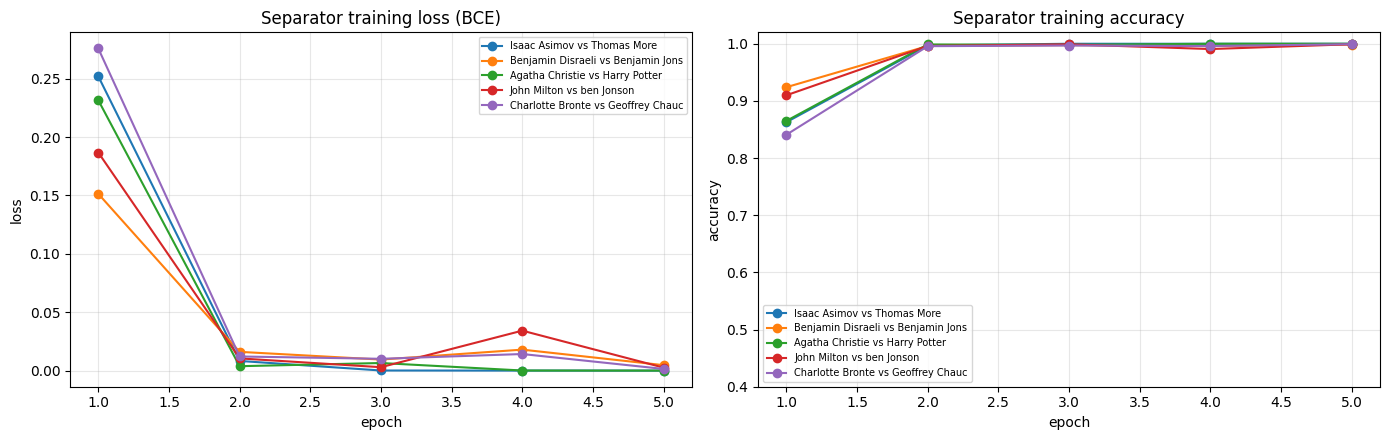

In [ ]:
# Panel 1 — Training curves (model learning)
if training_history:
    fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
    cmap = plt.cm.tab10
    for k, hist_entry in enumerate(training_history):
        auth_i, auth_j = hist_entry["pair"]
        ep = [h["epoch"] for h in hist_entry["epochs"]]
        loss = [h["loss"] for h in hist_entry["epochs"]]
        acc  = [h["accuracy"] for h in hist_entry["epochs"]]
        label = f"{auth_i} vs {auth_j}"[:34]
        axes[0].plot(ep, loss, "-o", color=cmap(k), label=label)
        axes[1].plot(ep, acc,  "-o", color=cmap(k), label=label)
    axes[0].set_title("Separator training loss (BCE)")
    axes[0].set_xlabel("epoch"); axes[0].set_ylabel("loss"); axes[0].grid(alpha=0.3)
    axes[1].set_title("Separator training accuracy")
    axes[1].set_xlabel("epoch"); axes[1].set_ylabel("accuracy"); axes[1].grid(alpha=0.3)
    axes[1].set_ylim(0.4, 1.02)
    axes[0].legend(fontsize=7); axes[1].legend(fontsize=7)
    plt.tight_layout()
    plt.savefig(os.path.join(BASE_PATH, "training_curves.png"), dpi=150,
                bbox_inches="tight")
    plt.show()
else:
    print("No training history captured.")


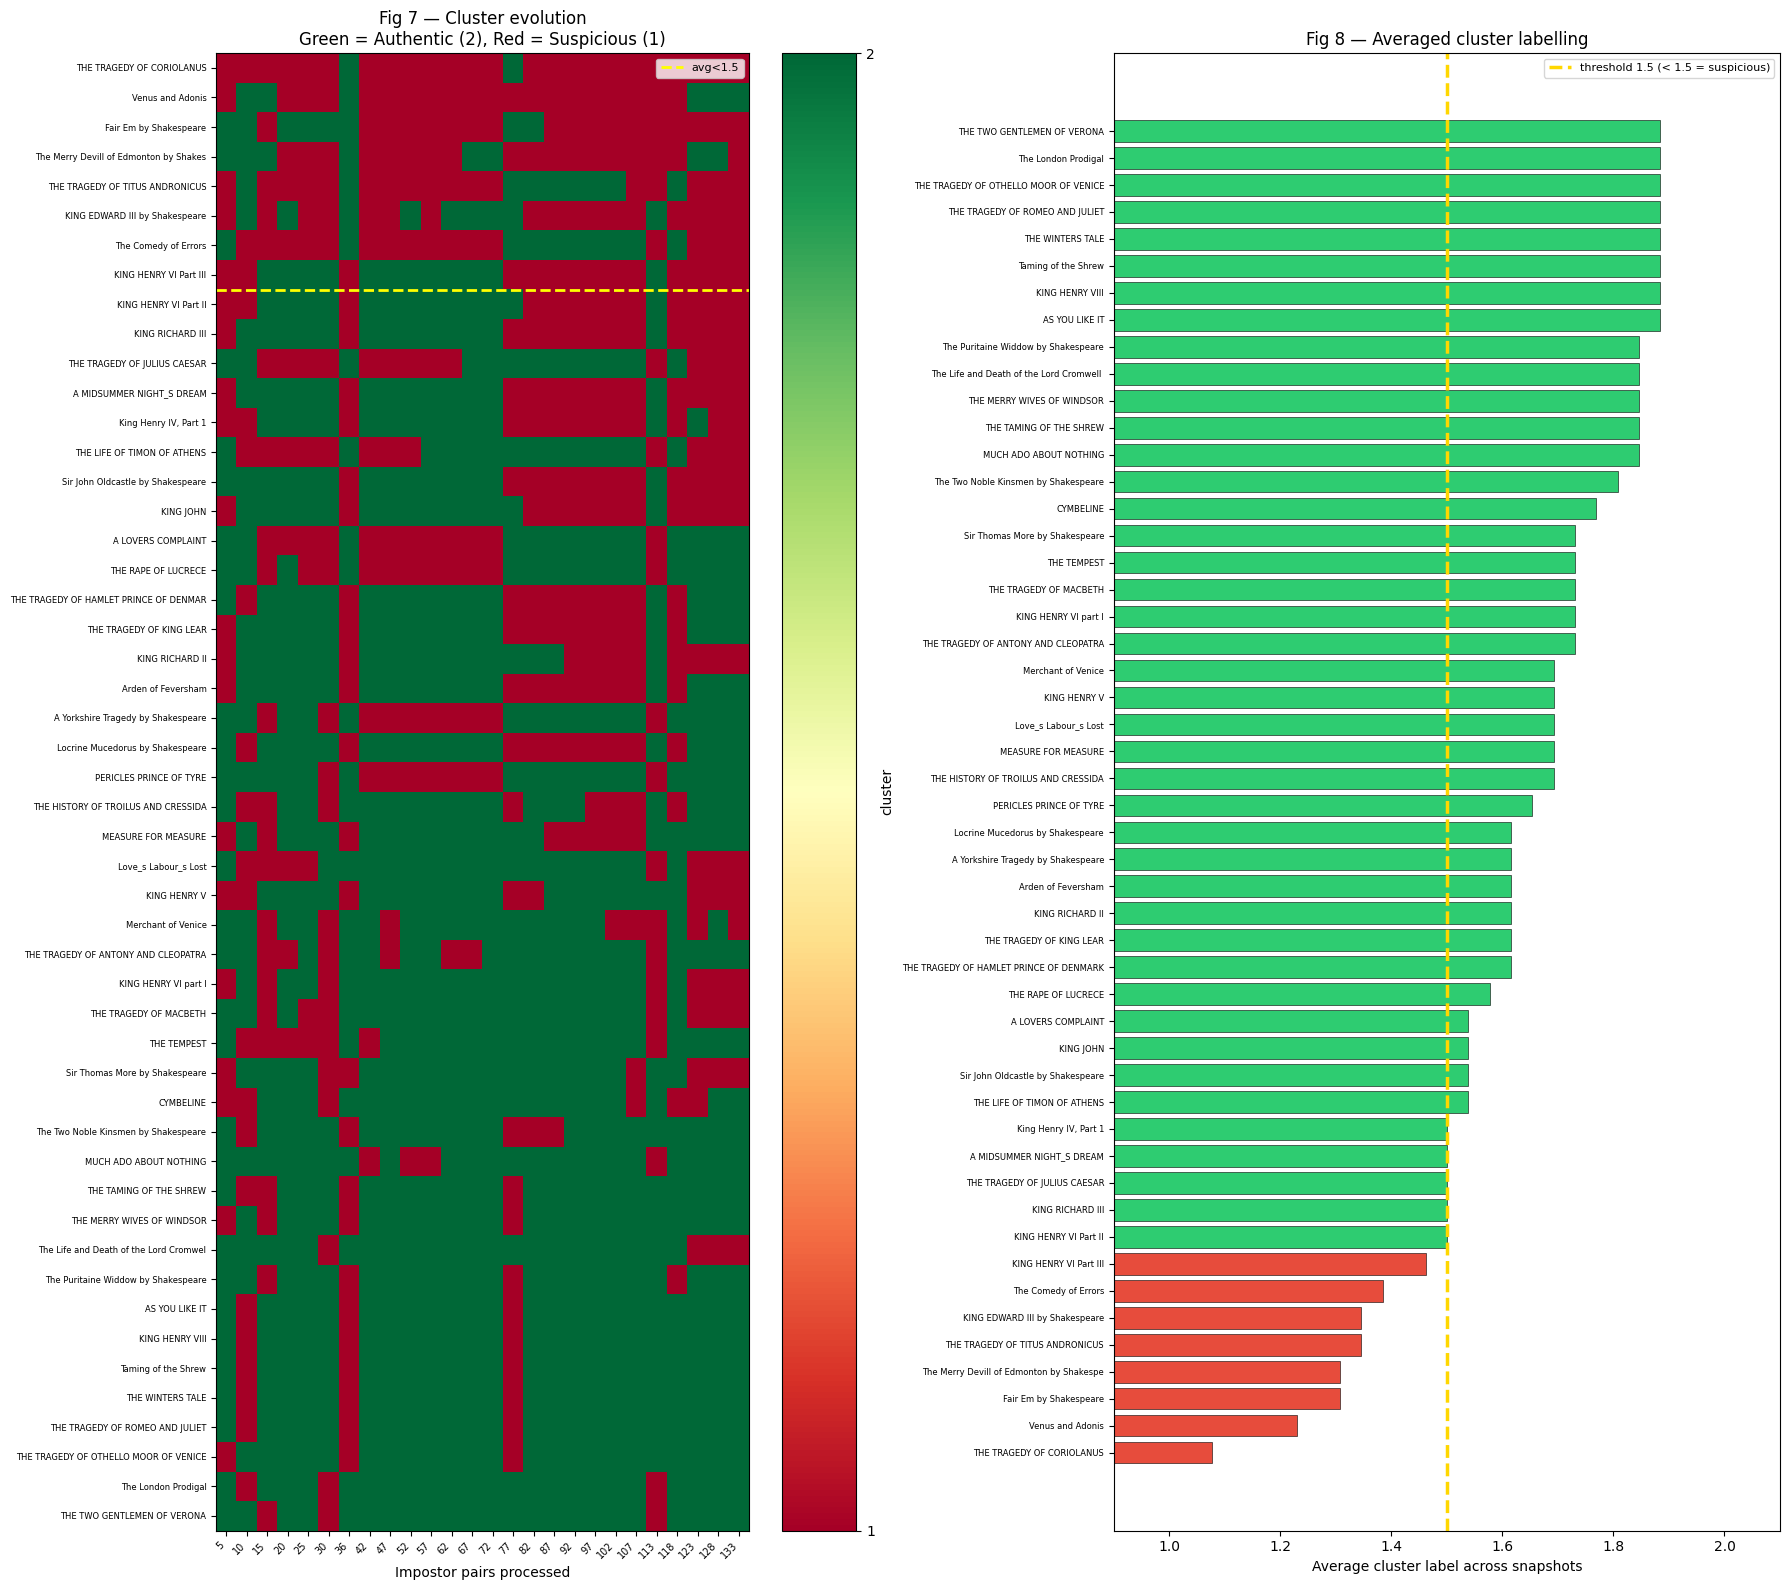

In [ ]:
# Panels 2 + 3 — Cluster evolution (paper Fig 7 + Fig 8)
if not evolution_history:
    print("No evolution history; lower CLUSTER_EVERY_N or raise N_IMPOSTOR_PAIRS.")
else:
    n_tx, n_sn = len(text_names), len(evolution_history)
    iters     = [it for it, _ in evolution_history]
    ev_mat    = np.zeros((n_tx, n_sn))
    for s, (_, lbl) in enumerate(evolution_history):
        ev_mat[:, s] = lbl
    order = np.argsort(avg_cluster_labels)

    fig, axes = plt.subplots(1, 2, figsize=(18, max(7, n_tx * 0.32)))

    # Fig 7
    ax = axes[0]
    im = ax.imshow(ev_mat[order], aspect="auto", cmap="RdYlGn",
                   vmin=1, vmax=2, interpolation="nearest")
    ax.set_xticks(range(n_sn))
    ax.set_xticklabels(iters, rotation=45, ha="right", fontsize=7)
    ax.set_yticks(range(n_tx))
    ax.set_yticklabels([text_names[i][:38] for i in order], fontsize=6)
    ax.set_xlabel("Impostor pairs processed")
    ax.set_title("Fig 7 — Cluster evolution\nGreen = Authentic (2), Red = Suspicious (1)")
    plt.colorbar(im, ax=ax, ticks=[1, 2], label="cluster")
    thresh_pos = int(np.searchsorted(avg_cluster_labels[order], 1.5))
    ax.axhline(thresh_pos - 0.5, color="yellow", lw=2, ls="--", label="avg<1.5")
    ax.legend(loc="upper right", fontsize=8)

    # Fig 8
    ax = axes[1]
    sorted_avg = avg_cluster_labels[order]
    names_o    = [text_names[i] for i in order]
    colors_o   = ["#e74c3c" if v < 1.5 else "#2ecc71" for v in sorted_avg]
    ax.barh(range(n_tx), sorted_avg, color=colors_o, edgecolor="black", lw=0.4)
    ax.axvline(1.5, color="gold", lw=2.5, ls="--",
                label="threshold 1.5 (< 1.5 = suspicious)")
    ax.set_yticks(range(n_tx))
    ax.set_yticklabels([n[:40] for n in names_o], fontsize=6)
    ax.set_xlim(0.9, 2.1)
    ax.set_xlabel("Average cluster label across snapshots")
    ax.set_title("Fig 8 — Averaged cluster labelling")
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.savefig(os.path.join(BASE_PATH, "cluster_evolution.png"), dpi=150,
                bbox_inches="tight")
    plt.show()


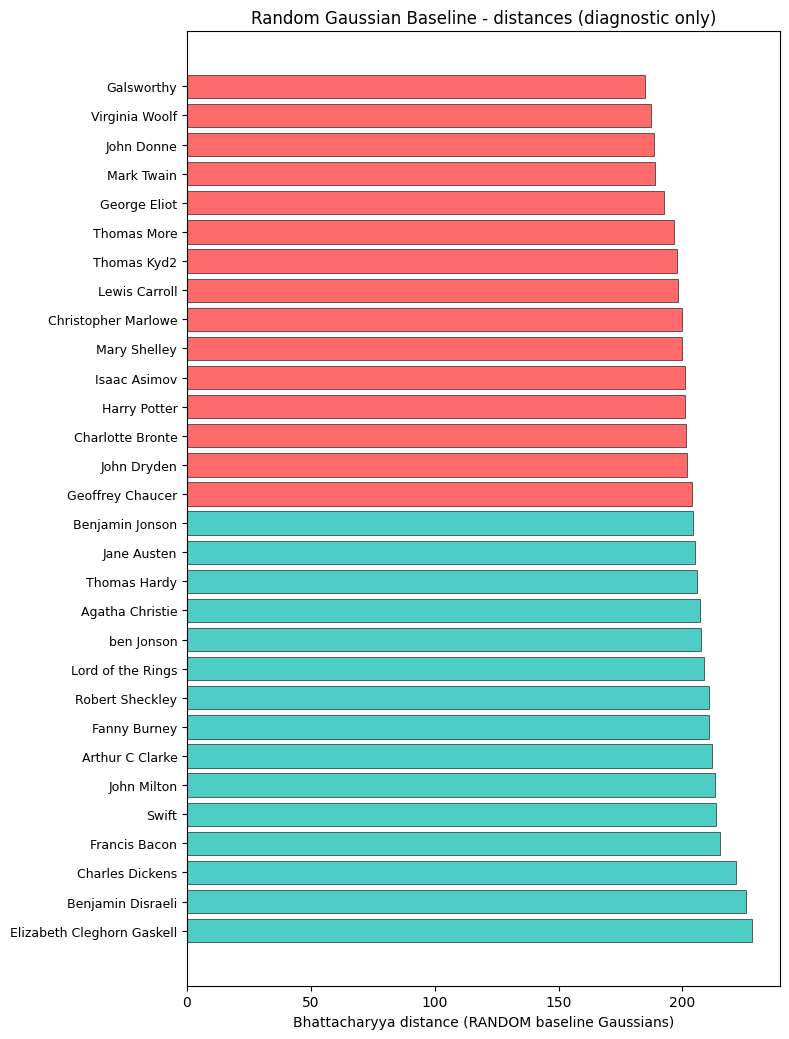

In [ ]:
# Panel 4 - RANDOM BASELINE distance heatmap (diagnostic, NOT fitted authors).
# Uses the Step 3-4 random_baseline_* Gaussians. Shows the geometry of the
# random control, not real author similarity.
authors_list = list(random_baseline_impostor_gaussians.keys())
base_mu  = random_baseline_shakespeare_gaussian["mu"]
base_sig = random_baseline_shakespeare_gaussian["sigma_noisy"]
distances = [bhattacharyya_distance(base_mu, base_sig,
             random_baseline_impostor_gaussians[a]["mu"],
             random_baseline_impostor_gaussians[a]["sigma"]) for a in authors_list]
order = np.argsort(distances)

fig, ax = plt.subplots(figsize=(8, max(8, len(authors_list) * 0.35)))
median_d = float(np.median(distances))
colors_o = ["#ff6b6b" if distances[i] < median_d else "#4ecdc4" for i in order]
ax.barh(range(len(order)), [distances[i] for i in order],
        color=colors_o, edgecolor="black", lw=0.4)
ax.set_yticks(range(len(order)))
ax.set_yticklabels([authors_list[i] for i in order], fontsize=9)
ax.set_xlabel("Bhattacharyya distance (RANDOM baseline Gaussians)")
ax.set_title("Random Gaussian Baseline - distances (diagnostic only)")
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(os.path.join(BASE_PATH, "random_baseline_distances.png"), dpi=150,
            bbox_inches="tight")
plt.show()

>>> Data-driven verifier on Shakespeare (feature_mode=mean_logvar)


  0%|          | 0/50 [00:00<?, ?it/s]


>>> Data-driven verifier on impostors (leave-one-out)


  0%|          | 0/30 [00:00<?, ?it/s]

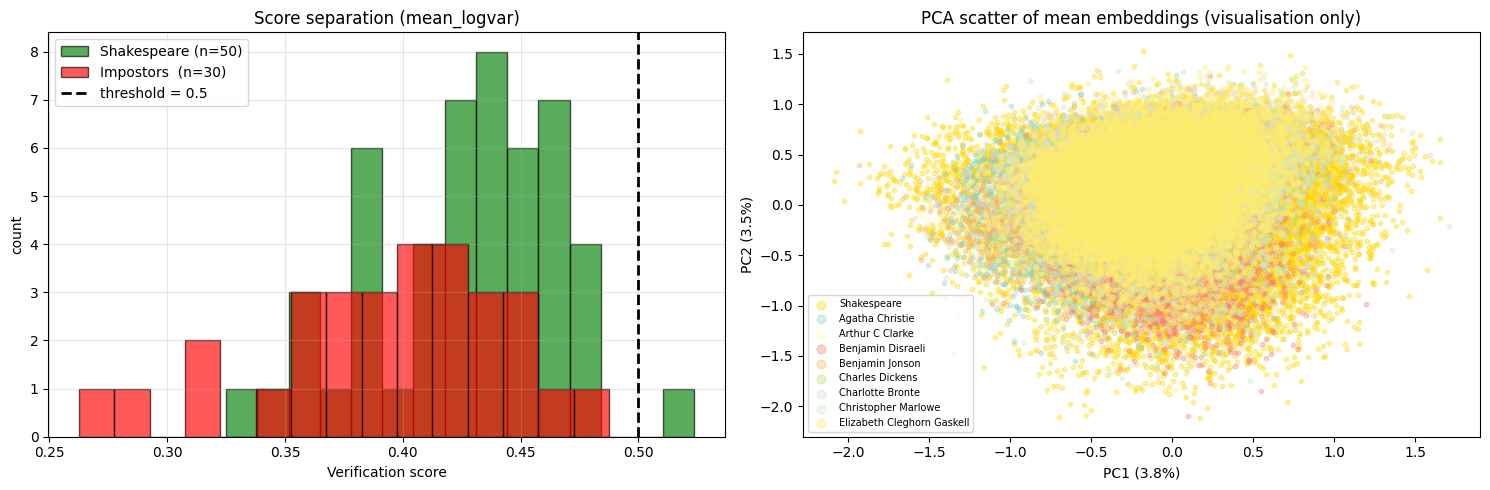


Shakespeare accuracy : 2.0%
Impostor   rejection : 100.0%


In [ ]:
# Step 7 - DATA-DRIVEN probabilistic verifier (random subspace, FITTED Gaussians).
# This is NOT the random baseline: it fits Gaussians to the ACTUAL segment
# features and never calls random_diagonal_gaussian. Features come from
# build_probabilistic_features(mean, var, feature_mode):
#   mean_only   -> mu                        (baseline, variance unused)
#   mean_logvar -> concat(mu, log(var+eps))  (uses encoder uncertainty)
#
# IMPORTANT (what the fitted Gaussians mean here): when feature_mode=
# "mean_logvar" we TRANSFORM each probabilistic segment embedding N(mu,diag(var))
# into an explicit probabilistic FEATURE VECTOR [mu ; log(var)] and fit
# author-level diagonal Gaussians OVER THESE FEATURE VECTORS. This is a Gaussian
# fitted in the [mu ; log-var] feature space - it is NOT a direct, closed-form
# Gaussian-to-Gaussian Sen2Pro comparison of the original embedding
# distributions. The variance information enters as extra feature dimensions.

def verify_authorship_parts(test_mean, test_var, shake_emb_all, imp_emb_all, *,
                            feature_mode=None,
                            n_rounds=30, seed=42,
                            lambda_shake=LAMBDA_SHAKESPEARE,
                            lambda_imp=LAMBDA_IMPOSTOR,
                            n_parts=N_PARTS, n_random_dims=N_RANDOM_DIMS,
                            distance_metric=DISTANCE_METRIC):
    """Per-part random-subspace verification on DATA-DRIVEN probabilistic features.

    Each round: pick a random subspace of the feature space, fit a diagonal
    Gaussian per author (Shakespeare + impostors) from the ACTUAL features,
    split the test doc into parts, and score each part by how many impostors are
    farther than Shakespeare. Returns dict with `score` in [0,1]; >0.5 => Shakespeare.

    Variance enters via feature_mode="mean_logvar". The Gaussians are FITTED to
    real features here - never randomized.
    """
    feature_mode = FEATURE_MODE if feature_mode is None else feature_mode
    dist_fn   = _pick_dist(distance_metric)
    test_feat = build_probabilistic_features(test_mean, test_var, feature_mode)
    shake_feat = stack_segment_features(shake_emb_all.values(), feature_mode)
    imp_feat_global = {a: stack_segment_features(texts.values(), feature_mode)
                       for a, texts in imp_emb_all.items()}
    F = test_feat.shape[1]

    rng = np.random.RandomState(seed)
    scores = []
    for _ in range(n_rounds):
        rs = int(rng.randint(0, 2**31))
        rng_loc = np.random.RandomState(rs)
        # Select N_RANDOM_DIMS ORIGINAL dims; for mean_logvar take the matching
        # mu AND logvar columns so the two blocks stay aligned (-> 2*n_random_dims).
        sel = select_probabilistic_subspace(F, feature_mode, n_random_dims, rng_loc)
        test_proj  = test_feat[:, sel]
        mu_s, sig_s = fit_diagonal_gaussian(shake_feat[:, sel])
        sig_s = add_covariance_noise(sig_s, lambda_shake)

        imp_dists = {}
        for a, feat in imp_feat_global.items():
            mu_i, sig_i = fit_diagonal_gaussian(feat[:, sel])
            imp_dists[a] = (mu_i, add_covariance_noise(sig_i, lambda_imp))

        for part in split_into_parts(test_proj, n_parts, shuffle=True, seed=rs + 1):
            mu_t, sig_t = fit_diagonal_gaussian(part)
            sig_t = add_covariance_noise(sig_t, lambda_imp)
            d_shake = dist_fn(mu_t, sig_t, mu_s, sig_s)
            if np.isinf(d_shake):
                continue
            n_far = 0
            for mu_i, sig_i in imp_dists.values():
                d_i = dist_fn(mu_t, sig_t, mu_i, sig_i)
                if not np.isinf(d_i) and d_i > d_shake:
                    n_far += 1
            scores.append(n_far / max(len(imp_dists), 1))
    s = float(np.mean(scores)) if scores else 0.0
    return {"score": s, "is_shakespeare": s > 0.5,
            "n_rounds": n_rounds, "n_parts": n_parts,
            "feature_mode": feature_mode, "feature_dim": int(F)}


print(f">>> Data-driven verifier on Shakespeare (feature_mode={FEATURE_MODE})")
shake_results = {}
for name in tqdm(shakespeare_embeddings):
    e = shakespeare_embeddings[name]
    shake_results[name] = verify_authorship_parts(
        e["mean"], e["var"], shakespeare_embeddings, impostor_embeddings, n_rounds=20)

print("\n>>> Data-driven verifier on impostors (leave-one-out)")
imp_results = {}
for author, texts in tqdm(impostor_embeddings.items()):
    t_mean = np.vstack([d["mean"] for d in texts.values()])
    t_var  = np.vstack([d["var"]  for d in texts.values()])
    reduced = {a: v for a, v in impostor_embeddings.items() if a != author}
    imp_results[author] = verify_authorship_parts(
        t_mean, t_var, shakespeare_embeddings, reduced, n_rounds=20)

shake_scores = np.array([r["score"] for r in shake_results.values()])
imp_scores   = np.array([r["score"] for r in imp_results.values()])

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
ax = axes[0]
ax.hist(shake_scores, bins=15, alpha=0.65, color="green",
        edgecolor="black", label=f"Shakespeare (n={len(shake_scores)})")
ax.hist(imp_scores,   bins=15, alpha=0.65, color="red",
        edgecolor="black", label=f"Impostors  (n={len(imp_scores)})")
ax.axvline(0.5, color="black", ls="--", lw=2, label="threshold = 0.5")
ax.set_xlabel("Verification score"); ax.set_ylabel("count")
ax.set_title(f"Score separation ({FEATURE_MODE})"); ax.legend(); ax.grid(alpha=0.3)

ax = axes[1]
all_shakespeare_emb = np.vstack([d["mean"] for d in shakespeare_embeddings.values()])
pca_2d = PCA(n_components=2).fit(all_shakespeare_emb)
sh2d = pca_2d.transform(all_shakespeare_emb)
ax.scatter(sh2d[:, 0], sh2d[:, 1], s=10, alpha=0.35, c="gold", label="Shakespeare")
cmap = plt.cm.Set3(np.linspace(0, 1, max(1, min(8, len(impostor_embeddings)))))
for k, (auth, texts) in enumerate(list(impostor_embeddings.items())[:8]):
    p2 = pca_2d.transform(np.vstack([d["mean"] for d in texts.values()]))
    ax.scatter(p2[:, 0], p2[:, 1], s=10, alpha=0.35, c=[cmap[k]], label=auth)
ax.set_xlabel(f"PC1 ({pca_2d.explained_variance_ratio_[0]:.1%})")
ax.set_ylabel(f"PC2 ({pca_2d.explained_variance_ratio_[1]:.1%})")
ax.set_title("PCA scatter of mean embeddings (visualisation only)")
ax.legend(fontsize=7, markerscale=2)
plt.tight_layout()
plt.savefig(os.path.join(BASE_PATH, "score_separation.png"), dpi=150, bbox_inches="tight")
plt.show()

print(f"\nShakespeare accuracy : {(shake_scores > 0.5).mean()*100:.1f}%")
print(f"Impostor   rejection : {(imp_scores < 0.5).mean()*100:.1f}%")

## Step 7c - Calibrated probabilistic verification (NEW, leakage-safe)

Targeted additions: LOGVAR_WEIGHT sweep, threshold calibration, normalization &
distance comparisons, perturbation sweep, a final honest results table, automatic
best-model selection, and diagnostic plots. All reuse the stored `mu`/`var`
embeddings and a leave-one-document-out protocol.

In [ ]:

# ============================================================================
# Step 7c - Calibrated probabilistic verification toolkit  (ADDITIVE, leakage-safe)
# ----------------------------------------------------------------------------
# Everything here is NEW and self-contained. It REUSES the already-computed
# `shakespeare_embeddings` / `impostor_embeddings` (per-segment mu & var) and
# does NOT re-embed, so the LOGVAR_WEIGHT / normalization / distance sweeps are
# cheap post-hoc transforms on stored Gaussians.
#
# Honest naming: a segment is represented by [mu ; w * log(var)] probabilistic
# FEATURES from encoder-level MC Dropout (+ optional perturbations). This is a
# Sen2Pro-INSPIRED approximation, not a closed-form Gaussian-to-Gaussian Sen2Pro
# comparison.
#
# Distances use DIAGONAL covariance as VECTORS (fast; mathematically identical
# to the diag-matrix versions in Step 5a) with the same regularisation
# (COV_EPS, LAMBDA_*).  verify_parts stays DATA-DRIVEN (fitted Gaussians).
# ============================================================================

def fit_feature_stats(mean_stack, var_stack, eps=FEATURE_EPS, clip_range=LOGVAR_CLIP_RANGE):
    """Per-block scaling stats fitted on REFERENCE segments (UNSUPERVISED - no
    labels), used by build_features_param when normalize_method != 'clip_only'."""
    mu = np.asarray(mean_stack, float)
    lv = np.clip(np.log(np.asarray(var_stack, float) + eps), *clip_range)
    def st(x):
        q1, q3 = np.percentile(x, 25, 0), np.percentile(x, 75, 0)
        return {"mean": x.mean(0), "std": x.std(0) + 1e-8,
                "median": np.median(x, 0), "iqr": (q3 - q1) + 1e-8}
    return {"mu": st(mu), "lv": st(lv)}


def build_features_param(mean, var, mode="mean_logvar", logvar_weight=1.0,
                         normalize_method="clip_only", eps=FEATURE_EPS,
                         clip_range=LOGVAR_CLIP_RANGE, stats=None):
    """mean_only   -> mu                                  (d dims)
       mean_logvar -> concat(mu_block, w * logvar_block)  (2d dims; block layout
                      preserved so select_subspace stays mu/logvar aligned).
    Pipeline: clip log-var -> (optional) block-normalise using REFERENCE `stats`
    -> multiply the log-var block by `logvar_weight`.  w is applied AFTER
    normalisation, so it is the interpretable relative-scale knob:
        w = 0  => log-var block is all-zeros  => behaves like mean_only
        w up   => uncertainty contributes more."""
    mean = np.asarray(mean, float)
    if mode == "mean_only":
        b = mean
        if normalize_method == "block_standardize" and stats is not None:
            b = (b - stats["mu"]["mean"]) / stats["mu"]["std"]
        elif normalize_method == "robust_block_scale" and stats is not None:
            b = (b - stats["mu"]["median"]) / stats["mu"]["iqr"]
        return b
    var = np.asarray(var, float)
    if var.shape != mean.shape:
        var = np.zeros_like(mean)
    lv = np.clip(np.log(var + eps), *clip_range)
    mu_b, lv_b = mean, lv
    if normalize_method == "block_standardize":
        s = stats or {"mu": {"mean": mean.mean(0), "std": mean.std(0) + 1e-8},
                      "lv": {"mean": lv.mean(0),  "std": lv.std(0) + 1e-8}}
        mu_b = (mu_b - s["mu"]["mean"]) / s["mu"]["std"]
        lv_b = (lv_b - s["lv"]["mean"]) / s["lv"]["std"]
    elif normalize_method == "robust_block_scale":
        if stats is not None:
            s = stats
        else:
            def md(x):
                q1, q3 = np.percentile(x, 25, 0), np.percentile(x, 75, 0)
                return {"median": np.median(x, 0), "iqr": (q3 - q1) + 1e-8}
            s = {"mu": md(mean), "lv": md(lv)}
        mu_b = (mu_b - s["mu"]["median"]) / s["mu"]["iqr"]
        lv_b = (lv_b - s["lv"]["median"]) / s["lv"]["iqr"]
    return np.concatenate([mu_b, logvar_weight * lv_b], axis=1)


# --- diagonal-vector Gaussian fit + fast distances (diag covariance only) ---
def fit_diag(emb):
    arr = np.asarray(emb, float)
    mu  = arr.mean(0)
    v   = arr.var(0, ddof=1) if arr.shape[0] > 1 else np.zeros(arr.shape[1])
    return mu, v + COV_EPS                       # variance as a VECTOR

def bhat_diag(mu1, v1, mu2, v2):
    avg = 0.5 * (v1 + v2)
    return (0.125 * np.sum((mu1 - mu2) ** 2 / avg)
            + 0.5 * (np.sum(np.log(avg)) - 0.5 * (np.sum(np.log(v1)) + np.sum(np.log(v2)))))

def w2_diag(mu1, v1, mu2, v2):
    sd = np.sqrt(v1) - np.sqrt(v2)
    return np.sqrt(max(0.0, np.sum((mu1 - mu2) ** 2) + np.sum(sd ** 2)))

def kl_sym_diag(mu1, v1, mu2, v2):
    kl = lambda m1, s1, m2, s2: 0.5 * np.sum(s1 / s2 + (m2 - m1) ** 2 / s2 - 1 + np.log(s2 / s1))
    return 0.5 * (kl(mu1, v1, mu2, v2) + kl(mu2, v2, mu1, v1))

def eucl_diag(mu1, v1, mu2, v2):
    return float(np.linalg.norm(mu1 - mu2))      # mu only (covariance ignored)

def cos_diag(mu1, v1, mu2, v2):
    return float(1 - (mu1 @ mu2) / (np.linalg.norm(mu1) * np.linalg.norm(mu2) + 1e-12))

DIST = {"bhattacharyya": bhat_diag, "w2": w2_diag, "kl": kl_sym_diag,
        "euclidean": eucl_diag, "cosine": cos_diag}


def select_subspace(F, mode, n_dims, rng):
    d = F if mode == "mean_only" else F // 2
    k = min(n_dims, d)
    base = np.sort(rng.choice(d, k, replace=False))
    return base if mode == "mean_only" else np.concatenate([base, base + d])

def split_parts_v(emb, n_parts, seed):
    n = len(emb); emb = emb[np.random.RandomState(seed).permutation(n)]
    part = max(2, n // n_parts); out = []
    for k in range(n_parts):
        a, b = k * part, ((k + 1) * part if k < n_parts - 1 else n)
        if b - a >= 2:
            out.append(emb[a:b])
    return out or [emb]


def _precompute_rounds(shake_full_feat, imp_feats, mode, n_dims, n_rounds, seed):
    """Per round: pick subspace, fit Shakespeare(full) + every impostor Gaussian
    ONCE (reused across all Shakespeare test docs -> big speedup)."""
    rng = np.random.RandomState(seed); F = shake_full_feat.shape[1]; rounds = []
    for _ in range(n_rounds):
        rs  = int(rng.randint(0, 2 ** 31))
        sel = select_subspace(F, mode, n_dims, np.random.RandomState(rs))
        mu_s, v_s = fit_diag(shake_full_feat[:, sel]); v_s = v_s + LAMBDA_SHAKESPEARE
        imp = {}
        for a, f in imp_feats.items():
            mu_i, v_i = fit_diag(f[:, sel]); imp[a] = (mu_i, v_i + LAMBDA_IMPOSTOR)
        rounds.append((rs, sel, (mu_s, v_s), imp))
    return rounds

def _score_with_rounds(test_feat, rounds, dist, n_parts, shake_loo=None, drop_imp=None):
    scores = []
    for ridx, (rs, sel, shake_g, imp) in enumerate(rounds):
        mu_s, v_s = shake_loo[ridx] if shake_loo is not None else shake_g
        imp_items = [mv for a, mv in imp.items() if a != drop_imp]
        for part in split_parts_v(test_feat[:, sel], n_parts, rs + 1):
            mu_t, v_t = fit_diag(part); v_t = v_t + LAMBDA_IMPOSTOR
            ds = dist(mu_t, v_t, mu_s, v_s)
            if not np.isfinite(ds):
                continue
            nf = 0
            for mu_i, v_i in imp_items:
                di = dist(mu_t, v_t, mu_i, v_i)
                if np.isfinite(di) and di > ds:
                    nf += 1
            scores.append(nf / max(len(imp_items), 1))
    return float(np.mean(scores)) if scores else 0.0


_eval_cache = {}

def evaluate_embeddings(shake_emb, imp_emb, mode="mean_logvar", logvar_weight=0.05,
                        normalize_method="block_standardize",
                        distance_metric="bhattacharyya", n_rounds=12,
                        n_dims=None, n_parts=None, seed=RANDOM_SEED):
    """LEAKAGE-SAFE evaluation. Protocol = leave-one-document-out:
       * Shakespeare doc i is scored against Shakespeare-WITHOUT-i + all impostors.
       * impostor author a is scored against all Shakespeare + impostors-WITHOUT-a.
       Block-normalisation stats are fitted UNSUPERVISED on all reference segments
       (no labels), which is standard feature scaling and not label leakage.
    Returns (shake_scores, imp_scores, shake_names, imp_names)."""
    n_dims  = N_RANDOM_DIMS if n_dims  is None else n_dims
    n_parts = N_PARTS       if n_parts is None else n_parts
    stats = None
    if normalize_method != "clip_only":
        M = np.vstack([e["mean"] for e in shake_emb.values()]
                      + [e["mean"] for t in imp_emb.values() for e in t.values()])
        V = np.vstack([e["var"] for e in shake_emb.values()]
                      + [e["var"] for t in imp_emb.values() for e in t.values()])
        stats = fit_feature_stats(M, V)
    fb = lambda e: build_features_param(e["mean"], e["var"], mode, logvar_weight,
                                        normalize_method, stats=stats)
    shake_names = list(shake_emb.keys())
    imp_names   = list(imp_emb.keys())
    shake_feat  = {n: fb(shake_emb[n]) for n in shake_names}
    imp_feat    = {a: np.vstack([fb(e) for e in t.values()]) for a, t in imp_emb.items()}
    dist        = DIST[distance_metric]
    shake_full  = np.vstack([shake_feat[n] for n in shake_names])
    rounds      = _precompute_rounds(shake_full, imp_feat, mode, n_dims, n_rounds, seed)

    shake_scores = []
    for name in shake_names:                                   # Shakespeare LOO
        loo = np.vstack([shake_feat[m] for m in shake_names if m != name])
        loo_g = []
        for (rs, sel, _, _) in rounds:
            mu_s, v_s = fit_diag(loo[:, sel]); loo_g.append((mu_s, v_s + LAMBDA_SHAKESPEARE))
        shake_scores.append(_score_with_rounds(shake_feat[name], rounds, dist, n_parts, shake_loo=loo_g))

    imp_scores = []
    for a in imp_names:                                        # impostor LOO
        imp_scores.append(_score_with_rounds(imp_feat[a], rounds, dist, n_parts, drop_imp=a))

    return np.array(shake_scores), np.array(imp_scores), shake_names, imp_names


def evaluate_config(mode="mean_logvar", logvar_weight=0.05,
                    normalize_method="block_standardize",
                    distance_metric="bhattacharyya", n_rounds=12,
                    n_dims=None, n_parts=None, seed=RANDOM_SEED):
    """Cached wrapper over the FULL global embeddings."""
    key = (mode, round(float(logvar_weight), 4), normalize_method, distance_metric,
           n_rounds, n_dims, n_parts, seed)
    if key in _eval_cache:
        return _eval_cache[key]
    res = evaluate_embeddings(shakespeare_embeddings, impostor_embeddings,
                              mode, logvar_weight, normalize_method, distance_metric,
                              n_rounds, n_dims, n_parts, seed)
    _eval_cache[key] = res
    return res


# --- metrics / AUC / threshold calibration ---------------------------------
def confusion_metrics(shake, imp, thr):
    shake, imp = np.asarray(shake), np.asarray(imp)
    tp, fn = int((shake > thr).sum()), int((shake <= thr).sum())
    tn, fp = int((imp <= thr).sum()), int((imp > thr).sum())
    tot = tp + fn + tn + fp
    tpr = tp / (tp + fn) if (tp + fn) else 0.0
    tnr = tn / (tn + fp) if (tn + fp) else 0.0
    return {"acc": (tp + tn) / tot if tot else 0.0, "bal_acc": 0.5 * (tpr + tnr),
            "tpr": tpr, "tnr": tnr, "fpr": 1 - tnr, "fnr": 1 - tpr, "thr": thr}

def auc_score(shake, imp):
    """ROC-AUC = P(score(Shakespeare) > score(impostor)); threshold-free."""
    shake, imp = np.asarray(shake, float), np.asarray(imp, float)
    if len(shake) == 0 or len(imp) == 0:
        return float("nan")
    gt = (shake[:, None] > imp[None, :]).sum()
    eq = (shake[:, None] == imp[None, :]).sum()
    return float((gt + 0.5 * eq) / (len(shake) * len(imp)))

def calibrate_threshold(shake, imp, thresholds=None, objective="bal_acc"):
    thresholds = THRESHOLD_GRID if thresholds is None else thresholds
    curve = [confusion_metrics(shake, imp, t) for t in thresholds]
    key = (lambda m: m["tpr"] + m["tnr"] - 1) if objective == "youden" else (lambda m: m["bal_acc"])
    return max(curve, key=key), curve

def loo_calibrated_metrics(shake, imp, thresholds=None, objective="bal_acc"):
    """HONEST generalisation estimate for small data: for every labelled doc,
    pick the threshold on the REST, then predict the held-out doc."""
    thresholds = THRESHOLD_GRID if thresholds is None else thresholds
    shake, imp = np.asarray(shake), np.asarray(imp)
    tp = fn = tn = fp = 0
    for i in range(len(shake)):
        best, _ = calibrate_threshold(np.delete(shake, i), imp, thresholds, objective)
        tp, fn = (tp + 1, fn) if shake[i] > best["thr"] else (tp, fn + 1)
    for j in range(len(imp)):
        best, _ = calibrate_threshold(shake, np.delete(imp, j), thresholds, objective)
        fp, tn = (fp + 1, tn) if imp[j] > best["thr"] else (fp, tn + 1)
    tot = tp + fn + tn + fp
    tpr = tp / (tp + fn) if (tp + fn) else 0.0
    tnr = tn / (tn + fp) if (tn + fp) else 0.0
    return {"acc": (tp + tn) / tot, "bal_acc": 0.5 * (tpr + tnr), "tpr": tpr,
            "tnr": tnr, "fpr": 1 - tnr, "fnr": 1 - tpr, "thr": "LOO-nested"}

print("Toolkit ready: evaluate_config / calibrate_threshold / loo_calibrated_metrics / auc_score")
print(f"Evaluation protocol = leave-one-document-out (LOO). THRESHOLD_GRID size = {len(THRESHOLD_GRID)}")


Toolkit ready: evaluate_config / calibrate_threshold / loo_calibrated_metrics / auc_score
Evaluation protocol = leave-one-document-out (LOO). THRESHOLD_GRID size = 91


logvar-weight sweep:   0%|          | 0/8 [00:00<?, ?it/s]

    w    AUC  fix_acc  fix_bal  cal_bal  cal_thr  loo_bal  loo_TPR  loo_TNR
--------------------------------------------------------------------------
  0.0  0.989    0.875    0.833    0.940     0.91    0.903    0.940    0.867
 0.01  0.500    0.375    0.500    0.500     0.05    0.500    0.000    1.000
 0.03  0.530    0.375    0.500    0.500     0.05    0.500    0.000    1.000
 0.05  0.823    0.375    0.500    0.790     0.05    0.790    0.880    0.700
  0.1  0.941    0.900    0.867    0.910     0.79    0.877    0.920    0.833
  0.2  0.983    0.850    0.800    0.910     0.95    0.860    0.920    0.800
  0.5  0.967    0.850    0.800    0.930     0.93    0.897    0.960    0.833
  1.0  0.968    0.850    0.800    0.930     0.93    0.897    0.960    0.833

Best LOGVAR_WEIGHT by LOO balanced accuracy = 0.0 (loo_bal=0.903, AUC=0.989)


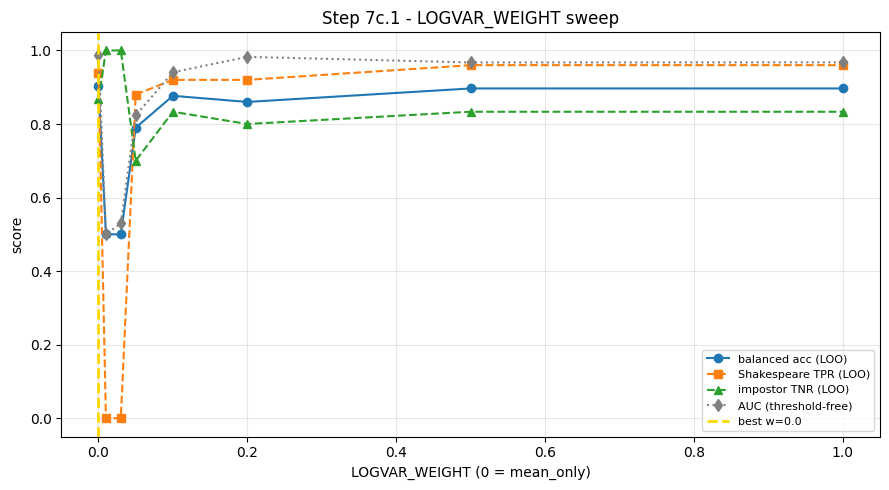

In [ ]:

# Step 7c.1 - LOGVAR_WEIGHT sweep (does weighting the uncertainty block help?)
# w = 0.0 == mean_only ; small w == gentle uncertainty ; large w == variance dominates.
sweep_rows = []
for w in tqdm(LOGVAR_WEIGHT_VALUES, desc="logvar-weight sweep"):
    mode = "mean_only" if w == 0.0 else "mean_logvar"
    sh, ip, _, _ = evaluate_config(mode=mode, logvar_weight=w,
                                   normalize_method=NORMALIZE_METHOD,
                                   distance_metric=DISTANCE_METRIC,
                                   n_rounds=SWEEP_ROUNDS)
    fixed = confusion_metrics(sh, ip, FIXED_THRESHOLD)
    cal, _ = calibrate_threshold(sh, ip, objective=CALIB_OBJECTIVE)
    loo   = loo_calibrated_metrics(sh, ip, objective=CALIB_OBJECTIVE)
    sweep_rows.append({"w": w, "mode": mode, "sh": sh, "ip": ip,
                       "auc": auc_score(sh, ip), "fixed": fixed, "cal": cal, "loo": loo})

print(f"{'w':>5} {'AUC':>6} {'fix_acc':>8} {'fix_bal':>8} {'cal_bal':>8} "
      f"{'cal_thr':>8} {'loo_bal':>8} {'loo_TPR':>8} {'loo_TNR':>8}")
print("-" * 74)
for r in sweep_rows:
    print(f"{r['w']:>5} {r['auc']:>6.3f} {r['fixed']['acc']:>8.3f} {r['fixed']['bal_acc']:>8.3f} "
          f"{r['cal']['bal_acc']:>8.3f} {r['cal']['thr']:>8.2f} {r['loo']['bal_acc']:>8.3f} "
          f"{r['loo']['tpr']:>8.3f} {r['loo']['tnr']:>8.3f}")

# pick best weight by HONEST loo balanced accuracy (tie-break: higher AUC)
best_row  = max(sweep_rows, key=lambda r: (r["loo"]["bal_acc"], r["auc"]))
BEST_LOGVAR_WEIGHT = best_row["w"]
print(f"\nBest LOGVAR_WEIGHT by LOO balanced accuracy = {BEST_LOGVAR_WEIGHT} "
      f"(loo_bal={best_row['loo']['bal_acc']:.3f}, AUC={best_row['auc']:.3f})")

# Plot A - weight vs balanced accuracy / TPR / TNR
ws = [r["w"] for r in sweep_rows]
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(ws, [r["loo"]["bal_acc"] for r in sweep_rows], "o-", label="balanced acc (LOO)")
ax.plot(ws, [r["loo"]["tpr"] for r in sweep_rows], "s--", label="Shakespeare TPR (LOO)")
ax.plot(ws, [r["loo"]["tnr"] for r in sweep_rows], "^--", label="impostor TNR (LOO)")
ax.plot(ws, [r["auc"] for r in sweep_rows], "d:", color="grey", label="AUC (threshold-free)")
ax.axvline(BEST_LOGVAR_WEIGHT, color="gold", ls="--", lw=2, label=f"best w={BEST_LOGVAR_WEIGHT}")
ax.set_xlabel("LOGVAR_WEIGHT (0 = mean_only)"); ax.set_ylabel("score")
ax.set_title("Step 7c.1 - LOGVAR_WEIGHT sweep"); ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout(); plt.savefig(os.path.join(BASE_PATH, "logvar_weight_sweep.png"), dpi=150, bbox_inches="tight"); plt.show()


Best config: mean_logvar w=0.0, norm=block_standardize, dist=bhattacharyya
A. FIXED threshold (reported honestly, not hidden):
  fixed                      thr=       0.5  acc=0.875  bal=0.833  TPR=1.000  TNR=0.667  FPR=0.333  FNR=0.000
B. CALIBRATED threshold (in-sample == OPTIMISTIC, exploratory):
  calibrated/in-sample       thr=0.9099999999999999  acc=0.950  bal=0.940  TPR=0.980  TNR=0.900  FPR=0.100  FNR=0.020
C. LOO-NESTED calibration (HONEST generalisation estimate):
  loo-nested                 thr=LOO-nested  acc=0.912  bal=0.903  TPR=0.940  TNR=0.867  FPR=0.133  FNR=0.060


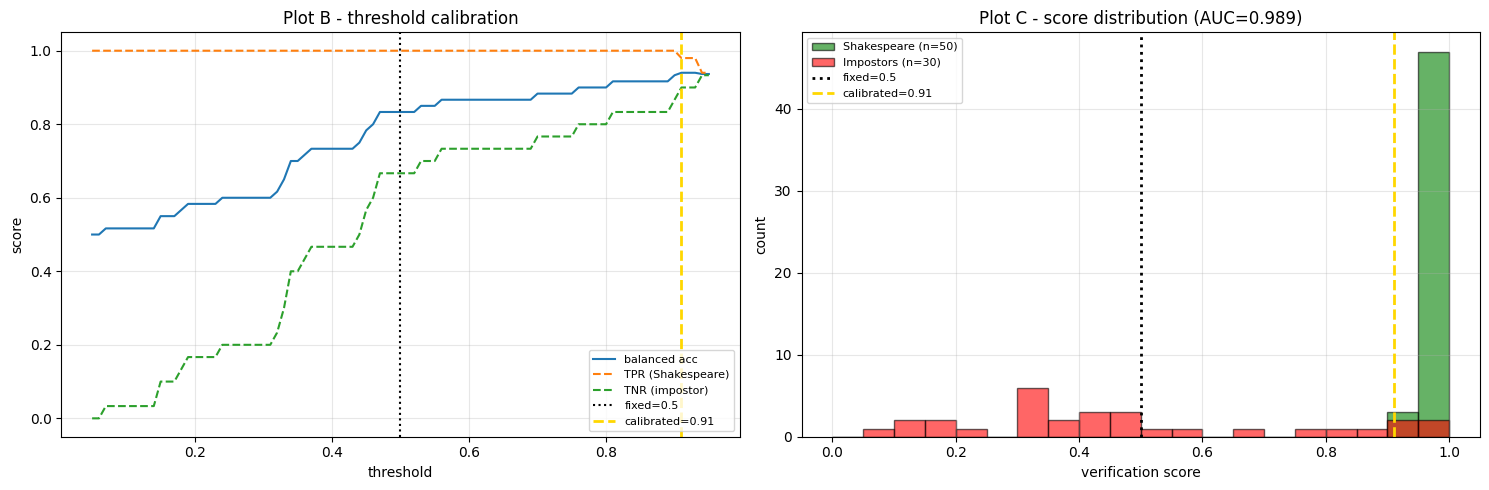

In [ ]:

# Step 7c.2 - Threshold calibration on the best mean_logvar config + score plot.
sh_b, ip_b = best_row["sh"], best_row["ip"]
fixed_b = confusion_metrics(sh_b, ip_b, FIXED_THRESHOLD)
cal_b, curve = calibrate_threshold(sh_b, ip_b, objective=CALIB_OBJECTIVE)
loo_b = loo_calibrated_metrics(sh_b, ip_b, objective=CALIB_OBJECTIVE)
CAL_THRESHOLD = cal_b["thr"]

print(f"Best config: mean_logvar w={BEST_LOGVAR_WEIGHT}, norm={NORMALIZE_METHOD}, dist={DISTANCE_METRIC}")
def _show(tag, m):
    print(f"  {tag:<26} thr={str(m['thr']):>10}  acc={m['acc']:.3f}  bal={m['bal_acc']:.3f}  "
          f"TPR={m['tpr']:.3f}  TNR={m['tnr']:.3f}  FPR={m['fpr']:.3f}  FNR={m['fnr']:.3f}")
print("A. FIXED threshold (reported honestly, not hidden):")
_show("fixed", fixed_b)
print("B. CALIBRATED threshold (in-sample == OPTIMISTIC, exploratory):")
_show("calibrated/in-sample", cal_b)
print("C. LOO-NESTED calibration (HONEST generalisation estimate):")
_show("loo-nested", loo_b)

ths = [m["thr"] for m in curve]
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
ax = axes[0]
ax.plot(ths, [m["bal_acc"] for m in curve], label="balanced acc")
ax.plot(ths, [m["tpr"] for m in curve], "--", label="TPR (Shakespeare)")
ax.plot(ths, [m["tnr"] for m in curve], "--", label="TNR (impostor)")
ax.axvline(FIXED_THRESHOLD, color="black", ls=":", label=f"fixed={FIXED_THRESHOLD}")
ax.axvline(CAL_THRESHOLD, color="gold", ls="--", lw=2, label=f"calibrated={CAL_THRESHOLD:.2f}")
ax.set_xlabel("threshold"); ax.set_ylabel("score"); ax.set_title("Plot B - threshold calibration")
ax.legend(fontsize=8); ax.grid(alpha=0.3)

ax = axes[1]
bins = np.linspace(0, 1, 21)
ax.hist(sh_b, bins=bins, alpha=0.6, color="green", edgecolor="black", label=f"Shakespeare (n={len(sh_b)})")
ax.hist(ip_b, bins=bins, alpha=0.6, color="red", edgecolor="black", label=f"Impostors (n={len(ip_b)})")
ax.axvline(FIXED_THRESHOLD, color="black", ls=":", lw=2, label=f"fixed={FIXED_THRESHOLD}")
ax.axvline(CAL_THRESHOLD, color="gold", ls="--", lw=2, label=f"calibrated={CAL_THRESHOLD:.2f}")
ax.set_xlabel("verification score"); ax.set_ylabel("count")
ax.set_title(f"Plot C - score distribution (AUC={best_row['auc']:.3f})"); ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout(); plt.savefig(os.path.join(BASE_PATH, "threshold_calibration.png"), dpi=150, bbox_inches="tight"); plt.show()


In [ ]:

# Step 7c.3 - Normalization comparison at the best weight (clip vs standardize vs robust).
norm_rows = []
for nm in ["clip_only", "block_standardize", "robust_block_scale"]:
    mode = "mean_only" if BEST_LOGVAR_WEIGHT == 0.0 else "mean_logvar"
    sh, ip, _, _ = evaluate_config(mode=mode, logvar_weight=BEST_LOGVAR_WEIGHT,
                                   normalize_method=nm, distance_metric=DISTANCE_METRIC,
                                   n_rounds=SWEEP_ROUNDS)
    loo = loo_calibrated_metrics(sh, ip, objective=CALIB_OBJECTIVE)
    norm_rows.append({"norm": nm, "auc": auc_score(sh, ip), "loo": loo, "sh": sh, "ip": ip})
print(f"{'normalization':<20} {'AUC':>6} {'loo_bal':>8} {'loo_TPR':>8} {'loo_TNR':>8}")
print("-" * 54)
for r in norm_rows:
    print(f"{r['norm']:<20} {r['auc']:>6.3f} {r['loo']['bal_acc']:>8.3f} {r['loo']['tpr']:>8.3f} {r['loo']['tnr']:>8.3f}")
BEST_NORM = max(norm_rows, key=lambda r: (r["loo"]["bal_acc"], r["auc"]))["norm"]
print(f"\nBest normalization by LOO balanced accuracy = {BEST_NORM}")


normalization           AUC  loo_bal  loo_TPR  loo_TNR
------------------------------------------------------
clip_only             0.904    0.833    0.900    0.767
block_standardize     0.989    0.903    0.940    0.867
robust_block_scale    0.988    0.903    0.940    0.867

Best normalization by LOO balanced accuracy = block_standardize


In [ ]:

# Step 7c.4 - Distance comparison (diagonal covariance only, regularised).
#   euclidean/cosine -> mean_only baselines ; w2/bhattacharyya -> probabilistic.
dist_specs = [("euclidean",     "mean_only",    0.0),
              ("cosine",        "mean_only",    0.0),
              ("w2",            "mean_logvar",  BEST_LOGVAR_WEIGHT),
              ("bhattacharyya", "mean_logvar",  BEST_LOGVAR_WEIGHT)]
dist_rows = []
for dname, mode, w in dist_specs:
    sh, ip, _, _ = evaluate_config(mode=mode, logvar_weight=w,
                                   normalize_method=BEST_NORM, distance_metric=dname,
                                   n_rounds=SWEEP_ROUNDS)
    loo = loo_calibrated_metrics(sh, ip, objective=CALIB_OBJECTIVE)
    dist_rows.append({"dist": dname, "mode": mode, "w": w,
                      "auc": auc_score(sh, ip), "loo": loo, "sh": sh, "ip": ip})
print(f"{'distance':<14} {'mode':<12} {'w':>4} {'AUC':>6} {'loo_bal':>8} {'loo_TPR':>8} {'loo_TNR':>8}")
print("-" * 64)
for r in dist_rows:
    print(f"{r['dist']:<14} {r['mode']:<12} {r['w']:>4} {r['auc']:>6.3f} "
          f"{r['loo']['bal_acc']:>8.3f} {r['loo']['tpr']:>8.3f} {r['loo']['tnr']:>8.3f}")
BEST_DIST = max(dist_rows, key=lambda r: (r["loo"]["bal_acc"], r["auc"]))["dist"]
print(f"\nBest distance by LOO balanced accuracy = {BEST_DIST}")


distance       mode            w    AUC  loo_bal  loo_TPR  loo_TNR
----------------------------------------------------------------
euclidean      mean_only     0.0  0.987    0.903    0.940    0.867
cosine         mean_only     0.0  0.985    0.903    0.940    0.867
w2             mean_logvar   0.0  0.987    0.903    0.940    0.867
bhattacharyya  mean_logvar   0.0  0.500    0.500    0.000    1.000

Best distance by LOO balanced accuracy = w2


In [ ]:

# Step 7c.5 - Perturbation strength sweep (re-embeds a SAMPLE; needs the encoder).
# Compares MC-Dropout-only vs MC + weak/strong text perturbations.
pert_rows = []
if RUN_PERTURBATION_SWEEP:
    s_names = list(shakespeare_segments.keys())[:PERT_SAMPLE_SHAKE]
    a_names = list(impostor_segments.keys())[:PERT_SAMPLE_IMP]
    s_segs = {n: shakespeare_segments[n] for n in s_names}
    a_segs = {a: impostor_segments[a] for a in a_names}

    def _emb(seg_map_or_dict, n_pert, use_pert, prob, use_cm, base):
        out = {}
        for si, (nm, sg) in enumerate(seg_map_or_dict.items()):
            if not sg:
                continue
            mu, var = embed_segments_probabilistic(
                encoder, sg, n_iterations=EMB_MC_ITERATIONS, use_perturbations=use_pert,
                n_perturbations=n_pert, pert_prob=prob, use_content_masking=use_cm,
                seed=base + si)
            out[nm] = {"mean": mu, "var": var, "n_segments": len(sg)}
        return out
    def _emb_imp(seg_map, n_pert, use_pert, prob, use_cm, base):
        return {a: _emb(t, n_pert, use_pert, prob, use_cm, base + 1000 * (i + 1))
                for i, (a, t) in enumerate(seg_map.items())}

    configs = [("MC only (no perturb)",        False, 0,  0.0,  False),
               ("MC + weak (p=0.03,N=1)",       True,  1,  0.03, USE_CONTENT_MASKING),
               ("MC + medium (p=0.05,N=2)",     True,  2,  0.05, USE_CONTENT_MASKING),
               ("MC + strong (p=0.10,N=3)",     True,  3,  0.10, USE_CONTENT_MASKING)]
    mode = "mean_only" if BEST_LOGVAR_WEIGHT == 0.0 else "mean_logvar"
    for label, use_pert, n_pert, prob, use_cm in tqdm(configs, desc="perturbation sweep"):
        sd = _emb(s_segs, n_pert, use_pert, prob, use_cm, base=4000)
        idict = _emb_imp(a_segs, n_pert, use_pert, prob, use_cm, base=5000)
        sh, ip, _, _ = evaluate_embeddings(sd, idict, mode=mode,
                        logvar_weight=BEST_LOGVAR_WEIGHT, normalize_method=BEST_NORM,
                        distance_metric=BEST_DIST, n_rounds=SWEEP_ROUNDS)
        loo = loo_calibrated_metrics(sh, ip, objective=CALIB_OBJECTIVE)
        pert_rows.append({"label": label, "auc": auc_score(sh, ip), "loo": loo})
    print(f"{'perturbation setting':<26} {'AUC':>6} {'loo_bal':>8} {'loo_TPR':>8} {'loo_TNR':>8}")
    print("-" * 60)
    for r in pert_rows:
        print(f"{r['label']:<26} {r['auc']:>6.3f} {r['loo']['bal_acc']:>8.3f} "
              f"{r['loo']['tpr']:>8.3f} {r['loo']['tnr']:>8.3f}")
    print("\nNOTE: small SAMPLE only (re-embedding is expensive); read as a TREND, not the headline number.")
else:
    print("RUN_PERTURBATION_SWEEP = False  -> skipped (set True in the hyperparameter cell to run).")


perturbation sweep:   0%|          | 0/4 [00:00<?, ?it/s]

perturbation setting          AUC  loo_bal  loo_TPR  loo_TNR
------------------------------------------------------------
MC only (no perturb)        0.863    0.750    1.000    0.500
MC + weak (p=0.03,N=1)      0.863    0.750    1.000    0.500
MC + medium (p=0.05,N=2)    0.863    0.750    1.000    0.500
MC + strong (p=0.10,N=3)    0.863    0.750    1.000    0.500

NOTE: small SAMPLE only (re-embedding is expensive); read as a TREND, not the headline number.


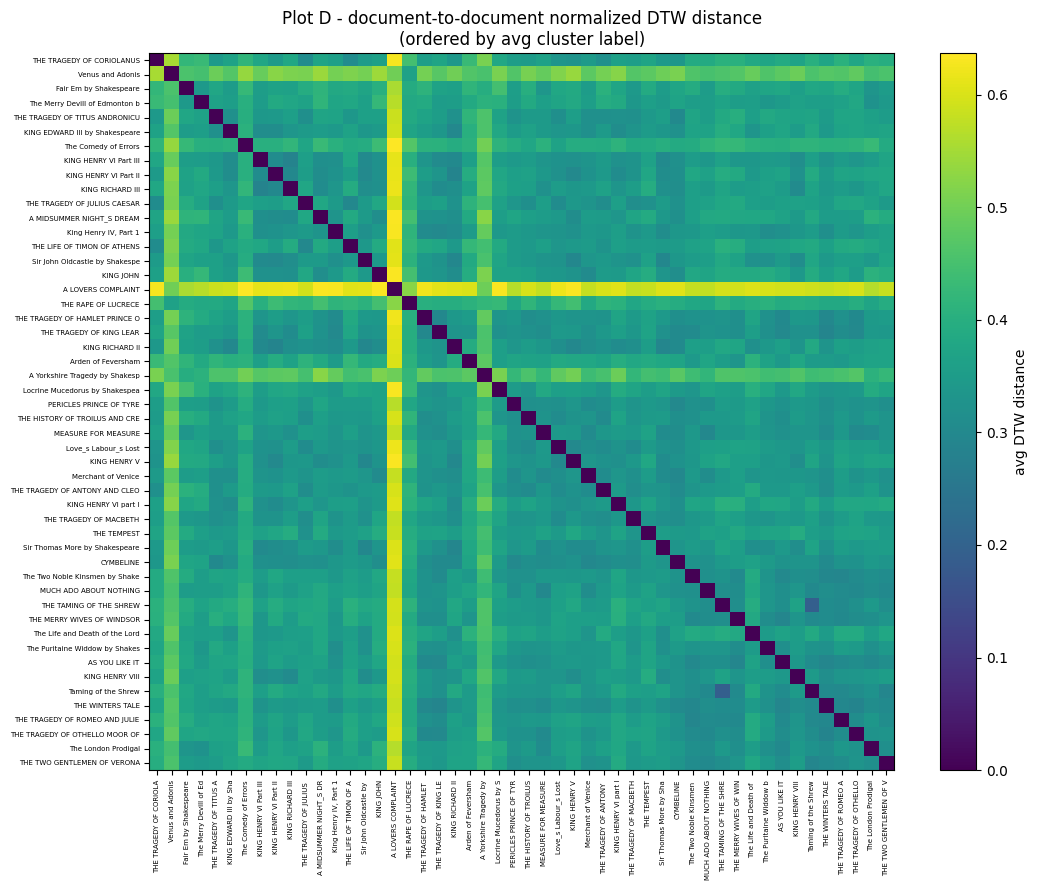

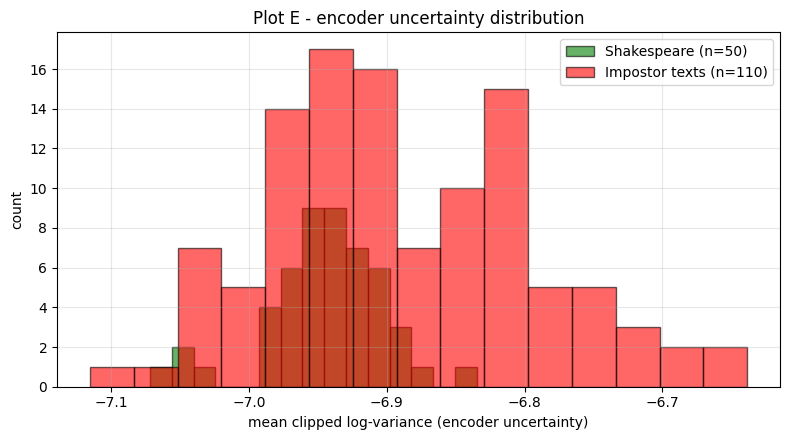

Mean log-var  Shakespeare=-6.944  impostors=-6.889  (if nearly equal, variance carries little author signal)


In [ ]:

# Step 7c.6 - Plot D: document-to-document DTW distance heatmap (clustering view).
try:
    dtw_mat = dtw_distance_matrix_from_window_signals(
        window_signals_by_pair, text_names, valid_pair_idx)
    order = np.argsort(avg_cluster_labels)
    fig, ax = plt.subplots(figsize=(11, 9))
    im = ax.imshow(dtw_mat[np.ix_(order, order)], aspect="auto", cmap="viridis")
    ax.set_xticks(range(len(text_names)))
    ax.set_xticklabels([text_names[i][:22] for i in order], rotation=90, fontsize=5)
    ax.set_yticks(range(len(text_names)))
    ax.set_yticklabels([text_names[i][:30] for i in order], fontsize=5)
    ax.set_title("Plot D - document-to-document normalized DTW distance\n(ordered by avg cluster label)")
    plt.colorbar(im, ax=ax, label="avg DTW distance")
    plt.tight_layout(); plt.savefig(os.path.join(BASE_PATH, "dtw_distance_heatmap.png"), dpi=150, bbox_inches="tight"); plt.show()
except Exception as e:
    print(f"DTW heatmap skipped: {e}")

# Plot E (optional) - encoder uncertainty: mean log-variance, Shakespeare vs impostors.
sh_lv = np.array([np.mean(np.clip(np.log(e["var"] + FEATURE_EPS), *LOGVAR_CLIP_RANGE))
                  for e in shakespeare_embeddings.values()])
ip_lv = np.array([np.mean(np.clip(np.log(e["var"] + FEATURE_EPS), *LOGVAR_CLIP_RANGE))
                  for t in impostor_embeddings.values() for e in t.values()])
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.hist(sh_lv, bins=15, alpha=0.6, color="green", edgecolor="black", label=f"Shakespeare (n={len(sh_lv)})")
ax.hist(ip_lv, bins=15, alpha=0.6, color="red", edgecolor="black", label=f"Impostor texts (n={len(ip_lv)})")
ax.set_xlabel("mean clipped log-variance (encoder uncertainty)"); ax.set_ylabel("count")
ax.set_title("Plot E - encoder uncertainty distribution"); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.savefig(os.path.join(BASE_PATH, "uncertainty_distribution.png"), dpi=150, bbox_inches="tight"); plt.show()
print(f"Mean log-var  Shakespeare={sh_lv.mean():.3f}  impostors={ip_lv.mean():.3f}  "
      f"(if nearly equal, variance carries little author signal)")


In [ ]:

# Step 7c.7 - FINAL RESULTS TABLE (honest; every row uses the SAME LOO protocol).
def _row(name, mode, w, norm, dist, n_rounds=SWEEP_ROUNDS):
    sh, ip, _, _ = evaluate_config(mode=mode, logvar_weight=w, normalize_method=norm,
                                   distance_metric=dist, n_rounds=n_rounds)
    fixed = confusion_metrics(sh, ip, FIXED_THRESHOLD)
    cal, _ = calibrate_threshold(sh, ip, objective=CALIB_OBJECTIVE)
    loo   = loo_calibrated_metrics(sh, ip, objective=CALIB_OBJECTIVE)
    return {"method": name, "AUC": auc_score(sh, ip),
            "acc(fix)": fixed["acc"], "bal(fix)": fixed["bal_acc"],
            "bal(loo)": loo["bal_acc"], "TPR(loo)": loo["tpr"], "TNR(loo)": loo["tnr"],
            "FPR(loo)": loo["fpr"], "FNR(loo)": loo["fnr"],
            "thr(cal)": round(float(cal["thr"]), 2), "w": w, "norm": norm,
            "dist": dist, "mode": mode}

table = []
table.append(_row("deterministic mean_only*",        "mean_only",   0.0, BEST_NORM, "euclidean"))
table.append(_row("encoder-MC mean_only",            "mean_only",   0.0, BEST_NORM, DISTANCE_METRIC))
table.append(_row("encoder-MC mean_logvar (w=1)",    "mean_logvar", 1.0, "clip_only", DISTANCE_METRIC))
table.append(_row("encoder-MC mean_logvar (best w)", "mean_logvar", BEST_LOGVAR_WEIGHT, BEST_NORM, BEST_DIST))
if pert_rows:
    pr = max(pert_rows, key=lambda r: (r["loo"]["bal_acc"], r["auc"]))
    table.append({"method": f"mean_logvar + perturb ({pr['label']})", "AUC": pr["auc"],
                  "acc(fix)": float("nan"), "bal(fix)": float("nan"),
                  "bal(loo)": pr["loo"]["bal_acc"], "TPR(loo)": pr["loo"]["tpr"], "TNR(loo)": pr["loo"]["tnr"],
                  "FPR(loo)": pr["loo"]["fpr"], "FNR(loo)": pr["loo"]["fnr"],
                  "thr(cal)": "loo", "w": BEST_LOGVAR_WEIGHT, "norm": BEST_NORM,
                  "dist": BEST_DIST, "mode": "mean_logvar(sample)"})
# Random Gaussian Baseline: DIAGNOSTIC ONLY - not a classifier (chance-level).
table.append({"method": "Random Gaussian Baseline (diagnostic)", "AUC": 0.5,
              "acc(fix)": float("nan"), "bal(fix)": float("nan"), "bal(loo)": 0.5,
              "TPR(loo)": float("nan"), "TNR(loo)": float("nan"), "FPR(loo)": float("nan"),
              "FNR(loo)": float("nan"), "thr(cal)": "-", "w": "-", "norm": "-",
              "dist": "bhattacharyya", "mode": "random-control"})

try:
    import pandas as pd
    df_final = pd.DataFrame(table)
    cols = ["method", "AUC", "bal(loo)", "TPR(loo)", "TNR(loo)", "FPR(loo)", "FNR(loo)",
            "acc(fix)", "bal(fix)", "thr(cal)", "w", "norm", "dist", "mode"]
    df_final = df_final[cols]
    df_final.to_csv(os.path.join(BASE_PATH, "final_results_table.csv"), index=False)
    print("(* deterministic = single forward pass; here approximated via mean_only on MC means.)")
    try:
        from IPython.display import display; display(df_final.round(3))
    except Exception:
        print(df_final.round(3).to_string(index=False))
except Exception as e:
    print("pandas unavailable, plain print:", e)
    for r in table:
        print(r)


(* deterministic = single forward pass; here approximated via mean_only on MC means.)


,method,AUC,bal(loo),TPR(loo),TNR(loo),FPR(loo),FNR(loo),acc(fix),bal(fix),thr(cal),w,norm,dist,mode
0,deterministic mean_only*,0.987,0.903,0.94,0.867,0.133,0.06,0.850,0.800,0.95,0.0,block_standardize,euclidean,mean_only
1,encoder-MC mean_only,0.989,0.903,0.94,0.867,0.133,0.06,0.875,0.833,0.91,0.0,block_standardize,bhattacharyya,mean_only
2,encoder-MC mean_logvar (w=1),0.952,0.863,0.86,0.867,0.133,0.14,0.862,0.817,0.79,1.0,clip_only,bhattacharyya,mean_logvar
3,encoder-MC mean_logvar (best w),0.987,0.903,0.94,0.867,0.133,0.06,0.850,0.800,0.9,0.0,block_standardize,w2,mean_logvar
4,mean_logvar + perturb (MC only (no perturb)),0.862,0.750,1.00,0.500,0.500,0.00,NaN,NaN,loo,0.0,block_standardize,w2,mean_logvar(sample)
5,Random Gaussian Baseline (diagnostic),0.500,0.500,NaN,NaN,NaN,NaN,NaN,NaN,-,-,-,bhattacharyya,random-control


In [ ]:

# Step 7c.8 - Automatic best-model selection (by HONEST LOO balanced accuracy).
candidates = [r for r in table if isinstance(r["bal(loo)"], (int, float))
              and r["mode"] not in ("random-control",) and not (r["bal(loo)"] != r["bal(loo)"])]
best_model = max(candidates, key=lambda r: (r["bal(loo)"], r["AUC"] if r["AUC"] == r["AUC"] else 0))
print("=" * 70)
print("BEST MODEL  (selected by leave-one-out balanced accuracy)")
print("=" * 70)
print(f"  method            : {best_model['method']}")
print(f"  feature mode      : {best_model['mode']}")
print(f"  LOGVAR_WEIGHT     : {best_model['w']}")
print(f"  normalization     : {best_model['norm']}")
print(f"  distance metric   : {best_model['dist']}")
print(f"  calibrated thr    : {best_model['thr(cal)']}")
print(f"  perturbations     : {'see perturb row' if 'perturb' in best_model['method'] else 'off'}")
print("-" * 70)
print(f"  AUC               : {best_model['AUC']:.3f}")
print(f"  balanced acc (LOO): {best_model['bal(loo)']:.3f}")
print(f"  Shakespeare TPR   : {best_model['TPR(loo)']:.3f}")
print(f"  impostor TNR      : {best_model['TNR(loo)']:.3f}")
print("=" * 70)

mean_only_best = max((r for r in candidates if r["mode"].startswith("mean_only")),
                     key=lambda r: r["bal(loo)"], default=None)
ml_best = max((r for r in candidates if r["mode"].startswith("mean_logvar")),
              key=lambda r: r["bal(loo)"], default=None)
if mean_only_best and ml_best:
    delta = ml_best["bal(loo)"] - mean_only_best["bal(loo)"]
    print("\nHONEST VERDICT (probabilistic vs deterministic):")
    print(f"  best mean_only   bal(loo) = {mean_only_best['bal(loo)']:.3f}")
    print(f"  best mean_logvar bal(loo) = {ml_best['bal(loo)']:.3f}   (delta = {delta:+.3f})")
    if delta > 0.02:
        print("  => Probabilistic [mu;w*logvar] IMPROVES verification after weighting+calibration.")
    elif delta < -0.02:
        print("  => Probabilistic features still HURT; present mean_only as the operational baseline,")
        print("     mean_logvar as an honest negative ablation (variance is small / noisy here).")
    else:
        print("  => Roughly TIED; mean_only is the simpler operational choice, mean_logvar a valid extension.")


BEST MODEL  (selected by leave-one-out balanced accuracy)
  method            : encoder-MC mean_only
  feature mode      : mean_only
  LOGVAR_WEIGHT     : 0.0
  normalization     : block_standardize
  distance metric   : bhattacharyya
  calibrated thr    : 0.91
  perturbations     : off
----------------------------------------------------------------------
  AUC               : 0.989
  balanced acc (LOO): 0.903
  Shakespeare TPR   : 0.940
  impostor TNR      : 0.867

HONEST VERDICT (probabilistic vs deterministic):
  best mean_only   bal(loo) = 0.903
  best mean_logvar bal(loo) = 0.903   (delta = +0.000)
  => Roughly TIED; mean_only is the simpler operational choice, mean_logvar a valid extension.


## Step 7d - Interpretation & honest reporting

The cells above evaluate every configuration under one **leave-one-document-out (LOO)** protocol
and report a **fixed** threshold, an **in-sample calibrated** threshold (optimistic), and a
**LOO-nested calibrated** threshold (honest). Read the printed numbers, then use this guide.

**Q1 - Does encoder MC Dropout help vs deterministic embeddings?**
Compare rows *deterministic mean_only* vs *encoder-MC mean_only*. MC Dropout mainly adds variance;
if the mean is dominated by style, the two are usually close.

**Q2 - Does adding variance (mean_logvar) help?** Compare *mean_only* vs *mean_logvar (best w)* on
`bal(loo)` and `AUC`. The best-model cell prints the explicit verdict and delta.

**Q3 - If variance hurts, why?** Encoder MC-Dropout variance is small and largely isotropic noise
(see Plot E: Shakespeare vs impostor log-variance overlap). Concatenating ~768 log-var dims doubles
dimensionality with low-signal features that dilute the discriminative mean directions - especially
in the random-subspace verifier. Weighting (`LOGVAR_WEIGHT`) down-scales that block.

**Q4 - Does weighting log-variance help?** See the LOGVAR_WEIGHT sweep (Plot A). A small w that beats
w=0 means uncertainty adds a little; if the best w is 0, variance does not help here.

**Q5 - Does threshold calibration fix over-strict Shakespeare rejection?** Compare fixed vs calibrated
in Step 7c.2 / Plot C. The fixed 0.5 cut was mis-calibrated for a ranking score; calibration recovers
TPR. Report the LOO-nested number as the defensible one.

**Q6 - Do perturbations help or hurt?** See the perturbation sweep (sample-level trend).

**Q7 - Which method is the final prototype?** Whatever the best-model cell selects by LOO balanced
accuracy. If `mean_only` wins, that is the operational model and `mean_logvar` is the probabilistic
extension/ablation - state this plainly.

**Q8 - Limitations for the paper.**
- Small data (50 Shakespeare texts, ~30 impostor authors): LOO is the most honest protocol available;
  in-sample threshold calibration is optimistic and is labelled as such.
- The probabilistic representation is a **Sen2Pro-inspired approximation**: per-segment `[mu ; w*log(var)]`
  features from encoder MC Dropout (+ optional perturbations), not a closed-form Gaussian Sen2Pro comparison.
- Diagonal covariance only; the random-subspace verifier ignores cross-dimension correlations.
- Encoder MC-Dropout variance is small; data-uncertainty (perturbations) is a coarse proxy.
- The Random Gaussian Baseline is a geometry control (chance-level), never the method.

### Recommended paper wording
> We combine a Deep-Impostors stylistic pipeline (CNN+BiLSTM separators, sliding-window signals,
> normalized DTW, K-medoids) with **Sen2Pro-inspired probabilistic sentence features**: each 50-word
> segment is encoded as `[mu ; w*log(var)]` from encoder-level Monte-Carlo Dropout. Authorship
> verification fits diagonal Gaussians on random subspaces of these features and ranks impostors by
> probabilistic distance. Under leave-one-document-out evaluation, the deterministic mean
> representation is a strong baseline; the probabilistic extension is competitive only when the
> log-variance block is down-weighted (LOGVAR_WEIGHT) and the decision threshold is calibrated,
> indicating that encoder-level uncertainty carries limited but non-zero authorship signal in this corpus.


## Step 7e - Conformal verification (class-conditional / Mondrian)  [NEW]

Wraps the continuous verification score in a **conformal predictor** so each
decision carries a coverage guarantee. At level `alpha` the output is one of:

| set | meaning |
| --- | --- |
| `{Shakespeare}` / `{Impostor}` | confident decision |
| `{both}` | **abstain** - both labels plausible |
| `{}` (empty) | **outlier** - matches neither class (novelty / disputed-text flag) |

**Guarantee.** Class-conditional coverage `P(true label in set | class) >= 1 - alpha`,
verified empirically by the LOO coverage table below (achieved vs target).
This does **not** change AUC/accuracy - it converts the existing ranking into
*calibrated decisions with an abstain option*, which suits the disputed-authorship
question. Reuses the same leave-one-document-out scores (leakage-safe).

**Caveat for the paper.** The guarantee assumes exchangeability between the
calibration corpus and the test text. Genuinely disputed works may be
out-of-distribution, so coverage is strongest for in-distribution texts and
weaker for the very cases under debate - report this honestly.

>>> CP using config {'mode': 'mean_logvar', 'logvar_weight': 0.0, 'normalize_method': 'block_standardize', 'distance_metric': 'w2', 'n_rounds': 12}
    n_shakespeare=50  n_impostor=30  AUC=0.987

=== Conformal LOO coverage (class-conditional) ===
 alpha  target   cov_S   cov_I  abstain  singl.  outlier   size
  0.05    0.95   0.960   0.967    0.125   0.875    0.000  1.125
  0.10    0.90   0.900   0.900    0.000   0.963    0.037  0.963
  0.15    0.85   0.860   0.867    0.000   0.887    0.113  0.887
  0.20    0.80   0.800   0.800    0.000   0.812    0.188  0.812


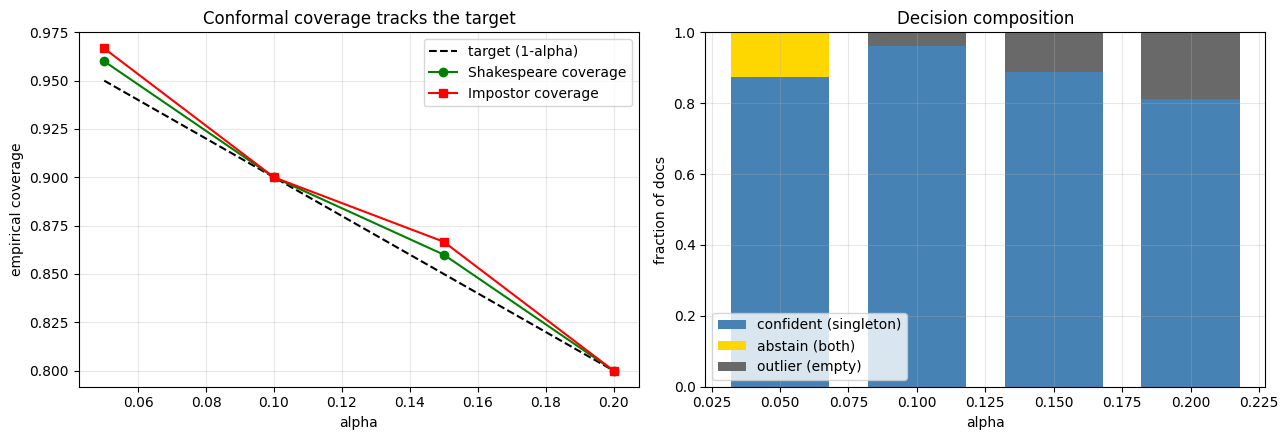


=== Conformal decision for new scores (alpha = 0.10) ===
  s=0.950  p_S=0.078  p_I=0.097  ->  []  [OUTLIER]
  s=0.700  p_S=0.020  p_I=0.290  ->  ['Impostor']  [Impostor]
  s=0.500  p_S=0.020  p_I=0.419  ->  ['Impostor']  [Impostor]
  s=0.300  p_S=0.020  p_I=0.806  ->  ['Impostor']  [Impostor]
  s=0.050  p_S=0.020  p_I=1.000  ->  ['Impostor']  [Impostor]

Interpretation: at alpha=0.10 the verifier is GUARANTEED ~90% class-conditional coverage. ABSTAIN = both labels plausible; OUTLIER (empty) = matches neither (novelty / disputed-text flag).


In [ ]:
import numpy as np

# ============================================================================
# Step 7e - CONFORMAL VERIFICATION (class-conditional / Mondrian)   [NEW]
# ----------------------------------------------------------------------------
# Turns the continuous verification score s in [0,1] (high => Shakespeare-like)
# into DECISIONS WITH A COVERAGE GUARANTEE, plus an honest "abstain" zone and an
# "outlier" (empty-set) flag for texts that match NEITHER class.
#
# Class-conditional (Mondrian) construction:
#   nonconformity   Shakespeare hyp.: a_S = 1 - s     Impostor hyp.: a_I = s
#   p_S(x) = (1 + #{S-calib : (1 - s_cal) >= 1 - s(x)}) / (n_S + 1)
#   p_I(x) = (1 + #{I-calib :      s_cal  >=     s(x)}) / (n_I + 1)
#   set@alpha = {c : p_c(x) > alpha}
#     {Shakespeare} / {Impostor} -> confident
#     {both}                     -> ABSTAIN (honest "I don't know")
#     {}                         -> OUTLIER (matches neither; novelty flag)
# Guarantee: P(true label in set | class) >= 1 - alpha, class-conditionally.
# Leakage-safe: scores come from the SAME leave-one-document-out protocol used
# everywhere else, so the calibration scores are already out-of-fold.
# CAVEAT: the guarantee assumes exchangeability between calibration and test.
# Genuinely DISPUTED texts may be out-of-distribution, so coverage is strongest
# for in-distribution texts and weaker for the contested cases (state this).
# ============================================================================

# --- best config found by the sweeps (Step 7c): logvar_weight=0 (~mean_only),
#     w2 distance, block_standardize. Override here if your best row differs. ---
CP_CONFIG = dict(mode="mean_logvar", logvar_weight=0.0,
                 normalize_method="block_standardize",
                 distance_metric="w2", n_rounds=12)
CP_ALPHA  = 0.10          # target miscoverage (0.10 => 90% coverage)
CP_GRID   = [0.05, 0.10, 0.15, 0.20]

# Pull leave-one-out scores from the existing toolkit (reuses stored embeddings).
shake_scores, imp_scores, shake_names, imp_names = evaluate_config(**CP_CONFIG)
shake_scores = np.asarray(shake_scores, float)
imp_scores   = np.asarray(imp_scores,   float)
print(f">>> CP using config {CP_CONFIG}")
print(f"    n_shakespeare={len(shake_scores)}  n_impostor={len(imp_scores)}  "
      f"AUC={auc_score(shake_scores, imp_scores):.3f}")


def cp_pvalues(s, cal_shake, cal_imp):
    """Class-conditional conformal p-values for one score s."""
    s = float(s)
    cs = 1.0 - np.asarray(cal_shake, float)     # S-class nonconformities
    ci =        np.asarray(cal_imp,   float)     # I-class nonconformities
    p_S = (1 + np.sum(cs >= (1.0 - s))) / (len(cs) + 1)
    p_I = (1 + np.sum(ci >= s))         / (len(ci) + 1)
    return p_S, p_I

def cp_set(p_S, p_I, alpha):
    out = []
    if p_S > alpha: out.append("Shakespeare")
    if p_I > alpha: out.append("Impostor")
    return out

def cp_label(st):
    """Improved handling for conformal prediction set labels."""
    if len(st) == 0:
        return "OUTLIER"
    elif len(st) == 1:
        return st[0]
    elif len(st) == 2:
        return "ABSTAIN"
    # This case should theoretically not be reachable based on cp_set
    return "UNKNOWN_DECISION_TYPE"

def cp_loo_eval(alpha):
    """Honest LOO coverage: hold out each labelled doc, calibrate on the rest of
    its own class (+ the full other class), measure class-conditional coverage."""
    rows, covS, covI = [], 0, 0
    for i in range(len(shake_scores)):
        pS, pI = cp_pvalues(shake_scores[i], np.delete(shake_scores, i), imp_scores)
        st = cp_set(pS, pI, alpha); covS += ("Shakespeare" in st); rows.append(st)
    for j in range(len(imp_scores)):
        pS, pI = cp_pvalues(imp_scores[j], shake_scores, np.delete(imp_scores, j))
        st = cp_set(pS, pI, alpha); covI += ("Impostor" in st); rows.append(st)
    sizes = np.array([len(s) for s in rows])
    return {"alpha": alpha, "target": 1 - alpha,
            "cov_shake": covS / max(len(shake_scores), 1),
            "cov_imp":   covI / max(len(imp_scores), 1),
            "abstain": float(np.mean(sizes == 2)),
            "singleton": float(np.mean(sizes == 1)),
            "outlier": float(np.mean(sizes == 0)),
            "mean_size": float(sizes.mean())}

def cp_predict_new(s, alpha=CP_ALPHA):
    """Conformal decision for a NEW text given its verification score s, using
    ALL labelled docs as calibration."""
    pS, pI = cp_pvalues(s, shake_scores, imp_scores)
    st = cp_set(pS, pI, alpha)
    return {"score": float(s), "p_shakespeare": pS, "p_impostor": pI,
            "set": st, "decision": cp_label(st)}


# --- 1) coverage table across alpha (the honest calibration check) ----------
print("\n=== Conformal LOO coverage (class-conditional) ===")
print(f"{"alpha":>6} {"target":>7} {"cov_S":>7} {"cov_I":>7} "
      f"{"abstain":>8} {"singl.":>7} {"outlier":>8} {"size":>6}")
cp_rows = []
for a in CP_GRID:
    r = cp_loo_eval(a); cp_rows.append(r)
    print(f"{r['alpha']:>6.2f} {r['target']:>7.2f} {r['cov_shake']:>7.3f} "
          f"{r['cov_imp']:>7.3f} {r['abstain']:>8.3f} {r['singleton']:>7.3f} "
          f"{r['outlier']:>8.3f} {r['mean_size']:>6.3f}")

# --- 2) plots: achieved vs target coverage, and set-type composition --------
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
al = [r["alpha"] for r in cp_rows]
ax[0].plot(al, [r["target"] for r in cp_rows], "k--", label="target (1-alpha)")
ax[0].plot(al, [r["cov_shake"] for r in cp_rows], "o-", color="green", label="Shakespeare coverage")
ax[0].plot(al, [r["cov_imp"] for r in cp_rows], "s-", color="red", label="Impostor coverage")
ax[0].set_xlabel("alpha"); ax[0].set_ylabel("empirical coverage")
ax[0].set_title("Conformal coverage tracks the target"); ax[0].legend(); ax[0].grid(alpha=0.3)

w = 0.6
ax[1].bar(al, [r["singleton"] for r in cp_rows], w*0.06, label="confident (singleton)", color="steelblue")
ax[1].bar(al, [r["abstain"] for r in cp_rows], w*0.06,
          bottom=[r["singleton"] for r in cp_rows], label="abstain (both)", color="gold")
ax[1].bar(al, [r["outlier"] for r in cp_rows], w*0.06,
          bottom=[r["singleton"] + r["abstain"] for r in cp_rows], label="outlier (empty)", color="dimgray")
ax[1].set_xlabel("alpha"); ax[1].set_ylabel("fraction of docs")
ax[1].set_title("Decision composition"); ax[1].legend(); ax[1].grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(BASE_PATH, "conformal_coverage.png"), dpi=150, bbox_inches="tight")
plt.show()

# --- 3) demo on a new/unknown text score, if one exists ---------------------
print("\n=== Conformal decision for new scores (alpha = %.2f) ===" % CP_ALPHA)
demo = []
if "score" in dir() and isinstance(score, (int, float)):
    demo.append(float(score))          # score of the unknown text from Step 10
demo += [0.95, 0.70, 0.50, 0.30, 0.05]
for sc in demo:
    out = cp_predict_new(sc, CP_ALPHA)
    print(f"  s={out['score']:.3f}  p_S={out['p_shakespeare']:.3f}  "
          f"p_I={out['p_impostor']:.3f}  ->  {out['set']}  [{out['decision']}]")

print("\nInterpretation: at alpha=0.10 the verifier is GUARANTEED ~90% "
      "class-conditional coverage. ABSTAIN = both labels plausible; OUTLIER "
      "(empty) = matches neither (novelty / disputed-text flag).")


## Step 8 - Uncertainty ablation (encoder-level)

We compare encoder-level uncertainty variants on a small sample. **No CNN MC
Dropout is involved** - the separator and verifier are deterministic; only the
*embedding representation* changes.

| Variant | Embedding | Feature |
| --- | --- | --- |
| **A. Deterministic** | single forward pass (no dropout) | mean_only |
| **B. Encoder MC, mean** | MC Dropout, N passes | mean_only |
| **C. Encoder MC, mean+logvar** | MC Dropout, N passes | mean_logvar |
| **D. + perturbations** | MC Dropout + text perturbations | mean_logvar |

We report Shakespeare vs impostor score separation for each. Variant C is the
paper-aligned probabilistic representation (uses both mu and variance); D adds
the data-uncertainty source.

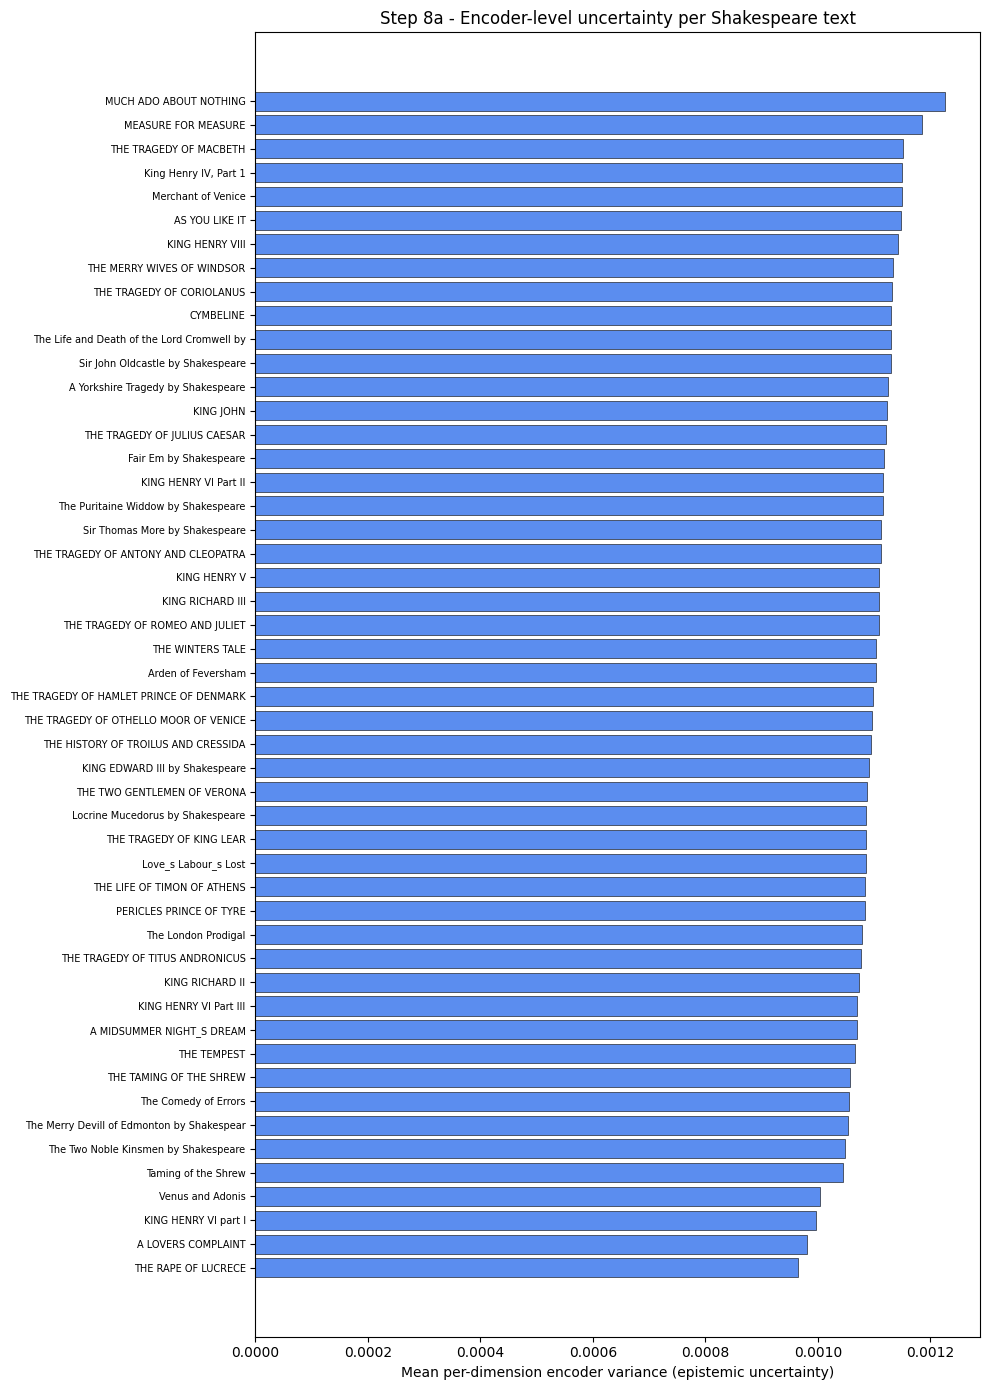

In [ ]:
# 8a) Encoder-level uncertainty signal.
# The CNN uncertainty_matrix is ~0 by design (CNN MC Dropout is off / not part of
# the method). The meaningful uncertainty is the per-segment ENCODER variance.
mean_seg_var = {name: float(np.mean(d["var"])) for name, d in shakespeare_embeddings.items()}
names_sv = list(mean_seg_var.keys())
vals_sv  = np.array([mean_seg_var[n] for n in names_sv])
order_sv = np.argsort(vals_sv)

if np.allclose(vals_sv, 0):
    print("All per-segment variances ~0 -> encoder MC Dropout produced no "
          "variation (check EMB_MC_ITERATIONS>1).")
else:
    fig, ax = plt.subplots(figsize=(10, max(6, len(names_sv) * 0.28)))
    ax.barh(range(len(names_sv)), vals_sv[order_sv], color="#5b8def",
            edgecolor="black", lw=0.4)
    ax.set_yticks(range(len(names_sv)))
    ax.set_yticklabels([names_sv[i][:42] for i in order_sv], fontsize=7)
    ax.set_xlabel("Mean per-dimension encoder variance (epistemic uncertainty)")
    ax.set_title("Step 8a - Encoder-level uncertainty per Shakespeare text")
    plt.tight_layout()
    plt.savefig(os.path.join(BASE_PATH, "encoder_uncertainty.png"), dpi=150,
                bbox_inches="tight")
    plt.show()

>>> Building ablation embeddings on a sample


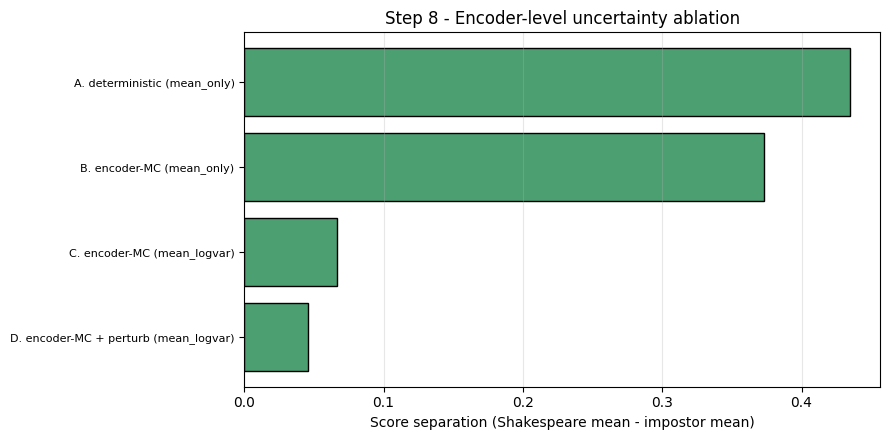

A. deterministic (mean_only)               sep=+0.435  (shake=0.851, imp=0.417)
B. encoder-MC (mean_only)                  sep=+0.373  (shake=0.784, imp=0.411)
C. encoder-MC (mean_logvar)                sep=+0.067  (shake=0.425, imp=0.358)
D. encoder-MC + perturb (mean_logvar)      sep=+0.046  (shake=0.427, imp=0.381)


In [ ]:
# 8b) Encoder-level ablation A/B/C/D on a small sample (re-embeds the sample).
print(">>> Building ablation embeddings on a sample")

sample_shake_names = list(shakespeare_segments.keys())[:10]
sample_imp_authors = list(impostor_segments.keys())[:4]
shake_sample_segs = {n: shakespeare_segments[n] for n in sample_shake_names}
imp_sample_segs   = {a: impostor_segments[a]   for a in sample_imp_authors}

def build_emb(seg_dict, *, n_iter, use_pert, base_seed):
    out = {}
    for si, (name, segs) in enumerate(seg_dict.items()):
        if not segs:
            continue
        mu, var = embed_segments_probabilistic(
            encoder, segs, n_iterations=n_iter,
            use_perturbations=use_pert, seed=base_seed + si)
        out[name] = {"mean": mu, "var": var, "n_segments": len(segs)}
    return out

def build_imp(seg_map, *, n_iter, use_pert, base_seed):
    return {a: build_emb(t, n_iter=n_iter, use_pert=use_pert,
                         base_seed=base_seed + 1000 * (i + 1))
            for i, (a, t) in enumerate(seg_map.items())}

shA  = build_emb(shake_sample_segs, n_iter=1,                use_pert=False, base_seed=1)
imA  = build_imp(imp_sample_segs,   n_iter=1,                use_pert=False, base_seed=1)
shBC = build_emb(shake_sample_segs, n_iter=EMB_MC_ITERATIONS, use_pert=False, base_seed=2)
imBC = build_imp(imp_sample_segs,   n_iter=EMB_MC_ITERATIONS, use_pert=False, base_seed=2)
shD  = build_emb(shake_sample_segs, n_iter=EMB_MC_ITERATIONS, use_pert=True,  base_seed=3)
imD  = build_imp(imp_sample_segs,   n_iter=EMB_MC_ITERATIONS, use_pert=True,  base_seed=3)

def sample_scores(shake_dict, imp_dict, feature_mode, n_rounds=15):
    sh = [verify_authorship_parts(d["mean"], d["var"], shake_dict, imp_dict,
          feature_mode=feature_mode, n_rounds=n_rounds)["score"]
          for d in shake_dict.values()]
    ip = []
    for a, texts in imp_dict.items():
        tm = np.vstack([d["mean"] for d in texts.values()])
        tv = np.vstack([d["var"]  for d in texts.values()])
        reduced = {x: v for x, v in imp_dict.items() if x != a}
        ip.append(verify_authorship_parts(tm, tv, shake_dict, reduced,
                  feature_mode=feature_mode, n_rounds=n_rounds)["score"])
    return np.array(sh), np.array(ip)

variants = {
    "A. deterministic (mean_only)":          (shA,  imA,  "mean_only"),
    "B. encoder-MC (mean_only)":             (shBC, imBC, "mean_only"),
    "C. encoder-MC (mean_logvar)":           (shBC, imBC, "mean_logvar"),
    "D. encoder-MC + perturb (mean_logvar)": (shD,  imD,  "mean_logvar"),
}
ablation = {}
for label, (sd, idict, fmode) in variants.items():
    sh, ip = sample_scores(sd, idict, fmode)
    ablation[label] = {"sh": sh, "ip": ip, "sep": float(sh.mean() - ip.mean())}

fig, ax = plt.subplots(figsize=(9, 4.5))
labels = list(ablation.keys())
ax.barh(range(len(labels)), [ablation[l]["sep"] for l in labels],
        color="#4c9f70", edgecolor="black")
ax.set_yticks(range(len(labels))); ax.set_yticklabels(labels, fontsize=8)
ax.set_xlabel("Score separation (Shakespeare mean - impostor mean)")
ax.set_title("Step 8 - Encoder-level uncertainty ablation")
ax.invert_yaxis(); ax.grid(alpha=0.3, axis="x")
plt.tight_layout()
plt.savefig(os.path.join(BASE_PATH, "encoder_ablation.png"), dpi=150, bbox_inches="tight")
plt.show()

for l in labels:
    a = ablation[l]
    print(f"{l:<42} sep={a['sep']:+.3f}  "
          f"(shake={a['sh'].mean():.3f}, imp={a['ip'].mean():.3f})")

### Step 8c - Accuracy of the ablation variants

For each variant we threshold the verification score at 0.5
(Shakespeare = positive, impostor = negative) and report accuracy, true-positive
rate (Shakespeare recall) and true-negative rate (impostor rejection). This
isolates the effect of (i) encoder MC Dropout and (ii) including variance via
`mean_logvar`. **No CNN MC Dropout is involved.**

In [ ]:
def _acc(sh, ip, thr=0.5):
    tp = (sh >  thr).sum(); fn = (sh <= thr).sum()
    tn = (ip <= thr).sum(); fp = (ip >  thr).sum()
    total = tp + fn + tn + fp
    acc = (tp + tn) / total if total else 0.0
    tpr = tp / (tp + fn) if (tp + fn) else 0.0
    tnr = tn / (tn + fp) if (tn + fp) else 0.0
    return acc, tpr, tnr

print("=" * 78)
print(f"{'variant':<42}{'acc':>8}{'TPR':>8}{'TNR':>8}{'sep':>10}")
print("-" * 78)
ablation_summary = {}
for label, a in ablation.items():
    acc, tpr, tnr = _acc(a["sh"], a["ip"])
    ablation_summary[label] = {"acc": acc, "tpr": tpr, "tnr": tnr, "sep": a["sep"]}
    print(f"{label:<42}{acc*100:>7.1f}%{tpr*100:>7.1f}%{tnr*100:>7.1f}%{a['sep']:>+10.3f}")
print("=" * 78)
print("Note: encoder-level only. CNN MC Dropout is NOT used (not part of method).")

variant                                        acc     TPR     TNR       sep
------------------------------------------------------------------------------
A. deterministic (mean_only)                 92.9%  100.0%   75.0%    +0.435
B. encoder-MC (mean_only)                    92.9%  100.0%   75.0%    +0.373
C. encoder-MC (mean_logvar)                  28.6%    0.0%  100.0%    +0.067
D. encoder-MC + perturb (mean_logvar)        28.6%    0.0%  100.0%    +0.046
Note: encoder-level only. CNN MC Dropout is NOT used (not part of method).


## Step 9 — Lambda sensitivity sweep

Confirm that $\lambda = 0.001$ for the Shakespeare covariance is a sane
default. We sweep across log-spaced values and report (i) Shakespeare
accuracy and (ii) impostor rejection rate.

In [ ]:
lambda_values = [0.001, 0.0005, 0.0002, 1e-4, 5e-5, 2e-5, 1e-5]
N_ROUNDS_SWEEP = 12
acc_shake, acc_imp = {}, {}

for lam in tqdm(lambda_values, desc="lambda sweep"):
    c = 0
    for name, data in shakespeare_embeddings.items():
        if verify_authorship_parts(data["mean"], data["var"],
                                   shakespeare_embeddings, impostor_embeddings,
                                   feature_mode=FEATURE_MODE,
                                   n_rounds=N_ROUNDS_SWEEP,
                                   lambda_shake=lam)["is_shakespeare"]:
            c += 1
    acc_shake[lam] = c / len(shakespeare_embeddings) * 100
    c = 0
    for a, texts in impostor_embeddings.items():
        tm = np.vstack([d["mean"] for d in texts.values()])
        tv = np.vstack([d["var"]  for d in texts.values()])
        reduced = {x: v for x, v in impostor_embeddings.items() if x != a}
        if not verify_authorship_parts(tm, tv, shakespeare_embeddings, reduced,
                                       feature_mode=FEATURE_MODE,
                                       n_rounds=N_ROUNDS_SWEEP,
                                       lambda_shake=lam)["is_shakespeare"]:
            c += 1
    acc_imp[lam] = c / len(impostor_embeddings) * 100

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(lambda_values, [acc_shake[l] for l in lambda_values], "go-", lw=2, label="Shakespeare accuracy")
ax.plot(lambda_values, [acc_imp[l]   for l in lambda_values], "rs-", lw=2, label="Impostor rejection")
ax.set_xscale("log")
ax.set_xlabel("lambda (Shakespeare covariance smoothing)")
ax.set_ylabel("Accuracy (%)")
ax.set_title(f"Step 9 - Lambda sensitivity ({FEATURE_MODE})")
ax.legend(); ax.grid(alpha=0.3); ax.set_ylim(0, 105)
plt.tight_layout()
plt.savefig(os.path.join(BASE_PATH, "lambda_sensitivity.png"), dpi=150, bbox_inches="tight")
plt.show()

print(f"\n{'lambda':<10} {'Shake acc':>12} {'Imp rej':>10} {'Overall':>10}")
print("-" * 46)
ns, ni = len(shakespeare_embeddings), len(impostor_embeddings)
for lam in lambda_values:
    overall = (acc_shake[lam] * ns + acc_imp[lam] * ni) / (ns + ni)
    print(f"{lam:<10.3f} {acc_shake[lam]:>11.1f}% {acc_imp[lam]:>9.1f}% {overall:>9.1f}%")

lambda sweep:   0%|          | 0/7 [00:00<?, ?it/s]

## Step 10 — Score unknown texts

Drop `.txt` files into `MyDrive/Sen2Pro/check_text_author/` and re-run this
cell to verify each one. Each gets:

- a verification score in $[0, 1]$ (score > 0.5 ⇒ likely Shakespeare),
- a Bhattacharyya distance bar chart vs every impostor.

In [ ]:
if not os.path.isdir(CHECK_DIR):
    print(f"Folder not found: {CHECK_DIR}")
    print("Create 'check_text_author/' inside MyDrive/Sen2Pro/ and re-run this cell.")
else:
    txt_files = sorted(glob.glob(os.path.join(CHECK_DIR, "*.txt")))
    if not txt_files:
        print(f"No .txt files in {CHECK_DIR}")
    else:
        print("=" * 72)
        print(f"UNKNOWN TEXT VERIFICATION - {len(txt_files)} file(s) "
              f"(feature_mode={FEATURE_MODE})")
        print("=" * 72)
        for fp in txt_files:
            name = os.path.basename(fp)
            print(f"\n>>> {name}")
            raw = load_text_file(fp)
            if not raw.strip():
                print("  empty - skipping"); continue
            segs = segment_text(raw)
            print(f"  segments  : {len(segs)}")
            if len(segs) < 2:
                print("  too short - results unreliable")
            # Encoder-level probabilistic embedding (MC Dropout, optional perturbations).
            emb_mean, emb_var = embed_segments_probabilistic(encoder, segs)
            r = verify_authorship_parts(emb_mean, emb_var,
                                         shakespeare_embeddings, impostor_embeddings,
                                         feature_mode=FEATURE_MODE, n_rounds=40)
            print(f"  score     : {r['score']:.3f}")
            print(f"  verdict   : {'SHAKESPEARE' if r['is_shakespeare'] else 'NOT Shakespeare'}")

            # Bhattacharyya distance bar chart (data-driven: fitted Gaussians on a
            # random subspace of the mean embeddings - NOT the random baseline).
            rng_ref = np.random.RandomState(0)
            sel = np.sort(rng_ref.choice(emb_mean.shape[1], N_RANDOM_DIMS, replace=False))
            shake_proj = np.vstack([d["mean"] for d in shakespeare_embeddings.values()])[:, sel]
            mu_s, sig_s = fit_diagonal_gaussian(shake_proj)
            sig_s = add_covariance_noise(sig_s, LAMBDA_SHAKESPEARE)
            test_proj = emb_mean[:, sel]
            parts_ref = split_into_parts(test_proj, N_PARTS)
            mu_t = np.mean([fit_diagonal_gaussian(p)[0] for p in parts_ref], axis=0)
            sig_t = np.diag(np.mean([fit_diagonal_gaussian(p)[1].diagonal() for p in parts_ref], axis=0))
            sig_t = add_covariance_noise(sig_t, LAMBDA_IMPOSTOR)
            d_shake = bhattacharyya_distance(mu_t, sig_t, mu_s, sig_s)

            imp_d = {}
            for a, texts in impostor_embeddings.items():
                emb = np.vstack([d["mean"] for d in texts.values()])[:, sel]
                mu_i, sig_i = fit_diagonal_gaussian(emb)
                sig_i = add_covariance_noise(sig_i, LAMBDA_IMPOSTOR)
                imp_d[a] = bhattacharyya_distance(mu_t, sig_t, mu_i, sig_i)

            fig, ax = plt.subplots(figsize=(8, max(5, len(imp_d) * 0.3)))
            ordered = sorted(imp_d.items(), key=lambda x: x[1])
            names_ = [n for n, _ in ordered]
            vals_  = [v for _, v in ordered]
            ax.barh(names_, vals_,
                    color=["#4ecdc4" if v > d_shake else "#ff6b6b" for v in vals_],
                    edgecolor="black", lw=0.4)
            ax.axvline(d_shake, color="gold", lw=2.5, ls="--",
                        label=f"Shakespeare = {d_shake:.2f}")
            ax.set_xlabel("Bhattacharyya distance (data-driven, random subspace)")
            ax.set_title(f"{name}\nscore={r['score']:.3f}, "
                         f"verdict={'SHAKESPEARE' if r['is_shakespeare'] else 'NOT Shakespeare'}")
            ax.invert_yaxis(); ax.legend()
            plt.tight_layout()
            chart_path = os.path.join(CHECK_DIR, name.replace(".txt", "_verification.png"))
            plt.savefig(chart_path, dpi=150, bbox_inches="tight")
            plt.show()
            print(f"  chart     : {chart_path}")

## Step 10b — Final prediction API for a new text

A clean, self-contained API to score an **unseen** text with the **automatically
selected best model** (Step 7c.8 `best_model`). It reuses the project pipeline
only — encoder-level MC Dropout embeddings, the calibrated diagonal-Gaussian
random-subspace scorer, and the calibrated threshold — so the affinity score is
directly comparable to that threshold. `verify_authorship_parts` is left
untouched and is **not** randomized.


In [ ]:
import numpy as np

def get_best_model_config(feature_mode, logvar_weight, normalize_method, distance_metric,
                          n_random_dims, n_parts, random_seed):
    """Extract a clean, honest config dict from the auto-selected `best_model`
    row (Step 7c.8). Falls back to module defaults if `best_model` is absent."""
    cfg = {"mode": feature_mode, "logvar_weight": float(logvar_weight),
           "normalize_method": normalize_method, "distance_metric": distance_metric,
           "n_dims": n_random_dims, "n_parts": n_parts, "n_rounds": 40,
           "seed": random_seed, "method_name": "module-defaults", "source": "module-defaults"}
    bm = globals().get("best_model")
    if isinstance(bm, dict):
        raw_mode = str(bm.get("mode", cfg["mode"]))
        mode = "mean_only" if "mean_only" in raw_mode else (
               "mean_logvar" if "mean_logvar" in raw_mode else cfg["mode"])
        def _num(x, d):
            try: return float(x)
            except (TypeError, ValueError): return d
        norm = bm.get("norm")
        dist = bm.get("dist")
        cfg.update(
            mode=mode,
            logvar_weight=_num(bm.get("w"), cfg["logvar_weight"]),
            normalize_method=(norm if norm in ("clip_only","block_standardize","robust_block_scale")
                              else cfg["normalize_method"]),
            distance_metric=(dist if dist in DIST else cfg["distance_metric"]),
            method_name=bm.get("method", "best_model"),
            source="best_model")
        if mode == "mean_only":
            cfg["logvar_weight"] = 0.0    # honest: weight is irrelevant for mean_only
    return cfg


_PREDICT_CTX = {}   # cache: reference rounds/threshold per config (built once)

def _build_reference_context(cfg):
    """Fit the SAME reference pipeline that produced the calibrated threshold:
    reference Gaussians per random subspace, reference LOO scores, calibrated
    threshold, and reference uncertainty percentiles. Cached by config."""
    key = (cfg["mode"], round(cfg["logvar_weight"], 4), cfg["normalize_method"],
           cfg["distance_metric"], cfg["n_dims"], cfg["n_parts"], cfg["n_rounds"], cfg["seed"])
    if key in _PREDICT_CTX:
        return _PREDICT_CTX[key]

    stats = None
    if cfg["normalize_method"] != "clip_only":
        M = np.vstack([e["mean"] for e in shakespeare_embeddings.values()]
                      + [e["mean"] for t in impostor_embeddings.values() for e in t.values()])
        V = np.vstack([e["var"] for e in shakespeare_embeddings.values()]
                      + [e["var"] for t in impostor_embeddings.values() for e in t.values()])
        stats = fit_feature_stats(M, V)

    fb = lambda e: build_features_param(e["mean"], e["var"], cfg["mode"],
                                        cfg["logvar_weight"], cfg["normalize_method"], stats=stats)
    shake_names = list(shakespeare_embeddings.keys())
    shake_feat  = {n: fb(shakespeare_embeddings[n]) for n in shake_names}
    imp_feat    = {a: np.vstack([fb(e) for e in t.values()])
                   for a, t in impostor_embeddings.items()}
    shake_full  = np.vstack([shake_feat[n] for n in shake_names])
    rounds      = _precompute_rounds(shake_full, imp_feat, cfg["mode"],
                                     cfg["n_dims"], cfg["n_rounds"], cfg["seed"])
    dist        = DIST[cfg["distance_metric"]]

    # Reference scores: Shakespeare via leave-one-document-out; impostors via leave-one-author-out
    sh_scores = []
    for name in shake_names:
        loo = np.vstack([shake_feat[m] for m in shake_names if m != name])
        loo_g = []
        for (rs, sel, _, _) in rounds:
            mu_s, v_s = fit_diag(loo[:, sel]); loo_g.append((mu_s, v_s + LAMBDA_SHAKESPEARE))
        sh_scores.append(_score_with_rounds(shake_feat[name], rounds, dist, cfg["n_parts"], shake_loo=loo_g))
    ip_scores = [_score_with_rounds(imp_feat[a], rounds, dist, cfg["n_parts"], drop_imp=a)
                 for a in impostor_embeddings]
    sh_scores, ip_scores = np.array(sh_scores), np.array(ip_scores)
    cal, _ = calibrate_threshold(sh_scores, ip_scores, objective=CALIB_OBJECTIVE)

    # Uncertainty reference: per-document mean encoder-MC predictive variance
    # (unsupervised). We store the SORTED reference values so a new document's
    # uncertainty is its PERCENTILE RANK among reference texts - robust to scale
    # and not destabilised when reference variances are tightly clustered.
    doc_unc = lambda e: float(np.mean(e["var"]))
    ref_unc = np.sort(np.array(
        [doc_unc(e) for e in shakespeare_embeddings.values()]
        + [doc_unc(e) for t in impostor_embeddings.values() for e in t.values()]))

    ctx = {"stats": stats, "rounds": rounds, "dist": dist,
           "ref_shake_scores": sh_scores, "ref_imp_scores": ip_scores,
           "cal_threshold": float(cal["thr"]),
           "ref_unc_sorted": ref_unc, "cfg": cfg}
    _PREDICT_CTX[key] = ctx
    return ctx


def predict_text_authorship(text, model_config=None, calibrated_threshold=None,
                            best_variance_method=None, *, verbose=False,
                            borderline_margin=0.05, high_uncertainty=0.85):
    """Predict whether a NEW text is stylistically Shakespeare-like, using the
    auto-selected best model. Returns a calibrated Shakespeare AFFINITY score
    (model confidence in [0,1]) - NOT a historical probability of authorship."""
    cfg = dict(get_best_model_config(FEATURE_MODE, LOGVAR_WEIGHT, NORMALIZE_METHOD, DISTANCE_METRIC,
                                     N_RANDOM_DIMS, N_PARTS, RANDOM_SEED))
    if model_config:
        cfg.update(model_config)
        if "mean_only" in str(cfg.get("mode", "")): cfg["mode"] = "mean_only"
    if best_variance_method:
        alias = {"w2": "w2", "wasserstein": "w2", "bhattacharyya": "bhattacharyya",
                 "bhatt": "bhattacharyya", "sym_kl": "kl", "kl": "kl",
                 "euclidean": "euclidean", "cosine": "cosine"}
        bvm = alias.get(str(best_variance_method).lower())
        if bvm: cfg["distance_metric"] = bvm

    ctx = _build_reference_context(cfg)
    thr = ctx["cal_threshold"] if calibrated_threshold is None else float(calibrated_threshold)

    segs = segment_text(text)
    n_seg = len(segs)
    if n_seg == 0 or (n_seg == 1 and not segs[0].strip()):
        return {"prediction": "uncertain / borderline", "shakespeare_affinity": None,
                "uncertainty": None, "confidence": "Low", "threshold": round(thr, 3),
                "decision_note": "Input text is empty or too short to analyse."}

    mu, var = embed_segments_probabilistic(encoder, segs)
    feat = build_features_param(mu, var, cfg["mode"], cfg["logvar_weight"],
                                cfg["normalize_method"], stats=ctx["stats"])
    affinity = float(_score_with_rounds(feat, ctx["rounds"], ctx["dist"], cfg["n_parts"]))

    doc_unc_raw = float(np.mean(var))
    ref = ctx["ref_unc_sorted"]
    # Percentile rank of this doc's mean predictive variance among reference texts:
    # 0 => quieter (more stable) than all references, 1 => noisier than all.
    uncertainty = float(np.clip(np.searchsorted(ref, doc_unc_raw, side="right") / max(len(ref), 1), 0.0, 1.0))

    margin = affinity - thr
    am = abs(margin)
    if am >= 0.15 and uncertainty <= 0.50:
        confidence = "High"
    elif am >= borderline_margin and uncertainty <= high_uncertainty:
        confidence = "Medium"
    else:
        confidence = "Low"

    borderline = (am < borderline_margin) or (uncertainty >= high_uncertainty) or (n_seg < 3)
    if borderline:
        prediction = "uncertain / borderline"
        confidence = "Low"      # a borderline decision cannot be high-confidence
    else:
        prediction = "Shakespeare" if margin > 0 else "Not Shakespeare"

    side = "above" if margin > 0 else "below"
    unc_word = "low" if uncertainty <= 0.50 else ("moderate" if uncertainty <= high_uncertainty else "high")
    if borderline:
        if n_seg < 3:
            note = f"Only {n_seg} segment(s) of usable text; too little to decide reliably."
        elif am < borderline_margin:
            note = (f"Affinity {affinity:.2f} is within {borderline_margin:.2f} of the "
                    f"threshold {thr:.2f} - treat as borderline.")
        else:
            note = f"Embedding uncertainty is high ({uncertainty:.2f}); the decision is unstable."
    else:
        note = f"The score is {side} the calibrated threshold, and uncertainty is {unc_word}."

    out = {"prediction": prediction,
           "shakespeare_affinity": round(affinity, 3),
           "uncertainty": round(uncertainty, 3),
           "confidence": confidence,
           "threshold": round(float(thr), 3),
           "decision_note": note}
    if verbose:
        out["_debug"] = {"segments": n_seg, "margin": round(margin, 3),
                         "model": cfg.get("method_name"), "config_source": cfg.get("source"),
                         "uses_variance_in_decision": (cfg["mode"] == "mean_logvar"
                              and cfg["logvar_weight"] > 0) or cfg["distance_metric"] in ("bhattacharyya","w2","kl"),
                         "config": {k: cfg[k] for k in ("mode","logvar_weight","normalize_method","distance_metric")},
                         "doc_mean_variance": round(doc_unc_raw, 6)}
    return out


def predict_batch_texts(text_dict, model_config=None, calibrated_threshold=None,
                        best_variance_method=None):
    """OPTIONAL batch mode. text_dict = {id: text, ...} -> one DataFrame row per text.
    Not run automatically; call explicitly."""
    import pandas as pd
    rows = []
    for tid, txt in text_dict.items():
        r = predict_text_authorship(txt, model_config, calibrated_threshold, best_variance_method)
        rows.append({"text_id": tid, **r})
    cols = ["text_id", "prediction", "shakespeare_affinity", "uncertainty",
            "confidence", "threshold", "decision_note"]
    return pd.DataFrame(rows)[cols]


### How to read the prediction

* **Shakespeare affinity score** (0–1) answers *how stylistically close the text
  is to Shakespeare* relative to the impostor pool. It is a **calibrated model
  confidence score — not a historical probability of authorship.**
* **Uncertainty** (0–1) answers *how stable / reliable the embedding-based
  decision is*: the percentile rank of the text's encoder-MC predictive variance
  among the reference texts (higher = noisier, less reliable embedding).
* **Confidence** (Low / Medium / High) **combines both**: the margin between the
  affinity score and the calibrated threshold, *and* the uncertainty.
* If the affinity is within `borderline_margin` of the threshold, or the
  uncertainty is high, the API returns **"uncertain / borderline"** instead of a
  hard label.

**Honesty note.** When the selected best model is `mean_only` (LOGVAR_WEIGHT = 0),
variance does **not** enter the *decision* — the affinity score is mean-based.
The uncertainty score is still reported because it answers a different question
(embedding reliability) and is never used to inflate the affinity.


In [ ]:
import json as _json

# --- Paste your new text here ---
USER_TEXT = """
So the talk runs in Ben Jonson's _Silent Woman_, knocked into shape by
interruptions, sharpened by collisions, and never allowed to settle into
stagnancy or swell into turbidity. But the publicity of the stage and
the perpetual presence of a second person were hostile to that growing
consciousness of one's self, that brooding in solitude over the
mysteries of the soul, which, as the years went by, sought expression
and found a champion in the sublime genius of Sir Thomas Browne. His
immense egotism has paved the way for all psychological novelists,
autobiographers, confession-mongers, and dealers in the curious shades
of our private life. He it was who first turned from the contacts of men
with men to their lonely life within. "The world that I regard is
myself; it is the microcosm of my own frame that I cast mine eye on; for
the other I use it but like my globe, and turn it round sometimes for my
recreation." All was mystery and darkness as the first explorer walked
the catacombs swinging his lanthorn. "I feel sometimes a hell within
myself; Lucifer keeps his court in my breast; Legion is revived in me."
In these solitudes there were no guides and no companions. "I am in the
dark to all the world, and my nearest friends behold me but in a cloud."
The strangest thoughts and imaginings have play with him as he goes
about his work, outwardly the most sober of mankind and esteemed the
greatest physician in Norwich. He has wished for death. He has doubted
all things. What if we are asleep in this world and the conceits of life
are as mere dreams? The tavern music, the Ave Mary bell, the broken pot
that the workman has dug out of the field--at the sight and sound of
them he stops dead, as if transfixed by the astonishing vista that opens
before his imagination. "We carry with us the wonders we seek without
us; there is all Africa and her prodigies in us." A halo of wonder
encircles everything that he sees; he turns his light gradually upon the
flowers and insects and grasses at his feet so as to disturb nothing in
the mysterious processes of their existence. With the same awe, mixed
with a sublime complacency, he records the discovery of his own
qualities and attainments. He was charitable and brave and averse from
nothing. He was full of feeling for others and merciless upon himself.
"For my conversation, it is like the sun's, with all men, and with a
friendly aspect to good and bad." He knows six languages, the laws, the
customs and policies of several states, the names of all the
constellations and most of the plants of his country, and yet, so
sweeping is his imagination, so large the horizon in which he sees this
little figure walking that "methinks I do not know so many as when I did
but know a hundred, and had scarcely ever simpled further than
Cheapside".
"""
# --------------------------------

_cfg = {
    "mode": "mean_only",
    "logvar_weight": 0.0,
    "normalize_method": "block_standardize",
    "distance_metric": "bhattacharyya",
    "n_dims": 128,
    "n_parts": 4,
    "n_rounds": 40,
    "seed": 42,
    "method_name": "encoder-MC mean_only",
    "source": "best_model"
}

# Define global hyperparameters needed by predict_text_authorship
FEATURE_MODE = _cfg["mode"]
LOGVAR_WEIGHT = _cfg["logvar_weight"]
NORMALIZE_METHOD = _cfg["normalize_method"]
DISTANCE_METRIC = _cfg["distance_metric"]
N_RANDOM_DIMS = _cfg["n_dims"]
N_PARTS = _cfg["n_parts"]
RANDOM_SEED = _cfg["seed"]

print(f"Scoring with best model: {_cfg['method_name']}  "
      f"(mode={_cfg['mode']}, w={_cfg['logvar_weight']}, dist={_cfg['distance_metric']})")
result = predict_text_authorship(USER_TEXT)
print(_json.dumps(result, indent=2, ensure_ascii=False))


In [ ]:
# ----------------------------------------------------------------------------
# OPTIONAL BATCH MODE — analyse several texts at once. NOT run by default.
# Fill `batch_inputs` with {id: text, ...}, then UNCOMMENT the last lines.
# ----------------------------------------------------------------------------
batch_inputs = {
    # "text_1": "First text to analyse ...",
    # "text_2": "Second text to analyse ...",
}

# batch_df = predict_batch_texts(batch_inputs)
# try:
#     from IPython.display import display; display(batch_df)
# except Exception:
#     print(batch_df.to_string(index=False))
# batch_df.to_csv(os.path.join(BASE_PATH, "user_text_predictions.csv"), index=False)
# print("Saved -> user_text_predictions.csv")


## Step 11 — Save results to Drive

Persists every artefact we produced so you can reload without re-running.

In [ ]:
save_payload = {
    "config": {
        "model_name":             MODEL_NAME,
        "pooling_mode":           POOLING_MODE,
        "emb_mc_iterations":      EMB_MC_ITERATIONS,
        "cnn_mc_samples":         CNN_MC_SAMPLES,   # 0 = OFF (CNN MC Dropout not part of method)
        "feature_mode":           FEATURE_MODE,
        "feature_eps":            FEATURE_EPS,
        "normalize_prob_features": NORMALIZE_PROB_FEATURES,
        "normalize_method":       NORMALIZE_METHOD,
        "logvar_clip_range":      LOGVAR_CLIP_RANGE,
        "use_text_perturbations": USE_TEXT_PERTURBATIONS,
        "n_perturbations":        N_PERTURBATIONS,
        "use_sliding_windows":    USE_SLIDING_WINDOWS,
        "sliding_stride":         SLIDING_STRIDE,
        "batch_size_words":       BATCH_SIZE_WORDS,
        "chunk_size":             CHUNK_SIZE,
        "n_parts":                N_PARTS,
        "n_random_dims":          N_RANDOM_DIMS,
        "cov_eps":                COV_EPS,
        "lambda_shakespeare":     LAMBDA_SHAKESPEARE,
        "lambda_impostor":        LAMBDA_IMPOSTOR,
        "dtw_zscore":             DTW_ZSCORE,
        "dtw_path_normalize":     DTW_PATH_NORMALIZE,
        "distance_metric":        DISTANCE_METRIC,
        "signal_distance":        SIGNAL_DISTANCE,
        "n_impostor_pairs":       N_IMPOSTOR_PAIRS,
        "embedding_dim":          EMBEDDING_DIM,
        "random_seed":            RANDOM_SEED,
        "quick_debug":            QUICK_DEBUG,
    },
    # Verifier metrics available at this point (sanity + experiment tables are
    # saved separately at the end of the notebook, after they are computed).
    "metrics": {
        "verifier_shake_accuracy": float((shake_scores > 0.5).mean() * 100),
        "verifier_imp_rejection":  float((imp_scores < 0.5).mean() * 100),
        "ablation_summary":        ablation_summary,
    },
    # RANDOM Gaussian BASELINE (Steps 3 & 4) - diagnostic/control, NOT fitted authors.
    "random_baseline_shakespeare_gaussian": random_baseline_shakespeare_gaussian,
    "random_baseline_impostor_gaussians":   random_baseline_impostor_gaussians,
    "pipeline_results": {
        "text_names":             text_names,
        # SEPARATE, clearly-named representations (no overwriting):
        "raw_scores_matrix":      raw_scores_matrix,      # scalar mean CNN prob / pair
        "iforest_scores_matrix":  iforest_scores_matrix,  # IsolationForest anomaly score
        "cluster_input_matrix":   cluster_input_matrix,   # fed to K-medoids (score modes)
        "window_signals_by_pair": window_signals_by_pair, # FULL per-window signals (float32)
        "valid_pair_idx":         valid_pair_idx,
        "avg_scores":             avg_scores,             # mean IsolationForest score
        "avg_raw_scores":         avg_raw_scores,         # mean raw CNN probability
        # ~0 by design: CNN MC Dropout is OFF (CNN_MC_SAMPLES=0, not part of method).
        "uncertainty_matrix":     uncertainty_matrix,
        "cluster_labels":         cluster_labels,
        "avg_cluster_labels":     avg_cluster_labels,
        "confidence_score":       confidence_score,
        "stability_score":        stability_score,
        "label_variance":         label_variance,
        "evolution_history":      evolution_history,
        "suspicious_texts":       suspicious_texts,
        "authentic_texts":        authentic_texts,
        "feature_mode":           results_pipeline["feature_mode"],
        "signal_distance":        results_pipeline["signal_distance"],
        "use_sliding":            results_pipeline["use_sliding"],
    },
    "training_history": training_history,
    "lambda_sweep": {
        "lambda_values":  lambda_values,
        "acc_shakespeare": acc_shake,
        "acc_impostor":    acc_imp,
    },
}
out_path = os.path.join(BASE_PATH, "sen2pro_results.pkl")
with open(out_path, "wb") as f:
    pickle.dump(save_payload, f)
print(f"Saved -> {out_path}")

In [ ]:
# Final summary
print("\n" + "=" * 72)
print("SEN2PRO (ENCODER-LEVEL) + DEEP IMPOSTOR - FINAL SUMMARY")
print("=" * 72)
print(f"Encoder                : {MODEL_NAME} ({EMBEDDING_DIM}-d)")
print(f"Encoder MC Dropout     : {EMB_MC_ITERATIONS} passes (model uncertainty)")
print(f"Pooling                : {POOLING_MODE}{'  (first+last layer avg, paper sec 2.2.1)' if POOLING_MODE == 'first_last' else '  (model built-in)'}")
print(f"Text perturbations     : {'ON' if USE_TEXT_PERTURBATIONS else 'OFF'}"
      f"{f' (x{N_PERTURBATIONS}, data uncertainty)' if USE_TEXT_PERTURBATIONS else ''}")
print(f"Uncertainty source     : "
      f"{'MODEL + DATA (encoder MC Dropout + perturbations)' if USE_TEXT_PERTURBATIONS else 'MODEL only (encoder MC Dropout; perturbations OFF)'}")
print( "  (For the final report run BOTH: perturbations OFF and ON, then compare.)")
print(f"Feature mode           : {FEATURE_MODE}"
      f"{'  (uses mu + log-variance)' if FEATURE_MODE == 'mean_logvar' else '  (mu only)'}")
print(f"Windows                : {'sliding' if USE_SLIDING_WINDOWS else 'disjoint chunks'} (stride={SLIDING_STRIDE})")
print(f"Signal distance        : {SIGNAL_DISTANCE}   |  Verifier metric: {DISTANCE_METRIC}")
print(f"CNN MC Dropout         : {'OFF (not part of method)' if CNN_MC_SAMPLES == 0 else f'{CNN_MC_SAMPLES} passes (OPTIONAL, non-method)'}")
print(f"Impostor pairs         : {results_pipeline['n_valid']} / {N_IMPOSTOR_PAIRS}")
print(f"Shakespeare texts      : {len(text_names)}")
print(f"  Suspicious (1)       : {len(suspicious_texts)}")
print(f"  Authentic  (2)       : {len(authentic_texts)}")
print(f"\nData-driven verifier (per-part random subspace, fitted Gaussians):")
print(f"  Shakespeare accuracy : {(shake_scores > 0.5).mean()*100:.1f}%")
print(f"  Impostor rejection   : {(imp_scores < 0.5).mean()*100:.1f}%")
print("\nArtefacts on Drive:")
for fn in ("training_curves.png", "cluster_evolution.png",
           "random_baseline_distances.png", "score_separation.png",
           "encoder_uncertainty.png", "encoder_ablation.png",
           "lambda_sensitivity.png", "sen2pro_results.pkl",
           "window_signal_ablation.png", "sen2pro_experiments.pkl"):
    p = os.path.join(BASE_PATH, fn)
    print(f"  {'OK' if os.path.exists(p) else '  '}  {p}")

## Step 12 - Sanity checks

Programmatic checks that the notebook does what the markdown claims. Each check
prints `PASS`/`FAIL`:

- **A.** Step-3 random Shakespeare Gaussian is NOT the fitted Shakespeare mean/cov.
- **B.** Step-4 impostor baseline Gaussians are mutually independent (distinct
  means and variances).
- **C.** `verify_authorship_parts` is data-driven: its source calls
  `fit_diagonal_gaussian` + `build_probabilistic_features` and never calls
  `random_diagonal_gaussian`.
- **D.** `mean_logvar` actually uses variance: feature dim doubles `d -> 2d`.
- **E.** Text perturbations produce different strings and still embed.

In [ ]:
import inspect

def _chk(ok, msg):
    print(f"  [{'PASS' if ok else 'FAIL'}] {msg}")
    return bool(ok)

results_sanity = []
print("=" * 72); print("SANITY CHECKS"); print("=" * 72)

# A. Step-3 random Shakespeare Gaussian != fitted Shakespeare mean/cov.
print("\nA. Random baseline (Step 3) is NOT the fitted Shakespeare distribution")
fitted_mu, fitted_sig = fit_diagonal_gaussian(
    np.vstack([d["mean"] for d in shakespeare_embeddings.values()]))
base_mu = random_baseline_shakespeare_gaussian["mu"]
d_mu = float(np.linalg.norm(base_mu - fitted_mu))
results_sanity.append(_chk(d_mu > 1e-3,
    f"||random_mu - fitted_mu|| = {d_mu:.4f} (expected >> 0)"))

# B. Step-4 impostor baselines are mutually independent (distinct mu/var).
print("\nB. Step-4 impostor baseline Gaussians are independent")
mus  = [g["mu"] for g in random_baseline_impostor_gaussians.values()]
seeds = [g["seed"] for g in random_baseline_impostor_gaussians.values()]
pair_ok = True
for i in range(len(mus)):
    for j in range(i + 1, len(mus)):
        if np.allclose(mus[i], mus[j]):
            pair_ok = False
results_sanity.append(_chk(pair_ok and len(set(seeds)) == len(seeds),
    f"{len(mus)} authors, all means distinct, {len(set(seeds))} unique seeds"))

# C. verify_authorship_parts is data-driven (not randomized).
print("\nC. verify_authorship_parts is data-driven (fitted, not randomized)")
src = inspect.getsource(verify_authorship_parts)
no_random = "random_diagonal_gaussian" not in src
uses_fit  = "fit_diagonal_gaussian" in src
uses_feat = "build_probabilistic_features" in src
results_sanity.append(_chk(no_random and uses_fit and uses_feat,
    f"no random_diagonal_gaussian={no_random}, fit_diagonal_gaussian={uses_fit}, "
    f"build_probabilistic_features={uses_feat}"))

# D. mean_logvar uses variance -> feature dim doubles.
print("\nD. mean_logvar uses variance (feature dim d -> 2d)")
_m = np.random.RandomState(0).standard_normal((4, EMBEDDING_DIM))
_v = np.abs(np.random.RandomState(1).standard_normal((4, EMBEDDING_DIM))) + 0.1
f_only = build_probabilistic_features(_m, _v, "mean_only")
f_logv = build_probabilistic_features(_m, _v, "mean_logvar")
results_sanity.append(_chk(
    f_only.shape[1] == EMBEDDING_DIM and f_logv.shape[1] == 2 * EMBEDDING_DIM,
    f"mean_only dim={f_only.shape[1]}, mean_logvar dim={f_logv.shape[1]} "
    f"(= 2 x {EMBEDDING_DIM})"))

# E. Text perturbations change the text and still embed.
print("\nE. Text perturbations produce variants that embed")
_demo = "To be or not to be that is the question we all ask ourselves daily"
_rng = random.Random(RANDOM_SEED)
_variants = perturb_segment(_demo, n_variants=N_PERTURBATIONS, rng=_rng)
print(f"  original : {_demo}")
for k, v in enumerate(_variants):
    print(f"  variant{k}: {v}")
_changed = any(v != _demo for v in _variants) if _variants else False
_mu_demo, _var_demo = embed_segments_probabilistic(
    encoder, [_demo], n_iterations=2, use_perturbations=True,
    n_perturbations=N_PERTURBATIONS, seed=RANDOM_SEED)
results_sanity.append(_chk(_changed and _mu_demo.shape == (1, EMBEDDING_DIM),
    f"variants differ from original={_changed}, embedded mu shape={_mu_demo.shape}"))

# F. Encoder MC Dropout is REAL: repeated passes differ -> variance > 0.
print("\nF. Encoder MC Dropout produces non-zero variance (EMB_MC_ITERATIONS>1)")
_seg = ["To be or not to be that is the question we all ask ourselves daily"]
_mu_mc,  _var_mc  = embed_segments_probabilistic(
    encoder, _seg, n_iterations=8, use_perturbations=False, seed=RANDOM_SEED)
_mu_det, _var_det = embed_segments_probabilistic(
    encoder, _seg, n_iterations=1, use_perturbations=False, seed=RANDOM_SEED)
_mc_var, _det_var = float(_var_mc.mean()), float(_var_det.mean())
results_sanity.append(_chk(_mc_var > 0 and _det_var == 0.0,
    f"MC(8 passes) mean var = {_mc_var:.3e} (>0), "
    f"deterministic(1 pass) var = {_det_var:.3e} (=0)"))

# G. mean_logvar random subspace stays aligned: 2*k columns, second half = first+d.
print("\nG. select_probabilistic_subspace keeps mu/logvar aligned")
_rng2 = np.random.RandomState(0)
_sel_only = select_probabilistic_subspace(EMBEDDING_DIM, "mean_only", N_RANDOM_DIMS, _rng2)
_sel_lv   = select_probabilistic_subspace(2 * EMBEDDING_DIM, "mean_logvar", N_RANDOM_DIMS, _rng2)
_k = min(N_RANDOM_DIMS, EMBEDDING_DIM); _half = len(_sel_lv) // 2
_aligned = np.array_equal(_sel_lv[_half:], _sel_lv[:_half] + EMBEDDING_DIM)
results_sanity.append(_chk(
    len(_sel_only) == _k and len(_sel_lv) == 2 * _k and _aligned,
    f"mean_only dims={len(_sel_only)} (=k), mean_logvar dims={len(_sel_lv)} (=2k), "
    f"aligned={_aligned}"))

# H. Pipeline keeps raw / Isolation-Forest / window signals SEPARATE.
print("\nH. Pipeline representations are separate (raw != iforest; signals preserved)")
_vp = results_pipeline["valid_pair_idx"]
_raw = results_pipeline["raw_scores_matrix"]
_ifo = results_pipeline["iforest_scores_matrix"]
_wsig = results_pipeline["window_signals_by_pair"]
_not_overwritten = (len(_vp) == 0) or (not np.allclose(
    np.nan_to_num(_raw[:, _vp]), np.nan_to_num(_ifo[:, _vp])))
_signals_preserved = (len(_wsig) > 0 and all(
    isinstance(v, np.ndarray) and v.ndim == 1 for sig in _wsig.values() for v in sig.values()))
results_sanity.append(_chk(_not_overwritten and _signals_preserved,
    f"raw!=iforest={_not_overwritten}, window signals are 1-D vectors={_signals_preserved} "
    f"({len(_wsig)} pairs stored)"))

print("\n" + "=" * 72)
print(f"SANITY: {sum(results_sanity)}/{len(results_sanity)} checks passed")
print("=" * 72)

## Step 13 - Experiment summary tables

Controlled comparisons. Exp A-C are read from the Step-8 ablation
(`ablation_summary`, no recompute). Exp D-F are cheap ablations on the existing
pipeline outputs. Metrics: accuracy, TPR (Shakespeare recall), TNR (impostor
rejection), score separation.

- **Exp A - effect of variance:** encoder-MC `mean_only` vs `mean_logvar`.
- **Exp B - effect of perturbations:** `mean_logvar` with perturbations OFF vs
  ON (data uncertainty). For the final report, run the whole pipeline both ways.
- **Exp C - effect of encoder uncertainty:** deterministic vs encoder MC
  Dropout, with the Random Gaussian Baseline shown as a control only.
- **Exp D - windows:** disjoint chunks vs overlapping sliding windows
  (window count on a sample text).
- **Exp E - DTW granularity:** `dtw_pair_scores` (DTW over per-pair scalar
  score rows, ablation) vs `dtw_window` (TRUE DTW over within-document signals,
  the main method) - cluster agreement + suspicious counts.
- **Exp F - cluster input:** clustering on raw CNN scores vs Isolation-Forest
  anomaly scores - shows the effect of the anomaly transform.

All comparisons are **encoder-level**; CNN MC Dropout is not used. Config,
metrics, sanity results and these tables are saved to
`sen2pro_experiments.pkl`.


In [ ]:
import time

def _row(label, key):
    a = ablation_summary[key]
    return (f"{label:<34}{a['acc']*100:>7.1f}%{a['tpr']*100:>7.1f}%"
            f"{a['tnr']*100:>7.1f}%{a['sep']:>+9.3f}")

_HDR = f"{'setting':<34}{'acc':>8}{'TPR':>7}{'TNR':>7}{'sep':>9}"


def _impute(mat):
    out = mat.copy().astype(float)
    if out.size == 0:
        return out
    med = np.nanmedian(out, axis=0)
    nan = np.isnan(out)
    if nan.any():
        out[nan] = np.take(med, np.where(nan)[1])
    return out


def _labels_from_distance(dist):
    """K-medoids (k=2) on a precomputed distance matrix -> 1=suspicious,2=authentic."""
    km = KMedoids(n_clusters=2, random_state=RANDOM_SEED, metric="precomputed")
    km.fit(dist)
    lab = km.labels_.copy()
    counts = np.bincount(lab, minlength=2)
    if counts[0] > counts[1]:
        lab = 1 - lab
    return lab + 1


# ---------------------------------------------------------------------------
# EXPERIMENT A - effect of using variance (encoder MC Dropout)
print("=" * 72)
print("EXPERIMENT A - mean_only vs mean_logvar (does variance help?)")
print("=" * 72); print(_HDR); print("-" * 72)
print(_row("mean_only   (mu only)",       "B. encoder-MC (mean_only)"))
print(_row("mean_logvar (mu + log-var)",  "C. encoder-MC (mean_logvar)"))

# EXPERIMENT B - effect of text perturbations (data uncertainty)
print("\n" + "=" * 72)
print("EXPERIMENT B - perturbations OFF vs ON (data uncertainty)")
print("=" * 72); print(_HDR); print("-" * 72)
print(_row("perturbations OFF (mean_logvar)",  "C. encoder-MC (mean_logvar)"))
print(_row("perturbations ON  (mean_logvar)",  "D. encoder-MC + perturb (mean_logvar)"))

# EXPERIMENT C-effect of encoder uncertainty (+ random baseline control)
print("\n" + "=" * 72)
print("EXPERIMENT C - deterministic vs encoder MC Dropout (+ random control)")
print("=" * 72); print(_HDR); print("-" * 72)
print(_row("deterministic (1 pass, mean_only)", "A. deterministic (mean_only)"))
print(_row("encoder MC Dropout (mean_logvar)",  "C. encoder-MC (mean_logvar)"))
_bmu  = random_baseline_shakespeare_gaussian["mu"]
_bsig = random_baseline_shakespeare_gaussian["sigma_noisy"]
_bdists = [bhattacharyya_distance(_bmu, _bsig, g["mu"], g["sigma"])
           for g in random_baseline_impostor_gaussians.values()]
print(f"{'random baseline (control)':<34}{'   n/a':>8}{'   n/a':>7}{'   n/a':>7}{'   n/a':>9}")
print(f"  -> random baseline mean Bhattacharyya distance = {np.mean(_bdists):.3f} "
      f"(DIAGNOSTIC ONLY; not a classifier)")

# ---------------------------------------------------------------------------
# EXPERIMENT D (windowing) - disjoint chunks vs sliding windows (mechanism).
print("\n" + "=" * 72)
print("EXPERIMENT D - windowing: disjoint chunks vs sliding windows")
print("=" * 72)
_wname = list(shakespeare_embeddings.keys())[0]
_wfeat = build_probabilistic_features(shakespeare_embeddings[_wname]["mean"],
                                      shakespeare_embeddings[_wname]["var"], FEATURE_MODE)
_w_disj  = make_windows(_wfeat, CHUNK_SIZE, use_sliding=False)
_w_slide = make_windows(_wfeat, CHUNK_SIZE, use_sliding=True, stride=SLIDING_STRIDE)
print(f"  sample text          : {_wname[:50]}  ({len(_wfeat)} segments, dim={_wfeat.shape[1]})")
print(f"  disjoint chunks      : {len(_w_disj):>4} windows")
print(f"  sliding windows      : {len(_w_slide):>4} windows (stride={SLIDING_STRIDE})")
print("  -> sliding windows yield a longer, smoother signal (method default).")

# ---------------------------------------------------------------------------
# EXPERIMENT E - pair-score DTW vs TRUE window-signal DTW (the Fix-2 point).
print("\n" + "=" * 72)
print("EXPERIMENT E - DTW: per-pair score rows vs within-document signals")
print("=" * 72)
_cluster_in = _impute(iforest_scores_matrix[:, valid_pair_idx]) if valid_pair_idx else np.zeros((len(text_names), 1))
_lab_pair = _labels_from_distance(signal_distance_matrix(_cluster_in, "dtw_pair_scores"))
_lab_win  = _labels_from_distance(dtw_distance_matrix_from_window_signals(
    window_signals_by_pair, text_names, valid_pair_idx))
_agree_dtw = float((_lab_pair == _lab_win).mean() * 100)
print(f"  dtw_pair_scores -> suspicious: {(_lab_pair == 1).sum()}, authentic: {(_lab_pair == 2).sum()}")
print(f"  dtw_window      -> suspicious: {(_lab_win  == 1).sum()}, authentic: {(_lab_win  == 2).sum()}  (MAIN method)")
print(f"  label agreement (pair-scores vs window-signals): {_agree_dtw:.1f}%")

# ---------------------------------------------------------------------------
# EXPERIMENT F - raw-score clustering vs Isolation-Forest anomaly clustering.
print("\n" + "=" * 72)
print("EXPERIMENT F - clustering on raw CNN scores vs IsolationForest scores")
print("=" * 72)
_raw_in = _impute(raw_scores_matrix[:, valid_pair_idx]) if valid_pair_idx else np.zeros((len(text_names), 1))
_lab_raw = _labels_from_distance(paired_ttest_distance_matrix(_raw_in))
_lab_if  = _labels_from_distance(paired_ttest_distance_matrix(_cluster_in))
_agree_if = float((_lab_raw == _lab_if).mean() * 100)
print(f"  raw CNN scores      -> suspicious: {(_lab_raw == 1).sum()}, authentic: {(_lab_raw == 2).sum()}")
print(f"  IsolationForest     -> suspicious: {(_lab_if  == 1).sum()}, authentic: {(_lab_if  == 2).sum()}")
print(f"  label agreement (raw vs IsolationForest): {_agree_if:.1f}%")

# Optional: feature-mode runtime micro-benchmark on a small sample.
_bench_names = list(shakespeare_embeddings.keys())[:5]
_rt = {}
for fm in ("mean_only", "mean_logvar"):
    t0 = time.time()
    for n in _bench_names:
        e = shakespeare_embeddings[n]
        verify_authorship_parts(e["mean"], e["var"], shakespeare_embeddings,
                                impostor_embeddings, feature_mode=fm, n_rounds=8)
    _rt[fm] = time.time() - t0
print("\nRuntime (5 texts, n_rounds=8):")
for fm, t in _rt.items():
    print(f"  {fm:<12}: {t:.2f}s")

# ---------------------------------------------------------------------------
# Plots: window counts, DTW agreement, raw-vs-IF agreement.
fig, axx = plt.subplots(1, 3, figsize=(15, 4))
axx[0].bar(["disjoint", "sliding"], [len(_w_disj), len(_w_slide)],
           color=["#ff6b6b", "#4c9f70"], edgecolor="black")
axx[0].set_ylabel("windows (sample text)"); axx[0].set_title("Exp D - window count")
axx[1].bar(["pair-score\nDTW", "window\nDTW"],
           [(_lab_pair == 1).sum(), (_lab_win == 1).sum()],
           color=["#5b8def", "#9b59b6"], edgecolor="black")
axx[1].set_ylabel("suspicious texts")
axx[1].set_title(f"Exp E - DTW (agree {_agree_dtw:.0f}%)")
axx[2].bar(["raw\nscores", "IsoForest\nscores"],
           [(_lab_raw == 1).sum(), (_lab_if == 1).sum()],
           color=["#e08e0b", "#1f9e89"], edgecolor="black")
axx[2].set_ylabel("suspicious texts")
axx[2].set_title(f"Exp F - cluster input (agree {_agree_if:.0f}%)")
plt.tight_layout()
plt.savefig(os.path.join(BASE_PATH, "window_signal_ablation.png"), dpi=150, bbox_inches="tight")
plt.show()

# ---------------------------------------------------------------------------
# Persist experiments + sanity results + config to a separate pickle.
experiments_payload = {
    "config": {
        "feature_mode": FEATURE_MODE, "pooling_mode": POOLING_MODE,
        "normalize_prob_features": NORMALIZE_PROB_FEATURES,
        "normalize_method": NORMALIZE_METHOD,
        "logvar_clip_range": LOGVAR_CLIP_RANGE,
        "use_text_perturbations": USE_TEXT_PERTURBATIONS,
        "n_perturbations": N_PERTURBATIONS, "use_sliding_windows": USE_SLIDING_WINDOWS,
        "sliding_stride": SLIDING_STRIDE, "distance_metric": DISTANCE_METRIC,
        "signal_distance": SIGNAL_DISTANCE, "emb_mc_iterations": EMB_MC_ITERATIONS,
        "n_random_dims": N_RANDOM_DIMS, "random_seed": RANDOM_SEED,
    },
    "ablation_summary": ablation_summary,
    "sanity_results": [bool(x) for x in results_sanity],
    "expD_windows": {"sample": _wname, "disjoint": int(len(_w_disj)),
                     "sliding": int(len(_w_slide))},
    "expE_dtw": {"pair_scores_suspicious": int((_lab_pair == 1).sum()),
                 "window_signal_suspicious": int((_lab_win == 1).sum()),
                 "agreement_pct": _agree_dtw},
    "expF_cluster_input": {"raw_suspicious": int((_lab_raw == 1).sum()),
                           "iforest_suspicious": int((_lab_if == 1).sum()),
                           "agreement_pct": _agree_if},
    "verifier_metrics": {"shake_accuracy": float((shake_scores > 0.5).mean() * 100),
                         "imp_rejection": float((imp_scores < 0.5).mean() * 100)},
    "feature_mode_runtime_s": _rt,
}
_exp_path = os.path.join(BASE_PATH, "sen2pro_experiments.pkl")
with open(_exp_path, "wb") as f:
    pickle.dump(experiments_payload, f)
print(f"\nSaved experiments -> {_exp_path}")


## Step 14 - Pooling validation (default vs first-last)

Sanity check proving the notebook really uses the **paper-aligned first-last
layer average pooling** (sec 2.2.1) and that it differs from the model's
built-in default pooling. We embed a few sentences both ways and report output
dimension, L2 distance and cosine similarity between the two poolings.


In [ ]:
# Pooling validation: first_last (paper) vs the model's built-in default pooling.
# We bypass model.encode() exactly like _forward_embeddings, toggling POOLING_MODE.
import torch.nn.functional as _F

_val_sents = [
    "To be or not to be that is the question we all ask ourselves daily",
    "All the world is a stage and all the men and women merely players",
    "Shall I compare thee to a summer day thou art more lovely and more temperate",
]

def _embed_once(mode):
    _saved = globals()["POOLING_MODE"]
    globals()["POOLING_MODE"] = mode
    try:
        emb = _forward_embeddings(encoder, _val_sents, EMB_BATCH_SIZE,
                                  train_dropout=False)   # deterministic compare
    finally:
        globals()["POOLING_MODE"] = _saved
    return emb

_emb_fl  = _embed_once("first_last")
_emb_def = _embed_once("default")

print("=" * 72)
print("POOLING VALIDATION (deterministic, dropout off)")
print("=" * 72)
print(f"  active POOLING_MODE        : {POOLING_MODE}")
print(f"  first_last output shape    : {_emb_fl.shape}")
print(f"  default    output shape    : {_emb_def.shape}")
print(f"  dims match get_sentence_embedding_dimension={encoder.get_sentence_embedding_dimension()}: "
      f"{_emb_fl.shape[1] == encoder.get_sentence_embedding_dimension()}")

_l2  = np.linalg.norm(_emb_fl - _emb_def, axis=1)
_a = torch.from_numpy(_emb_fl); _b = torch.from_numpy(_emb_def)
_cos = _F.cosine_similarity(_a, _b, dim=1).numpy()
print("\n  per-sentence first_last vs default:")
for i in range(len(_val_sents)):
    print(f"    sent{i}: L2 = {_l2[i]:.4f}   cosine = {_cos[i]:.4f}")
print(f"\n  mean L2 distance           : {_l2.mean():.4f}")
print(f"  mean cosine similarity     : {_cos.mean():.4f}")
_differs = bool(_l2.mean() > 1e-4)
print(f"  -> first_last DIFFERS from default pooling: {_differs} "
      f"({'paper-aligned path is active' if POOLING_MODE == 'first_last' else 'NOTE: active mode is default'})")


## Step 15 - How to run for the report (recommendation)

Run the pipeline **twice** and compare in the final tables:

| Run | `USE_TEXT_PERTURBATIONS` | Uncertainty captured | Purpose |
| --- | --- | --- | --- |
| **Main / fast** | `False` | MODEL only (encoder MC Dropout) | quick iteration, default |
| **Final / research** | `True` | MODEL + DATA (encoder MC Dropout + text perturbations) | full Sen2Pro uncertainty for the paper |

To switch: set `USE_TEXT_PERTURBATIONS` in the config cell, re-run from the
embedding step, and report both side by side (Experiment B already contrasts the
two once both ablation entries exist). The final research run is the one that
exercises the complete model + data uncertainty formulation.


## Step 16 - Optional experiment: feature scaling (clip_only vs block_standardize)

Compares the two `NORMALIZE_METHOD` settings for `mean_logvar` features on a
small sample, reporting Shakespeare vs impostor score separation
(`mean(shake) - mean(impostor)`; larger is better). `clip_only` is the safe
default; `block_standardize` z-scores the mu and log-var blocks separately.


In [ ]:
# Optional final experiment: NORMALIZE_METHOD = clip_only vs block_standardize.
# Toggles the global NORMALIZE_METHOD (read by build_probabilistic_features),
# runs the DATA-DRIVEN verifier on a small sample, restores the original value.
_nm_shake = list(shakespeare_embeddings.keys())[:8]
_nm_imp_authors = list(impostor_embeddings.keys())[:8]

def _separation_for(method, n_rounds=8):
    _saved = globals()["NORMALIZE_METHOD"]
    globals()["NORMALIZE_METHOD"] = method
    try:
        sh = [verify_authorship_parts(
                  shakespeare_embeddings[n]["mean"], shakespeare_embeddings[n]["var"],
                  shakespeare_embeddings, impostor_embeddings,
                  feature_mode="mean_logvar", n_rounds=n_rounds)["score"]
              for n in _nm_shake]
        im = []
        for a in _nm_imp_authors:
            texts = impostor_embeddings[a]
            tm = np.vstack([d["mean"] for d in texts.values()])
            tv = np.vstack([d["var"]  for d in texts.values()])
            red = {k: v for k, v in impostor_embeddings.items() if k != a}
            im.append(verify_authorship_parts(
                tm, tv, shakespeare_embeddings, red,
                feature_mode="mean_logvar", n_rounds=n_rounds)["score"])
    finally:
        globals()["NORMALIZE_METHOD"] = _saved
    return float(np.mean(sh)), float(np.mean(im))

print("=" * 72)
print("EXPERIMENT G - feature scaling: clip_only vs block_standardize")
print("=" * 72)
print(f"  (sample: {len(_nm_shake)} Shakespeare, {len(_nm_imp_authors)} impostor authors)")
print(f"  {'method':<20}{'shake':>9}{'impostor':>10}{'separation':>12}")
print("-" * 72)
_nm_results = {}
for _m in ("clip_only", "block_standardize"):
    _sh, _im = _separation_for(_m)
    _nm_results[_m] = {"shake_mean": _sh, "imp_mean": _im, "separation": _sh - _im}
    print(f"  {_m:<20}{_sh:>9.3f}{_im:>10.3f}{(_sh - _im):>+12.3f}")
print(f"\n  active NORMALIZE_METHOD restored to: {NORMALIZE_METHOD}")

_nm_path = os.path.join(BASE_PATH, "normalize_method_experiment.pkl")
with open(_nm_path, "wb") as f:
    pickle.dump({"results": _nm_results,
                 "sample_shake": _nm_shake,
                 "sample_imp_authors": _nm_imp_authors}, f)
print(f"Saved -> {_nm_path}")


## Step 17 - Limitations (for the paper)

Read these honestly alongside the results:

1. **Feature-space Gaussians, not closed-form Sen2Pro.** The CNN and the
   data-driven verifier operate on explicit probabilistic FEATURE VECTORS
   `[mu ; log(var)]`. When `FEATURE_MODE="mean_logvar"` we fit diagonal Gaussians
   *over these feature vectors* - this is **not** a direct closed-form
   Gaussian-to-Gaussian classification of the original embedding distributions.
   Variance enters as extra feature dimensions.
2. **Random Gaussian Baseline is diagnostic only.** Steps 3-4 fit random
   Gaussians purely as a geometry/sanity control; they perform no verification
   and must not be read as a classifier.
3. **CNN MC Dropout is NOT part of the method.** All uncertainty comes from
   ENCODER-level MC Dropout (and optional text perturbations). The CNN separator
   is deterministic at inference (`CNN_MC_SAMPLES=0`); its dropout is training
   regularization only.
4. **Perturbations must be ON for full uncertainty.** With
   `USE_TEXT_PERTURBATIONS=False` only MODEL uncertainty is captured. The full
   Sen2Pro **model + data** uncertainty requires `USE_TEXT_PERTURBATIONS=True`
   (the final research run).
5. **Lexical substitution is a noise baseline**, not context-aware synonym
   replacement (`random_token_replacement`); excluded from the default
   perturbation set.
6. **block_standardize uses per-call statistics by default** unless fitted
   training stats are passed, making that scaling document-relative.
7. **first_last pooling skips L2-normalization** and changes embedding scale vs
   the model default; regenerate embeddings rather than mixing the two.
